<a href="https://colab.research.google.com/github/NongIngTeerANaD/Big_Data_Analytics/blob/main/663020261-2_Pandas_Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SC 663 402 Data Warehouse and Big Data Analytics
## แบบฝึกทบทวน pandas

**ผู้สอน:** อ.ดร.พิชญา วิรัชโชติเสถียร (Pitchaya Wiratchotisatian)
**ภาควิชาสถิติ คณะวิทยาศาสตร์ มหาวิทยาลัยขอนแก่น**

---

### วัตถุประสงค์

การบ้านชุดนี้มีวัตถุประสงค์เพื่อทบทวนความรู้ pandas ที่นักศึกษาเคยศึกษามาแล้ว ให้อยู่ในระดับที่พร้อมสำหรับการวิเคราะห์ข้อมูลขนาดใหญ่ในรายวิชานี้
เนื้อหาครอบคลุมตั้งแต่โครงสร้างข้อมูลพื้นฐาน การเลือกและกรองข้อมูล การสรุปข้อมูลด้วย `groupby` การรวมตารางหลายตาราง จนถึงการสร้างกราฟจาก DataFrame

### รูปแบบ

แต่ละหัวข้อประกอบด้วยสองส่วน

1. **ตัวอย่าง** เป็นเซลล์โค้ดที่รันได้ทันที มีไว้เพื่อทบทวนรูปแบบการเรียกใช้คำสั่ง นักศึกษาควรรันและสังเกตผลลัพธ์ก่อนทำโจทย์
2. **โจทย์** เป็นแบบฝึกหัดที่มีระดับความยากสูงกว่าตัวอย่าง ไม่มีเฉลย นักศึกษาต้องเขียนคำตอบเองในเซลล์ที่เตรียมไว้

### ข้อกำหนดในการทำและการส่ง

1. เขียนคำตอบในเซลล์ที่เตรียมไว้ใต้โจทย์แต่ละข้อ
2. โจทย์ที่ระบุคำว่า **อธิบาย** ต้องตอบเป็นข้อความ การส่งเฉพาะโค้ดจะไม่ได้คะแนนในส่วนนั้น
3. ห้ามกำหนดคำตอบเป็นค่าคงที่ ทุกตัวเลขที่รายงานต้องคำนวณจากข้อมูล
4. ให้เขียนโปรแกรมในรูปแบบ vectorized เป็นหลัก หากจำเป็นต้องใช้การวนซ้ำทีละแถว ให้ระบุเหตุผลกำกับ
5. ก่อนส่งให้เลือกคำสั่ง Restart & Run All และตรวจสอบว่าไฟล์ทำงานได้ตลอดทั้งไฟล์
6. ส่งไฟล์ในรูปแบบ `.ipynb` ด้วยลิ้งก์ใน GitHub ของตนเอง

### เกณฑ์การประเมิน

* ความเรียบร้อย ครบถ้วน และความสามารถในการรันซ้ำได้

---
## ส่วนที่ 0 import libraries และ เตรียมข้อมูล

ชุดข้อมูลที่ใช้ประกอบด้วย 3 ตาราง ได้แก่ ข้อมูลสภาพอากาศรายวัน ข้อมูลเมือง และข้อมูลภูมิภาค
ให้รันเซลล์ต่อไปนี้เพื่อโหลดข้อมูลก่อนเริ่มทำการบ้าน

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fonts-tlwg-purisa
  fonts-tlwg-purisa-ttf fonts-tlwg-sawasdee fonts-tlwg-sawasdee-ttf
  fonts-tlwg-typewriter fonts-tlwg-typewriter-ttf fonts-tlwg-typist
  fonts-tlwg-typist-ttf fonts-tlwg-typo fonts-tlwg-typo-ttf fonts-tlwg-umpush
  fonts-tlwg-umpush-ttf fonts-tlwg-waree fonts-tlwg-waree-ttf
The following NEW packages will be installed:
  fonts-thai-tlwg fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fo

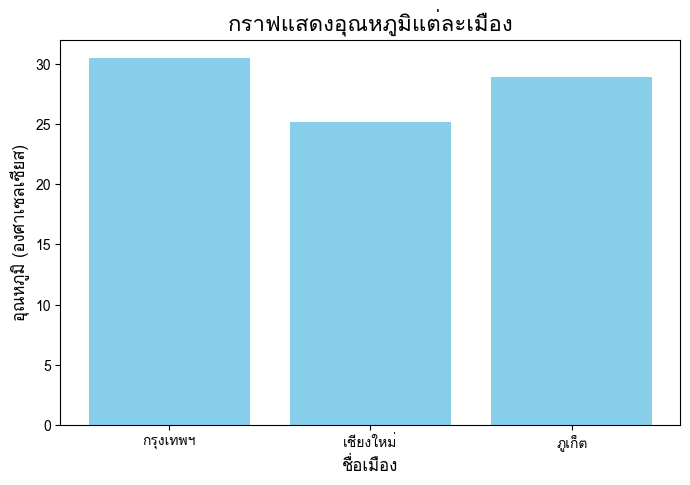

In [ ]:
import pandas as pd
import numpy as np
import os, shutil
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 1. ติดตั้งฟอนต์ภาษาไทย
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib เพื่ออัปเดตฟอนต์ใหม่
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

# 5. สร้างข้อมูลจำลองและแสดงผล
data = {
    'เมือง': ['กรุงเทพฯ', 'เชียงใหม่', 'ภูเก็ต'],
    'อุณหภูมิ': [30.5, 25.2, 28.9]
}
df_thai = pd.DataFrame(data)

print("ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!")

plt.figure(figsize=(8, 5))
plt.bar(df_thai['เมือง'], df_thai['อุณหภูมิ'], color='skyblue')
plt.title('กราฟแสดงอุณหภูมิแต่ละเมือง', fontsize=16)
plt.xlabel('ชื่อเมือง', fontsize=12)
plt.ylabel('อุณหภูมิ (องศาเซลเซียส)', fontsize=12)
plt.show()

In [ ]:
import pandas as pd
import numpy as np

BASE = ("https://raw.githubusercontent.com/PitchayaW/"
        "SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/")

df = pd.read_csv(BASE + "world_weather_sample.csv")
city_info = pd.read_csv(BASE + "city_info.csv")
region_info = pd.read_csv(BASE + "region_info.csv")

print("weather:", df.shape, " city_info:", city_info.shape, " region_info:", region_info.shape)
df.head()

weather: (2075, 10)  city_info: (23, 5)  region_info: (6, 3)


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
0,983,2025-03-24,New York,USA,North America,15.7,72.6,6.3,15.9,1005.4
1,220,2025-02-09,Tokyo,Japan,Asia,18.3,60.6,0.0,20.5,1015.1
2,1022,2025-02-01,Los Angeles,USA,North America,20.6,46.8,1.2,8.6,1013.5
3,469,2025-01-19,Mumbai,India,Asia,31.0,73.4,8.0,11.8,1000.1
4,1834,2025-02-03,Cape Town,South Africa,Africa,19.1,55.0,0.0,16.6,1015.1


---
## ข้อ 1 การเปรียบเทียบคำสั่งที่มีลักษณะใกล้เคียงกัน

**คำสั่ง:** ให้นักศึกษารันเซลล์โค้ดทั้ง 6 เซลล์ต่อไปนี้ สังเกตผลลัพธ์ที่ได้ แล้วอธิบายกับตนเองให้เข้าใจความแตกต่างของคำสั่งในแต่ละเซลล์ พร้อมระบุว่าในทางปฏิบัติควรเลือกใช้คำสั่งใดในสถานการณ์ใด

การอธิบายควรครอบคลุมทั้ง **ชนิดของผลลัพธ์** **รูปร่างของผลลัพธ์** และ **ความหมายของค่าที่ได้**

In [ ]:
# เซลล์ 1.1
s = pd.Series([10, 20, 30], index=["a", "b", "c"])
print(s["a"])
print(s.iloc[0])
print(s[["a", "c"]])

10
10
a    10
c    30
dtype: int64


In [ ]:
# เซลล์ 1.2
print(type(df["city"]), df["city"].shape)
print(type(df[["city"]]), df[["city"]].shape)

<class 'pandas.core.series.Series'> (2075,)
<class 'pandas.core.frame.DataFrame'> (2075, 1)


In [ ]:
# เซลล์ 1.3
print(df.loc[0:3].shape)
print(df.iloc[0:3].shape)

(4, 10)
(3, 10)


In [ ]:
# เซลล์ 1.4
print(df.groupby("city")["temperature_c"].count().head(3))
print(df.groupby("city").size().head(3))

city
Auckland    90
Bangkok     91
Beijing     89
Name: temperature_c, dtype: int64
city
Auckland    90
Bangkok     91
Beijing     90
dtype: int64


In [ ]:
# เซลล์ 1.5
print(df.groupby("city")["temperature_c"].mean().head(3))
print(df.groupby("city")[["temperature_c"]].mean().head(3))

city
Auckland    17.804444
Bangkok     32.453846
Beijing     15.598876
Name: temperature_c, dtype: float64
          temperature_c
city                   
Auckland      17.804444
Bangkok       32.453846
Beijing       15.598876


In [ ]:
# เซลล์ 1.6
a = pd.Series([1, 2, 3], index=["x", "y", "z"])
b = pd.Series([10, 20, 30], index=["z", "y", "x"])
print(a + b)
print(a.to_numpy() + b.to_numpy())

x    31
y    22
z    13
dtype: int64
[11 22 33]


---
## ข้อ 2 Series และ DataFrame

### ตัวอย่าง

In [ ]:
# การสร้าง DataFrame จากโครงสร้างข้อมูลสองรูปแบบ
d1 = pd.DataFrame({"city": ["Bangkok", "Tokyo"], "temp": [30.5, 16.2]})
d2 = pd.DataFrame([{"city": "Bangkok", "temp": 30.5}, {"city": "Tokyo", "temp": 16.2}])
print(d1.equals(d2))

# การเข้าถึงองค์ประกอบของ DataFrame
print(df.columns.tolist())
print(df.index[:5].tolist())
print(df["temperature_c"].nlargest(3).tolist())

True
['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa']
[0, 1, 2, 3, 4]
[999.0, 999.0, 999.0]


### โจทย์ 2.1
สร้าง Series ชื่อ `rain_by_city` ซึ่งเก็บปริมาณฝนรวมของแต่ละเมือง โดยกำหนดให้ index เป็นชื่อเมือง จากนั้นตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
2. สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด แสดงเป็นร้อยละทศนิยม 2 ตำแหน่ง
3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง

In [ ]:
# คำตอบข้อ 2.1
# Total rainfall per city (index = city name)
rain_by_city = df.groupby("city")["rainfall_mm"].sum()

# (1) Top 3 cities by total rainfall
print("Top 3 cities by total rainfall (mm):")
print(rain_by_city.nlargest(3))

# (2) Share of each city's rainfall vs. overall total, in percent (2 decimals)
rain_pct = (rain_by_city / rain_by_city.sum() * 100).round(2).sort_values(ascending=False)
print("\nRainfall share by city (%):")
print(rain_pct.to_string())
print("Check sum of shares =", round(rain_pct.sum(), 2))

# (3) Number of cities whose total rainfall is above the mean of all cities
rain_mean = rain_by_city.mean()
n_above = (rain_by_city > rain_mean).sum()
print(f"\nMean total rainfall per city = {rain_mean:.2f} mm")
print(f"Number of cities above the mean = {n_above}")


Top 3 cities by total rainfall (mm):
city
Singapore    870.4
Bangkok      685.6
Lagos        652.8
Name: rainfall_mm, dtype: float64

Rainfall share by city (%):
city
Singapore       10.43
Bangkok          8.21
Lagos            7.82
Mumbai           5.84
Chiang Mai       5.22
Sao Paulo        5.07
Nairobi          4.74
Tokyo            4.61
Auckland         4.22
Paris            3.99
Sydney           3.97
Toronto          3.81
New York         3.78
Mexico City      3.66
Buenos Aires     3.65
London           3.27
Berlin           3.21
Beijing          3.00
Moscow           2.96
Cape Town        2.87
Lima             2.16
Los Angeles      2.03
Cairo            1.47
Check sum of shares = 99.99

Mean total rainfall per city = 362.97 mm
Number of cities above the mean = 8


### โจทย์ 2.2
สร้าง DataFrame ชื่อ `city_profile` ที่มีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์
`city`, `country`, `region`, `n_records`, `avg_temp`, `total_rain`
โดยกำหนดให้ใช้ `groupby`

In [ ]:
# คำตอบข้อ 2.2
# One row per city. Country casing is inconsistent (e.g. "Canada" vs "CANADA"),
# so take the most frequent spelling (mode) within each city.
city_profile = (df.groupby("city")
                  .agg(country=("country", lambda s: s.mode()[0]),
                       region=("region", "first"),
                       n_records=("record_id", "size"),
                       avg_temp=("temperature_c", "mean"),
                       total_rain=("rainfall_mm", "sum"))
                  .reset_index())
print(city_profile.shape)
city_profile.round(2)


(23, 6)


,city,country,region,n_records,avg_temp,total_rain
0,Auckland,New Zealand,Oceania,90,17.80,351.9
1,Bangkok,Thailand,Asia,91,32.45,685.6
2,Beijing,China,Asia,90,15.60,250.1
3,Berlin,Germany,Europe,90,12.38,268.4
4,Buenos Aires,Argentina,South America,90,19.17,305.1
5,Cairo,Egypt,Africa,91,26.09,123.0
6,Cape Town,South Africa,Africa,90,30.16,239.3
7,Chiang Mai,Thailand,Asia,91,29.68,435.6
8,Lagos,Nigeria,Africa,90,29.49,652.8
9,Lima,Peru,South America,90,21.49,180.3


---
## ข้อ 3 การนำเข้าข้อมูลด้วย `read_csv()`

### ตัวอย่าง

In [ ]:
# พารามิเตอร์ที่ใช้บ่อย ได้แก่ usecols, nrows, parse_dates, dtype, na_values
preview = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["city", "date", "temperature_c"],
    parse_dates=["date"],
    nrows=5,
)
print(preview.dtypes)
preview

date             datetime64[ns]
city                     object
temperature_c           float64
dtype: object


,date,city,temperature_c
0,2025-03-24,New York,15.7
1,2025-02-09,Tokyo,18.3
2,2025-02-01,Los Angeles,20.6
3,2025-01-19,Mumbai,31.0
4,2025-02-03,Cape Town,19.1


In [ ]:
# การอ่านข้อมูลทีละก้อนด้วย chunksize ซึ่งคืนค่าเป็น iterator
total_rows = 0
for chunk in pd.read_csv(BASE + "world_weather_sample.csv", chunksize=500):
    total_rows += len(chunk)
print("จำนวนแถวรวม:", total_rows)

จำนวนแถวรวม: 2075


### โจทย์ 3.1
เขียนคำสั่ง `pd.read_csv()` เพียงคำสั่งเดียวที่ดำเนินการทุกข้อต่อไปนี้ให้เสร็จสิ้นตั้งแต่ขั้นตอนการนำเข้า

1. อ่านเฉพาะคอลัมน์ `date`, `city`, `region`, `temperature_c`, `humidity_pct`, `rainfall_mm`
2. แปลงคอลัมน์ `date` เป็นชนิด datetime
3. กำหนดให้ค่า `999` และ `-999` ถูกอ่านเป็นค่าว่าง
4. กำหนดชนิดข้อมูลของ `city` และ `region` เป็น `category`
5. กำหนดให้ `city` เป็น index

ให้ตรวจสอบผลด้วย `.dtypes` และ `.info()`

In [ ]:
# คำตอบข้อ 3.1
df_opt = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["date", "city", "region", "temperature_c", "humidity_pct", "rainfall_mm"],
    parse_dates=["date"],
    na_values=[999, -999],
    dtype={"city": "category", "region": "category"},
    index_col="city",
)
print(df_opt.dtypes)
print()
df_opt.info()
print("\nIndex dtype:", df_opt.index.dtype)


date             datetime64[ns]
region                 category
temperature_c           float64
humidity_pct            float64
rainfall_mm             float64
dtype: object

<class 'pandas.core.frame.DataFrame'>
CategoricalIndex: 2075 entries, New York to Paris
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           2075 non-null   datetime64[ns]
 1   region         2075 non-null   category      
 2   temperature_c  2052 non-null   float64       
 3   humidity_pct   1993 non-null   float64       
 4   rainfall_mm    2013 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(3)
memory usage: 69.8 KB

Index dtype: category


### โจทย์ 3.2
เปรียบเทียบปริมาณหน่วยความจำที่ใช้ระหว่างตารางที่นำเข้าตามปกติกับตารางจากโจทย์ 3.1 ด้วย `.memory_usage(deep=True)`
รายงานผลเป็นร้อยละที่ลดลง และ **อธิบาย** ว่าคอลัมน์ใดมีผลต่อการลดลงมากที่สุด เพราะเหตุใด

In [ ]:
# คำตอบข้อ 3.2
# Fair comparison: read the same 6 columns with default settings
cols_32 = ["date", "city", "region", "temperature_c", "humidity_pct", "rainfall_mm"]
df_raw = pd.read_csv(BASE + "world_weather_sample.csv", usecols=cols_32)

mem_raw = df_raw.memory_usage(deep=True)
mem_opt = df_opt.reset_index().memory_usage(deep=True)   # bring city back as a column

pct_reduced = (1 - mem_opt.sum() / mem_raw.sum()) * 100
print(f"Default read : {mem_raw.sum():>9,} bytes")
print(f"Optimized    : {mem_opt.sum():>9,} bytes")
print(f"Reduced by   : {pct_reduced:.2f}%")

mem_cmp = (pd.DataFrame({"default_bytes": mem_raw, "optimized_bytes": mem_opt})
             .assign(saved_bytes=lambda d: d["default_bytes"] - d["optimized_bytes"],
                     dtype_default=df_raw.dtypes.astype(str),
                     dtype_optimized=df_opt.reset_index().dtypes.astype(str))
             .sort_values("saved_bytes", ascending=False))
mem_cmp


Default read :   406,908 bytes
Optimized    :    73,049 bytes
Reduced by   : 82.05%


,default_bytes,optimized_bytes,saved_bytes,dtype_default,dtype_optimized
region,117631,2590,115041,object,category
city,116920,3927,112993,object,category
date,122425,16600,105825,object,datetime64[ns]
Index,132,132,0,NaN,NaN
humidity_pct,16600,16600,0,float64,float64
rainfall_mm,16600,16600,0,float64,float64
temperature_c,16600,16600,0,float64,float64


**คำอธิบายข้อ 3.2**

เมื่อเทียบคอลัมน์ชุดเดียวกัน หน่วยความจำลดลงประมาณ **82%** คอลัมน์ที่ช่วยลดได้มากที่สุดคือ `region` และ `city` ซึ่งเปลี่ยนจาก object/string เป็น `category` (ลดจากประมาณ 117 KB เหลือไม่ถึง 4 KB ต่อคอลัมน์) รองลงมาคือ `date` ที่เปลี่ยนจาก string เป็น datetime

- ชนิด object เก็บ string แยกทีละแถว ข้อมูล 2,075 แถวจึงเก็บชื่อเดิมซ้ำกันเป็นพันครั้ง
- ชนิด category เก็บชื่อที่ไม่ซ้ำไว้เพียงครั้งเดียว (23 เมือง และ 6 ภูมิภาค) แล้วแต่ละแถวเก็บแค่รหัสจำนวนเต็มขนาด 1 byte
- ชนิด datetime ใช้พื้นที่คงที่ 8 byte ต่อแถว ส่วน string วันที่ใช้ประมาณ 59 byte ต่อแถว
- คอลัมน์ตัวเลข (float64) มีขนาดเท่าเดิม เพราะชนิดข้อมูลไม่ได้เปลี่ยน

ยิ่งคอลัมน์มีค่าซ้ำมาก (cardinality ต่ำ) การแปลงเป็น category ยิ่งประหยัดหน่วยความจำ

### โจทย์ 3.3
ใช้การอ่านข้อมูลแบบ `chunksize` เพื่อคำนวณค่าต่อไปนี้ โดยห้ามโหลดข้อมูลทั้งไฟล์เข้าหน่วยความจำพร้อมกัน และห้ามใช้ `pd.concat`

1. อุณหภูมิสูงสุดและต่ำสุดของทั้งไฟล์
2. อุณหภูมิเฉลี่ยรายเมือง

**อธิบาย:** เหตุใดการนำค่าเฉลี่ยของแต่ละก้อนมาเฉลี่ยกันอีกครั้งจึงให้ผลไม่ถูกต้อง และควรสะสมค่าใดแทนจึงจะได้ผลที่ถูกต้อง

In [ ]:
# คำตอบข้อ 3.3
# Loop over chunks (not rows) is required by the task: data must not be loaded at once.
t_max, t_min = -np.inf, np.inf
city_sum = pd.Series(dtype="float64")
city_cnt = pd.Series(dtype="float64")

for chunk in pd.read_csv(BASE + "world_weather_sample.csv",
                         usecols=["city", "temperature_c"], chunksize=500):
    t_max = max(t_max, chunk["temperature_c"].max())
    t_min = min(t_min, chunk["temperature_c"].min())
    part = chunk.groupby("city")["temperature_c"].agg(["sum", "count"])
    city_sum = city_sum.add(part["sum"], fill_value=0)
    city_cnt = city_cnt.add(part["count"], fill_value=0)

city_avg_chunk = (city_sum / city_cnt).rename("avg_temp").sort_index()
print(f"Max temperature in file = {t_max}")
print(f"Min temperature in file = {t_min}")
print("\nAverage temperature by city (from accumulated sum / count):")
print(city_avg_chunk.round(2).to_string())

# Show why "mean of chunk means" is wrong, and verify the correct method
chunk_means = {i: c.groupby("city")["temperature_c"].mean()
               for i, c in enumerate(pd.read_csv(BASE + "world_weather_sample.csv",
                                                 usecols=["city", "temperature_c"], chunksize=500))}
mean_of_means = pd.DataFrame(chunk_means).mean(axis=1).sort_index()
reference = df.groupby("city")["temperature_c"].mean().sort_index()
print("\nSum/count method matches full-file mean :", np.allclose(city_avg_chunk, reference))
print("Mean-of-chunk-means matches full-file   :", np.allclose(mean_of_means, reference))
print("Largest error of mean-of-means (C)      :", round((mean_of_means - reference).abs().max(), 3))


Max temperature in file = 999.0
Min temperature in file = -88.0

Average temperature by city (from accumulated sum / count):
city
Auckland        17.80
Bangkok         32.45
Beijing         15.60
Berlin          12.38
Buenos Aires    19.17
Cairo           26.09
Cape Town       30.16
Chiang Mai      29.68
Lagos           29.49
Lima            21.49
London          13.49
Los Angeles     20.66
Mexico City     19.19
Moscow           7.23
Mumbai          30.87
Nairobi         21.44
New York        15.48
Paris           25.81
Sao Paulo       22.84
Singapore       40.08
Sydney          20.35
Tokyo           18.41
Toronto         11.61

Sum/count method matches full-file mean : True
Mean-of-chunk-means matches full-file   : False
Largest error of mean-of-means (C)      : 4.117


**คำอธิบายข้อ 3.3**

การนำค่าเฉลี่ยของแต่ละก้อนมาเฉลี่ยกันอีกครั้งให้ผลผิด เพราะทุกก้อนได้น้ำหนักเท่ากัน แต่จำนวนแถวของแต่ละเมืองในแต่ละก้อนไม่เท่ากัน ก้อนสุดท้ายมีเพียง 75 แถว และค่าว่างก็กระจายไม่เท่ากัน ค่าเฉลี่ยจากก้อนที่มีข้อมูลน้อยจึงมีอิทธิพลเกินจริง ผลข้างบนแสดงว่าวิธีนี้คลาดเคลื่อนได้หลายองศา

วิธีที่ถูกคือสะสม **ผลรวม (sum)** และ **จำนวนค่าที่ไม่ว่าง (count)** ของแต่ละเมืองจากทุกก้อน แล้วนำมาหารกันตอนท้าย (ค่าเฉลี่ยรวม = Σsum / Σcount) ผลที่ได้ตรงกับการโหลดทั้งไฟล์ทุกเมือง ส่วนค่าสูงสุดและต่ำสุดใช้ max/min ของแต่ละก้อนได้โดยตรง เพราะเป็นการดำเนินการที่สะสมได้

หมายเหตุ: ค่า 999 และ -88 เป็นค่าผิดปกติที่ยังไม่ได้ทำความสะอาด (จัดการในข้อ 4)

---
## ข้อ 4 การสำรวจข้อมูลและการตรวจสอบคุณภาพข้อมูล

### ตัวอย่าง

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   record_id       2075 non-null   int64  
 1   date            2075 non-null   object 
 2   city            2075 non-null   object 
 3   country         2075 non-null   object 
 4   region          2075 non-null   object 
 5   temperature_c   2055 non-null   float64
 6   humidity_pct    1993 non-null   float64
 7   rainfall_mm     2013 non-null   float64
 8   wind_speed_kmh  2034 non-null   float64
 9   pressure_hpa    2043 non-null   float64
dtypes: float64(5), int64(1), object(4)
memory usage: 162.2+ KB


In [ ]:
print(df.describe().round(2))
print(df.describe(include="all").iloc[:4])

       record_id  temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  \
count    2075.00        2055.00       1993.00      2013.00         2034.00   
mean     1035.15          21.84         66.82         4.15           14.78   
std       598.02          38.22         13.09         3.85            5.88   
min         1.00         -88.00         21.50         0.00           -5.00   
25%       517.50          15.40         58.60         0.30           10.80   
50%      1035.00          20.00         67.10         3.50           15.00   
75%      1553.50          25.70         75.50         6.60           18.70   
max      2070.00         999.00        150.00        17.60           33.70   

       pressure_hpa  
count       2043.00  
mean        1013.13  
std            5.86  
min          993.90  
25%         1009.30  
50%         1013.10  
75%         1017.20  
max         1030.60  
        record_id        date        city   country region  temperature_c  \
count      2075.0     

In [ ]:
print(df.isna().sum())
print("จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์:", df.isna().any(axis=1).sum())
print("จำนวนแถวที่ซ้ำกันทุกคอลัมน์:", df.duplicated().sum())

record_id          0
date               0
city               0
country            0
region             0
temperature_c     20
humidity_pct      82
rainfall_mm       62
wind_speed_kmh    41
pressure_hpa      32
dtype: int64
จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์: 229
จำนวนแถวที่ซ้ำกันทุกคอลัมน์: 5


### โจทย์ 4.1
สร้าง DataFrame ชื่อ `summary` ที่มีหนึ่งแถวต่อหนึ่งคอลัมน์ของ `df` ประกอบด้วย
`dtype`, `n_missing`, `pct_missing`, `n_unique`, `example_value`
โดยห้ามใช้การวนซ้ำทีละคอลัมน์ และให้เรียงลำดับจากคอลัมน์ที่มีค่าว่างมากที่สุด

In [ ]:
# คำตอบข้อ 4.1
# Build every column with vectorized DataFrame methods (no per-column loop).
# bfill().iloc[0] gives the first non-missing value of each column.
summary = (pd.DataFrame({
               "dtype": df.dtypes.astype(str),
               "n_missing": df.isna().sum(),
               "pct_missing": (df.isna().mean() * 100).round(2),
               "n_unique": df.nunique(),
               "example_value": df.bfill().iloc[0],
           })
           .sort_values("n_missing", ascending=False))
summary


,dtype,n_missing,pct_missing,n_unique,example_value
humidity_pct,float64,82,3.95,544,72.6
rainfall_mm,float64,62,2.99,164,6.3
wind_speed_kmh,float64,41,1.98,278,15.9
pressure_hpa,float64,32,1.54,294,1005.4
temperature_c,float64,20,0.96,331,15.7
record_id,int64,0,0.00,2070,983
date,object,0,0.00,90,2025-03-24
region,object,0,0.00,6,North America
city,object,0,0.00,23,New York
country,object,0,0.00,28,USA


### โจทย์ 4.2
ผลลัพธ์ของ `.describe()` แสดงค่าสูงสุดของ `temperature_c` และ `humidity_pct` ที่เป็นไปไม่ได้ในทางกายภาพ ให้เขียนโปรแกรมหาค่าต่อไปนี้

1. จำนวนแถวที่ `temperature_c` อยู่นอกช่วง -60 ถึง 60
2. จำนวนแถวที่ `humidity_pct` อยู่นอกช่วง 0 ถึง 100
3. จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์ โดยระวังการนับซ้ำ

In [ ]:
# คำตอบข้อ 4.2
temp = df["temperature_c"]
hum = df["humidity_pct"]

# Missing values are not "out of range", so exclude NaN explicitly
temp_bad = temp.notna() & ~temp.between(-60, 60)
hum_bad = hum.notna() & ~hum.between(0, 100)
any_bad = temp_bad | hum_bad          # logical OR avoids double counting

print("Rows with temperature_c outside [-60, 60] :", temp_bad.sum())
print("Rows with humidity_pct outside [0, 100]   :", hum_bad.sum())
print("Rows with at least one abnormal column    :", any_bad.sum())
print("Rows abnormal in both columns             :", (temp_bad & hum_bad).sum())
df.loc[any_bad, ["record_id", "date", "city", "temperature_c", "humidity_pct"]]


Rows with temperature_c outside [-60, 60] : 5
Rows with humidity_pct outside [0, 100]   : 3
Rows with at least one abnormal column    : 8
Rows abnormal in both columns             : 0


,record_id,date,city,temperature_c,humidity_pct
25,334,2025-03-05,Singapore,31.5,150.0
37,1017,2025-01-27,Los Angeles,17.3,150.0
78,1841,2025-02-10,Cape Town,999.0,61.2
499,286,2025-01-16,Singapore,-88.0,96.4
712,717,2025-03-28,Paris,999.0,82.7
1280,1369,2025-01-19,Buenos Aires,-88.0,63.5
1855,340,2025-03-11,Singapore,999.0,72.0
2068,56,2025-02-25,Bangkok,34.4,150.0


### โจทย์ 4.3
คอลัมน์ `country` มีจำนวนค่าไม่ซ้ำมากกว่าจำนวนประเทศที่มีอยู่จริง เนื่องจากการใช้ตัวพิมพ์ไม่สม่ำเสมอ

1. แสดงว่าค่าใดบ้างที่หมายถึงประเทศเดียวกันแต่ถูกนับแยกจากกัน
2. ทดลองใช้ `df["country"].str.title()` แล้ว **อธิบาย** ว่าวิธีนี้ทำให้ข้อมูลของประเทศใดเสียหาย และเพราะเหตุใด
3. เสนอและเขียนวิธี normalize ที่ถูกต้อง โดยต้องรองรับกรณีที่มีช่องว่างหัวท้ายด้วย

> **การตรวจสอบคำตอบ:** จำนวนประเทศที่ถูกต้องคือ 21 ประเทศ จากทั้งหมด 23 เมือง

In [ ]:
# คำตอบข้อ 4.3
# (1) Values that refer to the same country but are counted separately
country_key = df["country"].str.strip().str.casefold()
variants = df.groupby(country_key)["country"].unique()
variants = variants[variants.str.len() > 1]
print("Raw unique countries:", df["country"].nunique())
print("Country values with several spellings:")
print(variants.to_string())

# (3) Proper normalization: strip spaces + casefold as a key,
#     then map each key to its most frequent original spelling
def normalize_country(s):
    key = s.str.strip().str.casefold()
    canonical = s.str.strip().groupby(key).agg(lambda x: x.mode()[0])
    return key.map(canonical)

country_clean = normalize_country(df["country"])

# (2) Try .str.title() and find which countries get damaged
titled = df["country"].str.title()
damaged = (pd.DataFrame({"original": df["country"], "after_title": titled, "correct": country_clean})
             .loc[lambda d: d["after_title"] != d["correct"]]
             .drop_duplicates())
print("\n(2) Unique after str.title():", titled.nunique())
print("Values that str.title() turns into a wrong name:")
print(damaged.to_string(index=False))

print("\n(3) Unique countries after normalization:", country_clean.nunique(),
      "| unique cities:", df["city"].nunique())

# Test with leading/trailing spaces and mixed case
test = pd.Series(["Thailand", "  thailand", "USA", "usa ", " UK", "Uk", "UK"])
print(pd.DataFrame({"raw": test, "normalized": normalize_country(test)}))


Raw unique countries: 28
Country values with several spellings:
country
argentina          [Argentina, ARGENTINA]
canada                   [Canada, CANADA]
germany                [Germany, GERMANY]
japan                      [Japan, JAPAN]
kenya                      [Kenya, KENYA]
new zealand    [New Zealand, NEW ZEALAND]
singapore          [Singapore, SINGAPORE]

(2) Unique after str.title(): 21
Values that str.title() turns into a wrong name:
original after_title correct
     USA         Usa     USA
      UK          Uk      UK

(3) Unique countries after normalization: 21 | unique cities: 23
          raw normalized
0    Thailand   Thailand
1    thailand   Thailand
2         USA        USA
3        usa         USA
4          UK         UK
5          Uk         UK
6          UK         UK


**คำอธิบายข้อ 4.3**

`str.title()` ทำให้ตัวอักษรแรกของแต่ละคำเป็นตัวใหญ่และตัวที่เหลือเป็นตัวเล็ก จึงแก้ชื่อที่เป็นตัวใหญ่ทั้งหมด เช่น `CANADA` เป็น `Canada` ได้ แต่ทำให้ **ชื่อย่อ** เสียหาย คือ `USA` กลายเป็น `Usa` และ `UK` กลายเป็น `Uk` ซึ่งไม่ใช่ชื่อที่ถูกต้อง แม้จำนวนค่าไม่ซ้ำจะออกมาเป็น 21 พอดี แต่ค่าที่ได้ก็ผิด และถ้าข้อมูลมีทั้ง `USA` และ `Usa` ปนกันจะตรวจไม่พบ

วิธีที่เสนอคือใช้ `strip()` ตัดช่องว่างหัวท้าย และ `casefold()` สร้างคีย์สำหรับจับกลุ่มเท่านั้น จากนั้นแทนแต่ละคีย์ด้วยตัวสะกดต้นฉบับที่พบบ่อยที่สุด (mode) วิธีนี้ไม่เปลี่ยนรูปแบบตัวอักษรของชื่อที่ถูกอยู่แล้ว ผลที่ได้คือ 21 ประเทศจาก 23 เมือง ตรงตามที่โจทย์กำหนด (ในทางปฏิบัติจะใช้ตารางอ้างอิง เช่น `city_info` เป็นตัวสะกดมาตรฐานก็ได้)

---
## ข้อ 5 การเลือกข้อมูลด้วย `loc` และ `iloc`

### ตัวอย่าง

In [ ]:
# iloc อ้างอิงตามตำแหน่ง ส่วน loc อ้างอิงตาม label และรวมค่าปลายช่วง
print(df.iloc[0:3, 0:3].shape, df.loc[0:3, ["city", "region"]].shape)

# loc ใช้ร่วมกับเงื่อนไขและเลือกคอลัมน์ได้ในคำสั่งเดียว
print(df.loc[df["temperature_c"] > 35, ["city", "date", "temperature_c"]].head(3))

(3, 3) (4, 2)
          city        date  temperature_c
78   Cape Town  2025-02-10          999.0
161    Bangkok  2025-02-14           38.6
325     Mumbai  2025-03-31           35.6


In [ ]:
# การกำหนด index หลายระดับ และการเลือกข้อมูลจาก index หลายระดับ
multi = df.set_index(["region", "city"]).sort_index()
print(multi.loc["Asia"].shape)
print(multi.loc[("Asia", "Tokyo"), ["date", "temperature_c"]].head(3))

(542, 8)
                    date  temperature_c
region city                            
Asia   Tokyo  2025-02-09           18.3
       Tokyo  2025-03-21           19.7
       Tokyo  2025-03-23           17.7


### โจทย์ 5.1
ใช้ `.iloc[]` เท่านั้น โดยห้ามอ้างอิงชื่อคอลัมน์ เพื่อดึงข้อมูลต่อไปนี้

1. แถวที่อยู่ในตำแหน่งเลขคู่ 10 แถวแรก เฉพาะสามคอลัมน์สุดท้าย
2. ห้าแถวสุดท้าย โดยเรียงลำดับจากแถวล่างสุดขึ้นไป
3. ค่าเดี่ยวที่อยู่ในแถวกึ่งกลางตารางและคอลัมน์สุดท้าย โดยต้องคำนวณตำแหน่งกึ่งกลางจากจำนวนแถว

In [ ]:
# คำตอบข้อ 5.1
# (1) Even positions (0, 2, ..., 18) = first 10 even-position rows, last 3 columns
part1 = df.iloc[0:20:2, -3:]
print("(1) shape:", part1.shape)
print(part1)

# (2) Last 5 rows, ordered from the bottom row upward
part2 = df.iloc[:-6:-1]
print("\n(2) positions:", [df.index.get_loc(i) for i in part2.index])
print(part2)

# (3) Single value at the middle row (computed from row count) and the last column
mid_pos = len(df) // 2
part3 = df.iloc[mid_pos, -1]
print(f"\n(3) middle row position = {mid_pos}, value in last column = {part3}")


(1) shape: (10, 3)
    rainfall_mm  wind_speed_kmh  pressure_hpa
0           6.3            15.9        1005.4
2           1.2             8.6        1013.5
4           0.0            16.6        1015.1
6           2.7            14.6        1018.0
8           1.6             9.8        1007.7
10          0.0            15.6        1010.1
12          0.0            13.6        1015.8
14          2.2            24.6        1000.5
16          8.3             9.3        1019.4
18          8.9            23.3        1020.6

(2) positions: [2074, 2073, 2072, 2071, 2070]
      record_id        date         city country         region  \
2074        642  2025-01-12        Paris  France         Europe   
2073       1210  2025-02-09      Toronto  Canada  North America   
2072       1738  2025-01-28      Nairobi   Kenya         Africa   
2071       1769  2025-02-28      Nairobi   Kenya         Africa   
2070       1093  2025-01-13  Mexico City  Mexico  North America   

      temperature_c  humi

### โจทย์ 5.2
จาก DataFrame ที่กำหนด index เป็นคู่ `(region, city)` ให้ดึงข้อมูลต่อไปนี้ด้วย `.loc[]`

1. ข้อมูลทั้งหมดของภูมิภาค Asia เฉพาะคอลัมน์ `date` และ `temperature_c`
2. ข้อมูลของเมือง Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว
3. ข้อมูลของทุกภูมิภาค แต่เฉพาะเมืองที่ชื่อขึ้นต้นด้วยตัวอักษร B

**อธิบาย:** เหตุใดจึงควรเรียงลำดับ index ด้วย `.sort_index()` ก่อนใช้งาน index หลายระดับ

In [ ]:
# คำตอบข้อ 5.2
idx = pd.IndexSlice
multi52 = df.set_index(["region", "city"]).sort_index()

# (1) All rows of Asia, only date and temperature_c
asia = multi52.loc["Asia", ["date", "temperature_c"]]
print("(1) Asia:", asia.shape)
print(asia.head())

# (2) Tokyo and Bangkok in one command
tok_bkk = multi52.loc[idx[:, ["Tokyo", "Bangkok"]], :]
print("\n(2) Tokyo + Bangkok:", tok_bkk.shape,
      tok_bkk.index.get_level_values("city").unique().tolist())

# (3) All regions, only cities starting with "B"
b_cities = multi52.loc[multi52.index.get_level_values("city").str.startswith("B")]
print("\n(3) Cities starting with B:", b_cities.shape)
print(b_cities.index.unique().tolist())


(1) Asia: (542, 2)
               date  temperature_c
city                              
Bangkok  2025-02-22           30.8
Bangkok  2025-01-10           28.9
Bangkok  2025-01-27           27.9
Bangkok  2025-01-03           29.0
Bangkok  2025-03-28           31.0

(2) Tokyo + Bangkok: (181, 8) ['Tokyo', 'Bangkok']

(3) Cities starting with B: (361, 8)
[('Asia', 'Bangkok'), ('Asia', 'Beijing'), ('Europe', 'Berlin'), ('South America', 'Buenos Aires')]


**คำอธิบายข้อ 5.2**

ควรเรียก `.sort_index()` ก่อนใช้ index หลายระดับเพราะ

- การเลือกข้อมูลแบบช่วงหรือแบบ slice บนระดับย่อย (เช่น `pd.IndexSlice[:, ["Tokyo", "Bangkok"]]`) ต้องให้ index เรียงตามลำดับ (lexsorted) ถ้าไม่เรียง pandas อาจแจ้ง `UnsortedIndexError` หรือ `PerformanceWarning`
- index ที่เรียงแล้วค้นหาด้วย binary search ได้ จึงเร็วกว่าการไล่หาทีละแถวมาก โดยเฉพาะเมื่อข้อมูลมีขนาดใหญ่
- ผลลัพธ์จะจัดกลุ่มเป็นระเบียบ เช่น ทุกเมืองของ Asia อยู่ติดกัน อ่านและตรวจสอบได้ง่าย

### โจทย์ 5.3
ให้รันโปรแกรมต่อไปนี้ แล้วสังเกตผลที่เกิดขึ้นกับ `df`

```python
subset = df[df["city"] == "Bangkok"]
subset["temperature_c"] = 0
```

จากนั้นเขียนโปรแกรมที่ถูกต้องสองรูปแบบ ได้แก่ รูปแบบที่ต้องการแก้ไข `df` จริง และรูปแบบที่ต้องการทำงานกับสำเนาแยกต่างหาก
พร้อมสรุปเป็นแนวปฏิบัติของตนเองความยาว 2 ถึง 3 บรรทัด

In [ ]:
# คำตอบข้อ 5.3
import warnings
bkk_mask = df["city"] == "Bangkok"
bkk_before = df.loc[bkk_mask, "temperature_c"].copy()

# Code given in the task
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    subset = df[df["city"] == "Bangkok"]
    subset["temperature_c"] = 0
print("Warnings raised:", [type(x.message).__name__ for x in w])
print("subset temperature after assignment:", subset["temperature_c"].unique())
print("Was df changed?", not df.loc[bkk_mask, "temperature_c"].equals(bkk_before))

# Pattern A: modify the original DataFrame -> use .loc[row_mask, column] on that DataFrame.
# Demonstrated on a copy (df_a) so the real df stays intact for later questions.
df_a = df.copy()
df_a.loc[df_a["city"] == "Bangkok", "temperature_c"] = 0
print("\nPattern A - Bangkok temps in df_a:", df_a.loc[df_a["city"] == "Bangkok", "temperature_c"].unique())

# Pattern B: work on an independent copy -> call .copy() explicitly
subset_b = df[df["city"] == "Bangkok"].copy()
subset_b["temperature_c"] = 0
print("Pattern B - subset_b temps:", subset_b["temperature_c"].unique(),
      "| df unchanged:", df.loc[bkk_mask, "temperature_c"].equals(bkk_before))


Warnings raised: ['SettingWithCopyWarning']
subset temperature after assignment: [0]
Was df changed? False

Pattern A - Bangkok temps in df_a: [0.]
Pattern B - subset_b temps: [0] | df unchanged: True


**คำอธิบายข้อ 5.3**

`subset = df[df["city"] == "Bangkok"]` สร้างตารางใหม่ (สำเนา) การกำหนดค่าให้ `subset` จึง **ไม่เปลี่ยน df** ใน pandas 2.x จะขึ้น `SettingWithCopyWarning` เพราะไม่แน่ชัดว่าผู้เขียนต้องการแก้ตารางต้นฉบับหรือสำเนา ส่วน pandas 3.x ใช้ Copy-on-Write จึงไม่ขึ้นคำเตือน และผลก็คือ df ไม่เปลี่ยนเช่นกัน

**แนวปฏิบัติของตนเอง**

1. ถ้าต้องการแก้ตารางต้นฉบับ ให้ใช้ `df.loc[เงื่อนไข, "คอลัมน์"] = ค่า` ในคำสั่งเดียวเสมอ
2. ถ้าต้องการแยกไปทำงานต่อ ให้ต่อท้ายด้วย `.copy()` ทุกครั้งที่กรองข้อมูลออกมา
3. หลีกเลี่ยง chained assignment เช่น `df[cond]["col"] = value`

---
## ข้อ 6 การกรองข้อมูลด้วยเงื่อนไข

### ตัวอย่าง

In [ ]:
# การใช้ตัวดำเนินการ & | ~ ต้องครอบวงเล็บทุกเงื่อนไข
print(len(df[(df["temperature_c"] > 28) & (df["humidity_pct"] > 70)]))
print(len(df[~df["city"].isin(["Bangkok", "Tokyo"])]))
print(len(df[df["temperature_c"].between(20, 30)]))
print(len(df.query("region == 'Asia' and rainfall_mm > 5")))

237
1894
757
295


In [ ]:
# where และ mask ไม่ลดจำนวนแถว แต่แทนค่าที่ไม่ตรงเงื่อนไขด้วยค่าที่กำหนด
temp_valid = df["temperature_c"].where(df["temperature_c"].between(-60, 60))
rain_capped = df["rainfall_mm"].mask(df["rainfall_mm"] > 15, 15)
print(temp_valid.isna().sum(), df["temperature_c"].isna().sum())
print(rain_capped.max(), df["rainfall_mm"].max())

25 20
15.0 17.6


In [ ]:
# pipe ใช้ต่อขั้นตอนการประมวลผลหลายขั้นให้เป็นลำดับเดียว
def add_flag(data, threshold):
    return data.assign(is_hot=data["temperature_c"] > threshold)

result = (df
          .query("region == 'Asia'")
          .pipe(add_flag, threshold=30)
          .loc[:, ["city", "temperature_c", "is_hot"]])
print(result.head(3))

       city  temperature_c  is_hot
1     Tokyo           18.3   False
3    Mumbai           31.0    True
12  Beijing           14.3   False


### โจทย์ 6.1
เขียนเงื่อนไขสำหรับกรองข้อมูลต่อไปนี้

1. ข้อมูลในภูมิภาคเอเชียที่ปริมาณฝนมากกว่า 5 มิลลิเมตร และความเร็วลมมากกว่า 20 กิโลเมตรต่อชั่วโมง
2. ข้อมูลที่ไม่ใช่เมือง Bangkok, Tokyo และ London และมีความชื้นระหว่าง 40 ถึง 60
3. แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
4. แถวที่ชื่อเมืองมีคำว่า New หรือ San ประกอบอยู่ โดยใช้ `.str.contains` ร่วมกับ regular expression

In [ ]:
# คำตอบข้อ 6.1
# (1) Asia, rainfall > 5 mm and wind > 20 km/h
f1 = df[(df["region"] == "Asia") & (df["rainfall_mm"] > 5) & (df["wind_speed_kmh"] > 20)]
print("(1) rows:", len(f1))

# (2) Not Bangkok/Tokyo/London and humidity between 40 and 60
f2 = df[~df["city"].isin(["Bangkok", "Tokyo", "London"]) & df["humidity_pct"].between(40, 60)]
print("(2) rows:", len(f2))

# (3) Rows with 2 or more missing columns
f3 = df[df.isna().sum(axis=1) >= 2]
print("(3) rows:", len(f3))

# (4) City name contains the word New or San (regex with word boundary)
f4 = df[df["city"].str.contains(r"\b(?:New|San)\b", regex=True)]
print("(4) rows:", len(f4), "| cities:", f4["city"].unique().tolist())
f3.head()


(1) rows: 54
(2) rows: 470
(3) rows: 8
(4) rows: 90 | cities: ['New York']


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
43,1582,2025-02-21,Cairo,Egypt,Africa,NaN,45.7,NaN,19.6,1017.7
420,1943,2025-02-22,Sydney,Australia,Oceania,18.5,70.4,0.0,NaN,NaN
438,1684,2025-03-05,Lagos,Nigeria,Africa,31.3,NaN,7.4,NaN,1009.9
1315,349,2025-03-20,Singapore,Singapore,Asia,31.7,78.6,9.3,NaN,NaN
1491,514,2025-03-05,Mumbai,India,Asia,30.5,NaN,8.6,NaN,1011.6


### โจทย์ 6.2
ใช้ `.where()` และ `.mask()` สร้างคอลัมน์ใหม่สองคอลัมน์ ได้แก่ คอลัมน์อุณหภูมิที่แทนค่าผิดปกติด้วยค่าว่าง และคอลัมน์ปริมาณฝนที่จำกัดค่าสูงสุดไว้ที่ค่าเปอร์เซ็นไทล์ที่ 99
**อธิบาย:** แนวทางนี้แตกต่างจากการลบแถวทิ้งอย่างไรในแง่ของการวิเคราะห์ในขั้นถัดไป

In [ ]:
# คำตอบข้อ 6.2
p99_rain = df["rainfall_mm"].quantile(0.99)

df_62 = df.assign(
    temp_clean=df["temperature_c"].where(df["temperature_c"].between(-60, 60)),   # abnormal -> NaN
    rain_capped=df["rainfall_mm"].mask(df["rainfall_mm"] > p99_rain, p99_rain),   # cap at P99
)
print(f"99th percentile of rainfall = {p99_rain:.2f} mm")
print("Rows kept with where/mask :", len(df_62))
print("Rows left if rows dropped :", len(df[df["temperature_c"].between(-60, 60)]))
print("Rainfall values capped     :", (df["rainfall_mm"] > p99_rain).sum())
df_62[["temperature_c", "temp_clean", "rainfall_mm", "rain_capped"]].describe().round(2)


99th percentile of rainfall = 14.69 mm
Rows kept with where/mask : 2075
Rows left if rows dropped : 2050
Rainfall values capped     : 21


,temperature_c,temp_clean,rainfall_mm,rain_capped
count,2055.00,2050.00,2013.00,2013.00
mean,21.84,20.51,4.15,4.14
std,38.22,7.24,3.85,3.82
min,-88.00,-0.20,0.00,0.00
25%,15.40,15.42,0.30,0.30
50%,20.00,20.00,3.50,3.50
75%,25.70,25.68,6.60,6.60
max,999.00,39.20,17.60,14.69


**คำอธิบายข้อ 6.2**

`.where()` และ `.mask()` แทนค่าเฉพาะจุดโดยไม่ลบแถว จำนวนแถวจึงยังเท่าเดิม (2,075 แถว) ต่างจากการลบแถวทิ้งดังนี้

- **ไม่สูญเสียข้อมูลคอลัมน์อื่น** แถวที่อุณหภูมิผิดปกติยังมีความชื้น ฝน และลมที่ถูกต้อง ซึ่งยังใช้วิเคราะห์ต่อได้ ถ้าลบทั้งแถวจะเสียข้อมูลเหล่านี้ไปด้วย
- **โครงสร้างข้อมูลยังสมบูรณ์** ทุกเมืองยังมีครบทุกวัน จึงยังใช้ time series, resample, ffill หรือ merge ตามวันที่ได้ตามปกติ
- **ค่าสถิติไม่บิดเบือน** การแทนค่าผิดปกติด้วย NaN ทำให้ฟังก์ชันอย่าง mean และ std ข้ามค่านั้นไปเอง (std ของอุณหภูมิลดจาก 38 เหลือประมาณ 7) ส่วนการจำกัดค่าที่ P99 (winsorize) ช่วยลดอิทธิพลของค่าสุดโต่งโดยยังนับวันนั้นอยู่
- **ข้อควรระวัง** การจำกัดค่าที่ P99 เปลี่ยนค่าจริงของวันที่ฝนตกหนัก จึงควรใช้เฉพาะเมื่อต้องการลดอิทธิพลของค่าสุดโต่ง ไม่ใช่เมื่อต้องการศึกษาเหตุการณ์สุดขั้วโดยตรง

### โจทย์ 6.3
หาวันที่มีอุณหภูมิห่างจากค่าเฉลี่ยของเมืองตนเองมากที่สุดของแต่ละเมือง
ผลลัพธ์ต้องมีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์ `city`, `date`, `temperature_c`, `deviation`

In [ ]:
# คำตอบข้อ 6.3
city_mean_63 = df.groupby("city")["temperature_c"].transform("mean")
deviation = df["temperature_c"] - city_mean_63

# Index of the row with the largest absolute deviation inside each city
max_idx = deviation.abs().groupby(df["city"]).idxmax()

max_dev = (df.loc[max_idx, ["city", "date", "temperature_c"]]
             .assign(deviation=deviation.loc[max_idx].round(2))
             .sort_values("deviation", key=abs, ascending=False)
             .reset_index(drop=True))
print("Rows:", len(max_dev), "| cities:", df["city"].nunique())
max_dev


Rows: 23 | cities: 23


,city,date,temperature_c,deviation
0,Paris,2025-03-28,999.0,973.19
1,Cape Town,2025-02-10,999.0,968.84
2,Singapore,2025-03-11,999.0,958.92
3,Buenos Aires,2025-01-19,-88.0,-107.17
4,London,2025-02-09,23.4,9.91
5,New York,2025-03-16,24.5,9.02
6,Lima,2025-01-22,12.9,-8.59
7,Sydney,2025-03-06,11.8,-8.55
8,Lagos,2025-01-01,21.1,-8.39
9,Toronto,2025-01-07,3.5,-8.11


---
## ข้อ 7 การจัดการข้อมูลวันที่และเวลา

### ตัวอย่าง

In [ ]:
df["date"] = pd.to_datetime(df["date"])
print(df["date"].dt.month.head(3).tolist())
print(df["date"].dt.day_name().head(3).tolist())
print(df["date"].min(), df["date"].max())

# assign ใช้สร้างหลายคอลัมน์ในคำสั่งเดียวและคืนค่าเป็น DataFrame ใหม่
tmp = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    is_weekend=df["date"].dt.dayofweek >= 5,
)
print(tmp[["date", "year_month", "is_weekend"]].head(3))

[3, 2, 2]
['Monday', 'Sunday', 'Saturday']
2025-01-01 00:00:00 2025-03-31 00:00:00
        date year_month  is_weekend
0 2025-03-24    2025-03       False
1 2025-02-09    2025-02        True
2 2025-02-01    2025-02        True


In [ ]:
# resample สรุปข้อมูลตามช่วงเวลา โดยต้องกำหนด index เป็น datetime ก่อน
bkk = df[df["city"] == "Bangkok"].set_index("date").sort_index()
print(bkk["temperature_c"].resample("7D").mean().head(4).round(2))

date
2025-01-01    30.36
2025-01-08    31.09
2025-01-15    30.39
2025-01-22    32.29
Freq: 7D, Name: temperature_c, dtype: float64


### โจทย์ 7.1
ใช้ `.assign()` เพียงคำสั่งเดียวสร้างคอลัมน์ `year_month`, `week_of_year`, `day_name` และ `is_weekend`

In [ ]:
# คำตอบข้อ 7.1
dates = df["date"]
df_dt = df.assign(
    year_month=dates.dt.to_period("M").astype(str),
    week_of_year=dates.dt.isocalendar().week.astype(int),
    day_name=dates.dt.day_name(),
    is_weekend=dates.dt.dayofweek >= 5,
)
df_dt[["date", "year_month", "week_of_year", "day_name", "is_weekend"]].head()


,date,year_month,week_of_year,day_name,is_weekend
0,2025-03-24,2025-03,13,Monday,False
1,2025-02-09,2025-02,6,Sunday,True
2,2025-02-01,2025-02,5,Saturday,True
3,2025-01-19,2025-01,3,Sunday,True
4,2025-02-03,2025-02,6,Monday,False


### โจทย์ 7.2
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. ข้อมูลครอบคลุมทั้งหมดกี่วัน และมีวันใดในช่วงดังกล่าวที่ไม่มีข้อมูลเลยหรือไม่ โดยใช้ `pd.date_range` ประกอบการตรวจสอบ
2. อุณหภูมิเฉลี่ยของวันหยุดสุดสัปดาห์เปรียบเทียบกับวันธรรมดา จำแนกตามภูมิภาค
3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง

In [ ]:
# คำตอบข้อ 7.2
# (1) Date coverage and missing dates
all_days = pd.date_range(df["date"].min(), df["date"].max(), freq="D")
days_missing = all_days.difference(pd.DatetimeIndex(df["date"].unique()))
print(f"(1) Period {all_days[0].date()} to {all_days[-1].date()} = {len(all_days)} days")
print("    Days with no data at all:", len(days_missing), list(days_missing.date))

# (2) Weekend vs weekday average temperature by region
#     Abnormal temperatures (outside -60..60) are set to NaN first, otherwise 999 dominates the mean.
weekend_cmp = (df_dt.assign(temp_clean=df_dt["temperature_c"].where(df_dt["temperature_c"].between(-60, 60)))
                    .pivot_table(index="region", columns="is_weekend", values="temp_clean", aggfunc="mean")
                    .rename(columns={False: "weekday", True: "weekend"})
                    .assign(diff_weekend_minus_weekday=lambda d: d["weekend"] - d["weekday"])
                    .round(2))
print("\n(2) Average temperature (C), weekend vs weekday:")
print(weekend_cmp)

# (3) Month with the highest total rainfall of each city
monthly_rain = df_dt.groupby(["city", "year_month"])["rainfall_mm"].sum()
wettest_month = (monthly_rain.loc[monthly_rain.groupby("city").idxmax()]
                   .rename("total_rain")
                   .reset_index())
print("\n(3) Wettest month by city:")
print(wettest_month.to_string(index=False))


(1) Period 2025-01-01 to 2025-03-31 = 90 days
    Days with no data at all: 0 []

(2) Average temperature (C), weekend vs weekday:
is_weekend     weekday  weekend  diff_weekend_minus_weekday
region                                                     
Africa           24.08    23.88                       -0.19
Asia             26.25    26.53                        0.28
Europe           11.93    11.95                        0.02
North America    16.72    16.84                        0.13
Oceania          18.94    19.40                        0.46
South America    21.70    21.26                       -0.44

(3) Wettest month by city:
        city year_month  total_rain
    Auckland    2025-03       150.0
     Bangkok    2025-02       243.9
     Beijing    2025-02        87.4
      Berlin    2025-03       100.1
Buenos Aires    2025-02       121.2
       Cairo    2025-02        48.0
   Cape Town    2025-01        98.3
  Chiang Mai    2025-03       188.0
       Lagos    2025-03       233.0
 

### โจทย์ 7.3
ใช้ `.resample()` สรุปข้อมูลของเมือง Bangkok เป็นราย 7 วัน โดยแสดงอุณหภูมิเฉลี่ยและปริมาณฝนรวมในตารางเดียวกัน
**อธิบาย:** `.resample()` แตกต่างจาก `groupby(df["date"].dt.month)` อย่างไร และกรณีใดที่จำเป็นต้องใช้ `.resample()` เท่านั้น

In [ ]:
# คำตอบข้อ 7.3
bkk_weekly = (df[df["city"] == "Bangkok"]
                .set_index("date")
                .sort_index()
                .resample("7D")
                .agg({"temperature_c": "mean", "rainfall_mm": "sum"})
                .rename(columns={"temperature_c": "avg_temp", "rainfall_mm": "total_rain"})
                .round(2))
print("Number of 7-day bins:", len(bkk_weekly))
bkk_weekly


Number of 7-day bins: 13


,avg_temp,total_rain
date,,
2025-01-01,30.36,65.7
2025-01-08,31.09,47.6
2025-01-15,30.39,58.7
2025-01-22,32.29,50.0
2025-01-29,31.76,55.4
2025-02-05,33.03,65.1
2025-02-12,34.21,60.2
2025-02-19,32.30,42.5
2025-02-26,32.34,61.7


**คำอธิบายข้อ 7.3**

- `.resample()` แบ่งกลุ่มตาม **ช่วงเวลาต่อเนื่องบนแกนเวลา** เช่น ทุก 7 วันนับจากวันแรก หรือทุกต้นเดือน ต้องกำหนด index เป็น datetime และจะสร้างช่วงที่ไม่มีข้อมูลขึ้นมาด้วย (เป็น NaN หรือ 0) จึงเห็นได้ว่าช่วงใดขาดข้อมูล
- `groupby(df["date"].dt.month)` จัดกลุ่มตาม **ค่าของคุณลักษณะ** (เลขเดือน 1–12) ถ้าข้อมูลมีหลายปี เดือนมกราคมของทุกปีจะถูกรวมเป็นกลุ่มเดียว และไม่สร้างกลุ่มที่ไม่มีข้อมูล

กรณีที่ต้องใช้ `.resample()` เท่านั้น เช่น การสรุปช่วงที่ไม่ตรงกับหน่วยปฏิทิน (7 วัน, 15 นาที, 2 สัปดาห์) การแปลงความถี่ของ time series ให้มีช่วงเวลาครบทุกช่วงเพื่อนำไปทำกราฟหรือพยากรณ์ และการ upsample ไปยังความถี่ที่ละเอียดขึ้นแล้วเติมค่าด้วย ffill หรือ interpolate

---
## ข้อ 8 การจัดการค่าว่างและข้อมูลซ้ำ

### ตัวอย่าง

In [ ]:
# การเติมค่าว่างด้วยค่าสถิติของกลุ่มตนเอง โดยใช้ transform
filled_by_city = df["temperature_c"].fillna(
    df.groupby("city")["temperature_c"].transform("mean")
)
print(df["temperature_c"].isna().sum(), "->", filled_by_city.isna().sum())

# การเติมค่าด้วยค่าของวันก่อนหน้าภายในเมืองเดียวกัน
sorted_df = df.sort_values(["city", "date"])
ffilled = sorted_df.groupby("city")["temperature_c"].ffill()
print("หลังเติมแบบ ffill เหลือค่าว่าง:", ffilled.isna().sum())

20 -> 0
หลังเติมแบบ ffill เหลือค่าว่าง: 0


In [ ]:
# การตรวจสอบข้อมูลซ้ำตามคีย์ที่กำหนด
print("ซ้ำทุกคอลัมน์:", df.duplicated().sum())
print("ซ้ำตามคีย์ (city, date):", df.duplicated(subset=["city", "date"]).sum())
print("จำนวนแถวหลังขจัดข้อมูลซ้ำ:", df.drop_duplicates().shape[0])

ซ้ำทุกคอลัมน์: 5
ซ้ำตามคีย์ (city, date): 5
จำนวนแถวหลังขจัดข้อมูลซ้ำ: 2070


### โจทย์ 8.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. คอลัมน์ใดมีค่าว่างมากที่สุด และคิดเป็นร้อยละเท่าใด
2. ค่าว่างกระจายตัวเท่ากันทุกเมืองหรือไม่ ให้สร้างตารางแสดงสัดส่วนค่าว่างของ `temperature_c` จำแนกตามเมือง
3. หากลบทุกแถวที่มีค่าว่างด้วย `dropna()` จะเหลือข้อมูลคิดเป็นร้อยละเท่าใดของข้อมูลเดิม และเมืองใดสูญเสียข้อมูลมากที่สุด

In [ ]:
# คำตอบข้อ 8.1
# (1) Column with the most missing values
pct_missing = df.isna().mean().mul(100)
print(f"(1) Most missing: {pct_missing.idxmax()} = {df[pct_missing.idxmax()].isna().sum()} rows "
      f"({pct_missing.max():.2f}%)")

# (2) Share of missing temperature_c by city
temp_na_by_city = (df["temperature_c"].isna()
                     .groupby(df["city"])
                     .agg(n_missing="sum", pct_missing="mean")
                     .assign(pct_missing=lambda d: (d["pct_missing"] * 100).round(2))
                     .sort_values("pct_missing", ascending=False))
print("\n(2) Missing temperature_c by city:")
print(temp_na_by_city.to_string())
print("Cities with zero missing temperature:", (temp_na_by_city["n_missing"] == 0).sum(),
      "of", len(temp_na_by_city))

# (3) Effect of dropna() on all rows
df_dropped = df.dropna()
print(f"\n(3) Rows left after dropna(): {len(df_dropped)} of {len(df)} "
      f"= {len(df_dropped) / len(df) * 100:.2f}%")
loss_by_city = (pd.DataFrame({"before": df["city"].value_counts(),
                              "after": df_dropped["city"].value_counts()})
                  .fillna(0)
                  .assign(lost=lambda d: d["before"] - d["after"],
                          pct_lost=lambda d: (d["lost"] / d["before"] * 100).round(2))
                  .sort_values("lost", ascending=False))
print(f"City losing the most rows: {loss_by_city.index[0]} "
      f"({loss_by_city['lost'].iloc[0]:.0f} rows, {loss_by_city['pct_lost'].iloc[0]}%)")
loss_by_city.head(10)


(1) Most missing: humidity_pct = 82 rows (3.95%)

(2) Missing temperature_c by city:
              n_missing  pct_missing
city                                
Lagos                 3         3.33
London                2         2.22
Toronto               2         2.22
Tokyo                 2         2.22
Cairo                 2         2.20
Berlin                1         1.11
Beijing               1         1.11
Paris                 1         1.11
Sao Paulo             1         1.11
Cape Town             1         1.11
Buenos Aires          1         1.11
Los Angeles           1         1.11
Moscow                1         1.10
Nairobi               1         1.10
Bangkok               0         0.00
Auckland              0         0.00
Mexico City           0         0.00
Chiang Mai            0         0.00
Lima                  0         0.00
Mumbai                0         0.00
New York              0         0.00
Sydney                0         0.00
Singapore             0    

,before,after,lost,pct_lost
city,,,,
Auckland,90,76,14,15.56
Bangkok,91,78,13,14.29
London,90,77,13,14.44
Lagos,90,78,12,13.33
Tokyo,90,78,12,13.33
Los Angeles,90,79,11,12.22
Nairobi,91,80,11,12.09
New York,90,79,11,12.22
Toronto,90,80,10,11.11


### โจทย์ 8.2
เติมค่าว่างของ `temperature_c` ด้วยสามวิธี ได้แก่ ค่าเฉลี่ยรวมทั้งตาราง ค่าเฉลี่ยของเมืองตนเอง และค่าของวันก่อนหน้าภายในเมืองเดียวกัน
จากนั้นเปรียบเทียบผลกระทบต่อค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานรายเมืองในรูปตารางเดียว

**อธิบาย:** วิธีใดเหมาะสมที่สุดกับข้อมูลชุดนี้ และวิธีใดทำให้ความแปรปรวนของข้อมูลลดลงอย่างผิดธรรมชาติ

In [ ]:
# คำตอบข้อ 8.2
# Sort by city and date so "previous day" is meaningful.
# Abnormal values (999, -88) are set to NaN first, otherwise they hide the effect of filling.
s82 = df.sort_values(["city", "date"])
t82 = s82["temperature_c"].where(s82["temperature_c"].between(-60, 60))
print("Missing temperature after cleaning outliers:", t82.isna().sum())

filled = pd.DataFrame({
    "city": s82["city"],
    "original": t82,
    "global_mean": t82.fillna(t82.mean()),
    "city_mean": t82.fillna(t82.groupby(s82["city"]).transform("mean")),
    "prev_day": t82.groupby(s82["city"]).ffill(),
})
print("Missing left after each method:", filled.drop(columns="city").isna().sum().to_dict())

# One table: mean and std per city for every method
fill_cmp = filled.groupby("city").agg(["mean", "std"]).round(3)

# Change of std vs. original, only for cities that had missing temperature
cities_with_na = s82.loc[t82.isna(), "city"].unique()
std_change = (fill_cmp.xs("std", axis=1, level=1)
                      .loc[cities_with_na]
                      .pipe(lambda d: d.sub(d["original"], axis=0))
                      .drop(columns="original")
                      .add_prefix("std_change_"))
print("\nStd change vs. original (cities with missing temperature):")
print(std_change.round(3).to_string())
fill_cmp


Missing temperature after cleaning outliers: 25
Missing left after each method: {'original': 25, 'global_mean': 0, 'city_mean': 0, 'prev_day': 0}

Std change vs. original (cities with missing temperature):
              std_change_global_mean  std_change_city_mean  std_change_prev_day
city                                                                           
Beijing                        0.030                -0.016               -0.006
Berlin                         0.124                -0.015                0.014
Buenos Aires                  -0.032                -0.032                0.033
Cairo                          0.091                -0.031                0.069
Cape Town                     -0.024                -0.031               -0.002
Lagos                          0.389                -0.048               -0.040
London                         0.142                -0.034               -0.031
Los Angeles                   -0.017                -0.017               -

original        global_mean        city_mean        prev_day  \
                 mean    std        mean    std      mean    std     mean   
city                                                                        
Auckland       17.804  2.799      17.804  2.799    17.804  2.799   17.804   
Bangkok        32.454  2.481      32.454  2.481    32.454  2.481   32.454   
Beijing        15.599  2.875      15.653  2.905    15.599  2.859   15.624   
Berlin         12.383  2.596      12.473  2.720    12.383  2.581   12.342   
Buenos Aires   20.390  2.784      20.393  2.752    20.390  2.752   20.300   
Cairo          26.090  2.734      25.967  2.825    26.090  2.703   25.982   
Cape Town      19.153  2.740      19.184  2.716    19.153  2.709   19.098   
Chiang Mai     29.680  2.858      29.680  2.858    29.680  2.858   29.680   
Lagos          29.494  2.838      29.195  3.227    29.494  2.790   29.517   
Lima           21.490  3.112      21.490  3.112    21.490  3.112   21.490   
London         13.491  3.018      13.647  3.160    13.491  2.984   13.502   
Los Angeles    20.657  3.016      20.656  2.999    20.657  2.999   20.657   
Mexico City    19.188  2.740      19.188  2.740    19.188  2.740   19.188   
Moscow          7.233  2.888       7.379  3.191     7.233  2.872    7.262   
Mumbai         30.872  2.545      30.872  2.545    30.872  2.545   30.872   
Nairobi        21.440  2.839      21.430  2.824    21.440  2.823   21.460   
New York       15.477  3.017      15.477  3.017    15.477  3.017   15.477   
Paris          14.752  3.034      14.880  3.119    14.752  2.999   14.803   
Sao Paulo      22.842  2.787      22.816  2.782    22.842  2.771   22.801   
Singapore      30.642  2.708      30.417  3.070    30.642  2.677   30.668   
Sydney         20.348  2.820      20.348  2.820    20.348  2.820   20.348   
Tokyo          18.415  2.518      18.461  2.509    18.415  2.490   18.357   
Toronto        11.614  2.710      11.811  2.987    11.614  2.680   11.598   

                     
                std  
city                 
Auckland      2.799  
Bangkok       2.481  
Beijing       2.869  
Berlin        2.610  
Buenos Aires  2.817  
Cairo         2.803  
Cape Town     2.738  
Chiang Mai    2.858  
Lagos         2.798  
Lima          3.112  
London        2.987  
Los Angeles   2.999  
Mexico City   2.740  
Moscow        2.884  
Mumbai        2.545  
Nairobi       2.829  
New York      3.017  
Paris         3.019  
Sao Paulo     2.798  
Singapore     2.691  
Sydney        2.820  
Tokyo         2.522  
Toronto       2.719

**คำอธิบายข้อ 8.2**

ก่อนเติมค่า ได้แปลงค่าผิดปกติ (999, -88) เป็นค่าว่างก่อน ไม่เช่นนั้นค่า 999 จะกลบผลของการเติมค่าทั้งหมด

- **ค่าเฉลี่ยรวมทั้งตาราง** ไม่เหมาะสม เพราะเอาค่าประมาณ 20°C ไปใส่ในเมืองหนาวหรือเมืองร้อน ทำให้ค่าเฉลี่ยของเมืองเลื่อน (เช่น Lagos ลดลงประมาณ 0.3°C) และ std **เพิ่มขึ้น** ผิดธรรมชาติในเมืองที่ต่างจากค่าเฉลี่ยรวมมาก (Moscow, Lagos, Singapore, Toronto)
- **ค่าเฉลี่ยของเมืองตนเอง** ทำให้ค่าเฉลี่ยของเมืองไม่เปลี่ยน แต่ std **ลดลงทุกเมือง** เพราะค่าที่เติมทั้งหมดอยู่ตรงกลางพอดี ความแปรปรวนจึงลดลงอย่างผิดธรรมชาติ
- **ค่าของวันก่อนหน้าในเมืองเดียวกัน (ffill)** เหมาะสมที่สุดกับข้อมูลชุดนี้ เพราะเป็นข้อมูลอุณหภูมิรายวันที่วันติดกันมีค่าใกล้เคียงกัน (autocorrelation) ค่าที่เติมจึงสอดคล้องกับช่วงเวลานั้น และ std เปลี่ยนน้อยที่สุดทั้งสองทิศทาง ข้อควรระวังคือถ้าข้อมูลขาดติดกันหลายวัน ควรใช้ interpolate แทน

### โจทย์ 8.3
ข้อมูลชุดนี้ควรมีหนึ่งแถวต่อหนึ่งเมืองต่อหนึ่งวัน ให้ตรวจสอบว่าเป็นจริงหรือไม่

1. มีคู่ `(city, date)` ที่ซ้ำกันจำนวนกี่คู่
2. แถวที่ซ้ำเป็นการซ้ำทุกคอลัมน์ หรือซ้ำเฉพาะคีย์แต่ค่าที่วัดได้ต่างกัน ให้แสดงหลักฐานประกอบ
3. เขียนโปรแกรมขจัดข้อมูลซ้ำ พร้อมระบุนโยบายที่เลือกใช้ แล้วตรวจสอบว่าจำนวนแถวที่เหลือเท่ากับจำนวนเมืองคูณจำนวนวัน

> **การตรวจสอบคำตอบ:** หลังขจัดข้อมูลซ้ำต้องเหลือ 2070 แถว ซึ่งเท่ากับ 23 เมือง คูณ 90 วัน

In [ ]:
# คำตอบข้อ 8.3
key_cols = ["city", "date"]

# (1) Number of duplicated (city, date) pairs
key_dup_mask = df.duplicated(subset=key_cols, keep=False)
n_dup_pairs = df.loc[key_dup_mask, key_cols].drop_duplicates().shape[0]
print("(1) Duplicated (city, date) pairs:", n_dup_pairs,
      "| extra rows:", df.duplicated(subset=key_cols).sum())

# (2) Evidence: are they full-row duplicates or key-only duplicates?
dup_rows = df[key_dup_mask].sort_values(key_cols)
n_distinct_values = dup_rows.groupby(key_cols).nunique(dropna=False)
print("(2) Max distinct values per column within each duplicated pair:",
      n_distinct_values.max().max())
print("    Key duplicates == full-row duplicates:",
      df.duplicated(subset=key_cols).equals(df.duplicated()))
print(dup_rows)

# (3) Policy: rows are exact copies, so keep the first occurrence of each (city, date)
df_dedup = df.drop_duplicates(subset=key_cols, keep="first")
expected = df["city"].nunique() * df["date"].nunique()
print(f"\n(3) Rows after dedup = {len(df_dedup)} | cities x days = "
      f"{df['city'].nunique()} x {df['date'].nunique()} = {expected} | match: {len(df_dedup) == expected}")
print("    Any duplicated key left:", df_dedup.duplicated(subset=key_cols).any())


(1) Duplicated (city, date) pairs: 5 | extra rows: 5
(2) Max distinct values per column within each duplicated pair: 1
    Key duplicates == full-row duplicates: True
      record_id       date        city   country  region  temperature_c  \
507          62 2025-03-03     Bangkok  Thailand    Asia           33.8   
1304         62 2025-03-03     Bangkok  Thailand    Asia           33.8   
1392       1586 2025-02-25       Cairo     Egypt  Africa           27.8   
1517       1586 2025-02-25       Cairo     Egypt  Africa           27.8   
569         155 2025-03-06  Chiang Mai  Thailand    Asia           32.4   
1777        155 2025-03-06  Chiang Mai  Thailand    Asia           32.4   
566         882 2025-03-13      Moscow    Russia  Europe           10.9   
1077        882 2025-03-13      Moscow    Russia  Europe           10.9   
1948       1764 2025-02-23     Nairobi     Kenya  Africa           22.4   
2010       1764 2025-02-23     Nairobi     Kenya  Africa           22.4   

      h

---
## ข้อ 9 การสรุปข้อมูลด้วย `groupby()` และ `agg()`

ตั้งแต่ข้อนี้เป็นต้นไป ให้ใช้ตารางที่ขจัดข้อมูลซ้ำแล้วเป็นข้อมูลตั้งต้น

In [ ]:
df = df.drop_duplicates().copy()
df["month"] = df["date"].dt.month
print(df.shape)

(2070, 11)


### ตัวอย่าง

In [ ]:
# named aggregation ช่วยให้กำหนดชื่อคอลัมน์ผลลัพธ์ได้โดยตรง
summary = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    total_rain=("rainfall_mm", "sum"),
    max_wind=("wind_speed_kmh", "max"),
    n_days=("temperature_c", "count"),
)
print(summary.head(3).round(2))

# การใช้ฟังก์ชันที่นิยามเองภายใน agg
heavy = df.groupby("city").agg(
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
)
print(heavy.head(3))

          avg_temp  total_rain  max_wind  n_days
city                                            
Auckland     17.80       351.9      26.0      90
Bangkok      32.44       680.0      29.8      90
Beijing      15.60       250.1      27.6      89
          heavy_rain_days
city                     
Auckland                6
Bangkok                23
Beijing                 2


### โจทย์ 9.1
สร้างตารางสรุปรายเมืองในคำสั่ง `agg()` เดียว ประกอบด้วยคอลัมน์ต่อไปนี้

| คอลัมน์ | ความหมาย |
|---|---|
| `avg_temp`, `median_temp`, `std_temp` | สถิติของอุณหภูมิ |
| `total_rain` | ปริมาณฝนรวม |
| `heavy_rain_days` | จำนวนวันที่ฝนมากกว่า 10 มิลลิเมตร |
| `pct_missing_temp` | สัดส่วนวันที่อุณหภูมิเป็นค่าว่าง |

In [ ]:
# คำตอบข้อ 9.1
city_stats = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    median_temp=("temperature_c", "median"),
    std_temp=("temperature_c", "std"),
    total_rain=("rainfall_mm", "sum"),
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
    pct_missing_temp=("temperature_c", lambda s: s.isna().mean() * 100),
).round(2)
city_stats


,avg_temp,median_temp,std_temp,total_rain,heavy_rain_days,pct_missing_temp
city,,,,,,
Auckland,17.80,17.55,2.80,351.9,6,0.00
Bangkok,32.44,32.50,2.49,680.0,23,0.00
Beijing,15.60,15.50,2.87,250.1,2,1.11
Berlin,12.38,12.30,2.60,268.4,6,1.11
Buenos Aires,19.17,20.70,11.82,305.1,9,1.11
Cairo,26.07,25.80,2.74,122.4,1,2.22
Cape Town,30.16,18.90,103.90,239.3,0,1.11
Chiang Mai,29.65,29.50,2.86,428.1,9,0.00
Lagos,29.49,29.80,2.84,652.8,22,3.33


### โจทย์ 9.2
สร้างตารางสรุปที่จำแนกตาม `region` และ `month` พร้อมกัน แล้วจัดรูปผลลัพธ์ให้เป็นตารางปกติด้วย `.reset_index()`
จากนั้นหาว่าคู่ของภูมิภาคและเดือนใดมีอุณหภูมิเฉลี่ยสูงสุดและต่ำสุด

In [ ]:
# คำตอบข้อ 9.2
temp_valid_92 = df["temperature_c"].where(df["temperature_c"].between(-60, 60))

region_month = (df.assign(temp_clean=temp_valid_92)
                  .groupby(["region", "month"])
                  .agg(avg_temp=("temperature_c", "mean"),
                       avg_temp_clean=("temp_clean", "mean"),
                       total_rain=("rainfall_mm", "sum"),
                       n_records=("temperature_c", "size"))
                  .reset_index()
                  .round(2))
print(region_month.to_string(index=False))

for col in ["avg_temp", "avg_temp_clean"]:
    hi, lo = region_month.loc[region_month[col].idxmax()], region_month.loc[region_month[col].idxmin()]
    print(f"\n[{col}] highest: {hi['region']} month {hi['month']} ({hi[col]} C) | "
          f"lowest: {lo['region']} month {lo['month']} ({lo[col]} C)")


       region  month  avg_temp  avg_temp_clean  total_rain  n_records
       Africa      1     22.64           22.64       506.8        124
       Africa      2     32.74           23.96       450.6        112
       Africa      3     25.41           25.41       448.1        124
         Asia      1     24.20           24.80      1034.0        186
         Asia      2     26.76           26.76      1043.2        168
         Asia      3     32.68           27.40      1024.4        186
       Europe      1     10.40           10.40       399.6        124
       Europe      2     12.20           12.20       349.9        112
       Europe      3     21.51           13.29       372.5        124
North America      1     15.17           15.17       422.2        124
North America      2     17.07           17.07       355.6        112
North America      3     18.04           18.04       331.1        124
      Oceania      1     17.36           17.36       240.4         62
      Oceania      2

### โจทย์ 9.3
**อธิบาย:** ในตารางสรุปของโจทย์ 9.1 คอลัมน์ `n_days` ที่คำนวณจาก `count` กับที่คำนวณจาก `size` จะให้ผลต่างกันหรือไม่
ให้แสดงหลักฐานประกอบ และระบุว่าการเลือกใช้ผิดจะทำให้รายงานคลาดเคลื่อนอย่างไร

In [ ]:
# คำตอบข้อ 9.3
n_days_cmp = (df.groupby("city")
                .agg(n_days_count=("temperature_c", "count"),
                     n_days_size=("temperature_c", "size"))
                .assign(diff=lambda d: d["n_days_size"] - d["n_days_count"]))
print("Cities where count != size:", (n_days_cmp["diff"] > 0).sum(), "of", len(n_days_cmp))
n_days_cmp[n_days_cmp["diff"] > 0].sort_values("diff", ascending=False)


Cities where count != size: 14 of 23


,n_days_count,n_days_size,diff
city,,,
Lagos,87,90,3
Cairo,88,90,2
Toronto,88,90,2
Tokyo,88,90,2
London,88,90,2
Berlin,89,90,1
Cape Town,89,90,1
Buenos Aires,89,90,1
Beijing,89,90,1


**คำอธิบายข้อ 9.3**

ผลต่างกัน `count` นับเฉพาะค่าที่ **ไม่ว่าง** ในคอลัมน์ที่เลือก ส่วน `size` นับ **จำนวนแถวทั้งหมด** ของกลุ่ม รวมค่าว่างด้วย หลักฐานคือมี 14 จาก 23 เมืองที่ได้ค่าไม่เท่ากัน เช่น Lagos มี size = 90 แต่ count = 87

ถ้าเลือกผิดจะทำให้รายงานคลาดเคลื่อน

- ใช้ `size` เพื่อรายงานจำนวนวันที่มีข้อมูลอุณหภูมิ จะรายงานเกินจริง และมองไม่เห็นปัญหาคุณภาพข้อมูล
- ใช้ `count` เป็นตัวหารของสัดส่วนที่ควรคิดจากทุกวัน (เช่น สัดส่วนค่าว่าง) จะได้สัดส่วนผิด
- ใช้ `size` เป็นตัวหารของสัดส่วนที่ควรคิดจากวันที่มีข้อมูลจริง (เช่น สัดส่วนวันฝนตกหนัก) จะได้สัดส่วนต่ำกว่าจริง

หลักคือ ใช้ `size` เมื่อต้องการจำนวน record และใช้ `count` เมื่อต้องการจำนวนค่าที่วัดได้จริงในคอลัมน์นั้น

---
## ข้อ 10 `transform()` และ `filter()`

`agg()` ให้ผลลัพธ์หนึ่งแถวต่อหนึ่งกลุ่ม ในขณะที่ `transform()` คืนผลลัพธ์ที่มีจำนวนแถวเท่าเดิม
ส่วน `filter()` ใช้คัดเลือกทั้งกลุ่มตามเงื่อนไขระดับกลุ่ม

### ตัวอย่าง

In [ ]:
# transform คืนค่าที่มีจำนวนแถวเท่าตารางเดิม จึงนำไปสร้างคอลัมน์ใหม่ได้ทันที
df["city_avg_temp"] = df.groupby("city")["temperature_c"].transform("mean")
df["temp_diff"] = df["temperature_c"] - df["city_avg_temp"]
print(df[["city", "temperature_c", "city_avg_temp", "temp_diff"]].head(3).round(2))

# เปรียบเทียบรูปร่างของผลลัพธ์ระหว่าง agg และ transform
print(df.groupby("city")["temperature_c"].mean().shape,
      df.groupby("city")["temperature_c"].transform("mean").shape)

          city  temperature_c  city_avg_temp  temp_diff
0     New York           15.7          15.48       0.22
1        Tokyo           18.3          18.41      -0.11
2  Los Angeles           20.6          20.66      -0.06
(23,) (2070,)


In [ ]:
# transform ร่วมกับฟังก์ชันที่นิยามเอง เช่น การคำนวณ z-score ภายในกลุ่ม
z = df.groupby("city")["temperature_c"].transform(lambda s: (s - s.mean()) / s.std())
print(z.describe().round(3))

count    2050.000
mean        0.000
std         0.995
min        -9.069
25%        -0.521
50%        -0.079
75%         0.548
max         9.325
Name: temperature_c, dtype: float64


In [ ]:
# filter คัดเลือกทั้งกลุ่มตามเงื่อนไขที่คำนวณจากกลุ่มนั้น
big_cities = df.groupby("city").filter(lambda g: g["temperature_c"].notna().sum() >= 88)
print("จำนวนเมืองก่อนคัด:", df["city"].nunique(), " หลังคัด:", big_cities["city"].nunique())

จำนวนเมืองก่อนคัด: 23  หลังคัด: 22


### โจทย์ 10.1
สร้างคอลัมน์ใหม่ใน `df` โดยไม่เปลี่ยนจำนวนแถว ได้แก่

- `rain_share` สัดส่วนปริมาณฝนของวันนั้นเทียบกับปริมาณฝนรวมของเมืองนั้น
- `temp_z` ค่ามาตรฐานของอุณหภูมิภายในเมืองตนเอง
- `city_rank_month` อันดับของเดือนตามอุณหภูมิเฉลี่ยภายในเมืองตนเอง

จากนั้นตรวจสอบด้วยโปรแกรมว่าผลรวมของ `rain_share` ในแต่ละเมืองมีค่าเท่ากับ 1

In [ ]:
# คำตอบข้อ 10.1
city_grp = df.groupby("city")

# rain_share: share of the city's total rainfall
df["rain_share"] = df["rainfall_mm"] / city_grp["rainfall_mm"].transform("sum")

# temp_z: z-score of temperature within the city
df["temp_z"] = ((df["temperature_c"] - city_grp["temperature_c"].transform("mean"))
                / city_grp["temperature_c"].transform("std"))

# city_rank_month: rank of the month by average temperature within the city (1 = hottest)
city_month_avg = df.groupby(["city", "month"])["temperature_c"].transform("mean")
df["city_rank_month"] = (city_month_avg.groupby(df["city"])
                                       .rank(method="dense", ascending=False)
                                       .astype(int))

print("Shape:", df.shape)
rain_share_sum = df.groupby("city")["rain_share"].sum()
print("rain_share sums to 1 in every city:", np.allclose(rain_share_sum, 1))
print(rain_share_sum.round(6).head())
df[["city", "date", "month", "rainfall_mm", "rain_share", "temperature_c", "temp_z", "city_rank_month"]].head()


Shape: (2070, 16)
rain_share sums to 1 in every city: True
city
Auckland        1.0
Bangkok         1.0
Beijing         1.0
Berlin          1.0
Buenos Aires    1.0
Name: rain_share, dtype: float64


,city,date,month,rainfall_mm,rain_share,temperature_c,temp_z,city_rank_month
0,New York,2025-03-24,3,6.3,0.019987,15.7,0.074031,1
1,Tokyo,2025-02-09,2,0.0,0.000000,18.3,-0.045581,2
2,Los Angeles,2025-02-01,2,1.2,0.007080,20.6,-0.019002,2
3,Mumbai,2025-01-19,1,8.0,0.016397,31.0,0.050208,3
4,Cape Town,2025-02-03,2,0.0,0.000000,19.1,-0.106477,1


### โจทย์ 10.2
ใช้ `groupby().filter()` คัดเลือกเฉพาะเมืองที่มีข้อมูลอุณหภูมิไม่ว่างอย่างน้อย 88 วัน แล้วระบุว่าเมืองใดถูกคัดออก
จากนั้นเขียนโปรแกรมที่ให้ผลลัพธ์เดียวกันโดยไม่ใช้ `filter()` และเปรียบเทียบความกระชับของทั้งสองวิธี

In [ ]:
# คำตอบข้อ 10.2
# Method 1: groupby().filter()
kept_filter = df.groupby("city").filter(lambda g: g["temperature_c"].notna().sum() >= 88)
removed = sorted(set(df["city"]) - set(kept_filter["city"]))
print("Cities kept:", kept_filter["city"].nunique(), "| removed:", removed)
print("Valid temperature days of removed cities:",
      df[df["city"].isin(removed)].groupby("city")["temperature_c"].count().to_dict())

# Method 2: transform + boolean mask (no filter)
kept_mask = df[df.groupby("city")["temperature_c"].transform("count") >= 88]
print("Same result:", kept_filter.equals(kept_mask))


Cities kept: 22 | removed: ['Lagos']
Valid temperature days of removed cities: {'Lagos': 87}
Same result: True


**คำอธิบายข้อ 10.2**

เมืองที่ถูกคัดออกคือ Lagos (มีอุณหภูมิไม่ว่างเพียง 87 วัน) ทั้งสองวิธีให้ผลเหมือนกันทุกแถว

- `filter()` อ่านเข้าใจง่ายในบรรทัดเดียว และเขียนเงื่อนไขระดับกลุ่มที่ซับซ้อนได้ด้วย lambda แต่เรียกฟังก์ชัน Python ทีละกลุ่ม จึงช้ากว่าเมื่อมีจำนวนกลุ่มมาก
- `transform("count")` ร่วมกับ boolean mask กระชับพอกัน เป็น vectorized ทั้งหมดจึงเร็วกว่า และยังเก็บ mask ไว้ใช้ต่อหรือตรวจสอบได้ เหมาะกับข้อมูลขนาดใหญ่

### โจทย์ 10.3
หา 5 วันที่มีค่ามาตรฐานของอุณหภูมิสูงสุดของทั้งตาราง โดยคิดเทียบกับเมืองของตนเอง
ผลลัพธ์ต้องประกอบด้วย `city`, `date`, `temperature_c`, `temp_z`

**อธิบาย:** เหตุใดการหาค่าผิดปกติโดยเทียบภายในกลุ่มจึงเหมาะสมกับข้อมูลชุดนี้มากกว่าการใช้เกณฑ์เดียวกันทั้งตาราง

In [ ]:
# คำตอบข้อ 10.3
top5_z = (df.nlargest(5, "temp_z")[["city", "date", "temperature_c", "temp_z"]]
            .round({"temp_z": 3}))
top5_z


,city,date,temperature_c,temp_z
78,Cape Town,2025-02-10,999.0,9.325
712,Paris,2025-03-28,999.0,9.324
1855,Singapore,2025-03-11,999.0,9.309
747,London,2025-02-09,23.4,3.283
1834,New York,2025-03-16,24.5,2.991


**คำอธิบายข้อ 10.3**

สามอันดับแรกคือค่า 999 ซึ่งเป็นค่าผิดปกติจริง ส่วนอันดับ 4–5 คือวันที่ร้อนผิดปกติของ London และ New York

การเทียบภายในกลุ่มเหมาะกับข้อมูลชุดนี้มากกว่าการใช้เกณฑ์เดียวทั้งตาราง เพราะแต่ละเมืองมีระดับอุณหภูมิปกติต่างกันมาก (Moscow ประมาณ 7°C แต่ Bangkok ประมาณ 32°C) ถ้าใช้เกณฑ์เดียว เช่น มากกว่า 35°C วันปกติของเมืองร้อนจะถูกนับเป็นค่าผิดปกติ ขณะที่วันที่ร้อนผิดปกติของเมืองหนาว (เช่น London 23.4°C ซึ่งสูงกว่าค่าเฉลี่ยเมืองตนเองประมาณ 3.3 SD) จะไม่ถูกตรวจพบเลย การใช้ z-score ภายในเมืองจึงวัดว่า "ผิดปกติสำหรับเมืองนั้น" ซึ่งตรงกับความหมายที่ต้องการ

---
## ข้อ 11 การเรียงลำดับและการจัดอันดับ

### ตัวอย่าง

In [ ]:
print(df.sort_values(["region", "temperature_c"], ascending=[True, False])
        [["region", "city", "temperature_c"]].head(3))
print(df.nlargest(3, "rainfall_mm")[["city", "date", "rainfall_mm"]])

      region       city  temperature_c
78    Africa  Cape Town          999.0
1065  Africa      Lagos           37.2
1152  Africa      Lagos           35.8
           city       date  rainfall_mm
1676  Singapore 2025-01-07         17.6
1628      Lagos 2025-02-18         17.3
85    Singapore 2025-02-19         17.2


In [ ]:
# rank มีหลายวิธีในการจัดการค่าที่เท่ากัน
s = pd.Series([5, 3, 3, 1])
print(pd.DataFrame({
    "value": s,
    "average": s.rank(method="average"),
    "min": s.rank(method="min"),
    "dense": s.rank(method="dense"),
}))

   value  average  min  dense
0      5      4.0  4.0    3.0
1      3      2.5  2.0    2.0
2      3      2.5  2.0    2.0
3      1      1.0  1.0    1.0


### โจทย์ 11.1
หาสามวันที่มีอุณหภูมิสูงสุดของแต่ละภูมิภาค โดยผลลัพธ์ต้องมีไม่เกิน 18 แถว
ให้ทำสองวิธี ได้แก่ การเรียงลำดับแล้วใช้ `groupby().head()` และการใช้ `groupby().apply()` ร่วมกับ `nlargest`
จากนั้นวัดเวลาการทำงานเปรียบเทียบ

In [ ]:
# คำตอบข้อ 11.1
import timeit
cols_111 = ["region", "city", "date", "temperature_c"]

def top3_sort_head(d):
    return (d.sort_values("temperature_c", ascending=False)
             .groupby("region")
             .head(3)[cols_111]
             .sort_values(["region", "temperature_c"], ascending=[True, False]))

def top3_apply_nlargest(d):
    return (d.groupby("region")[["city", "date", "temperature_c"]]
             .apply(lambda g: g.nlargest(3, "temperature_c"))
             .reset_index(level=0)[cols_111])

res_head = top3_sort_head(df)
res_apply = top3_apply_nlargest(df)
print("Rows:", len(res_head), len(res_apply), "| <= 18:", len(res_head) <= 18)
# Ties (e.g. two cities with 26.5 C) may pick different rows, so compare (region, temperature) values
same_vals = (res_head[["region", "temperature_c"]].reset_index(drop=True)
             .equals(res_apply.sort_values(["region", "temperature_c"], ascending=[True, False])
                              [["region", "temperature_c"]].reset_index(drop=True)))
print("Same top-3 temperatures per region:", same_vals)

n_run = 50
t_head = timeit.timeit(lambda: top3_sort_head(df), number=n_run) / n_run * 1000
t_apply = timeit.timeit(lambda: top3_apply_nlargest(df), number=n_run) / n_run * 1000
print(f"sort + groupby().head(): {t_head:.2f} ms/run")
print(f"groupby().apply(nlargest): {t_apply:.2f} ms/run")
print(f"apply is {t_apply / t_head:.1f}x slower")
res_head


Rows: 18 18 | <= 18: True
Same top-3 temperatures per region: True
sort + groupby().head(): 3.53 ms/run
groupby().apply(nlargest): 12.25 ms/run
apply is 3.5x slower


,region,city,date,temperature_c
78,Africa,Cape Town,2025-02-10,999.0
1065,Africa,Lagos,2025-03-22,37.2
1152,Africa,Lagos,2025-03-31,35.8
1855,Asia,Singapore,2025-03-11,999.0
1767,Asia,Singapore,2025-02-23,39.2
877,Asia,Bangkok,2025-03-26,39.1
712,Europe,Paris,2025-03-28,999.0
747,Europe,London,2025-02-09,23.4
1352,Europe,Paris,2025-03-11,20.6
181,North America,Los Angeles,2025-02-27,26.5


**คำอธิบายข้อ 11.1**

ทั้งสองวิธีได้ 18 แถว (6 ภูมิภาค × 3) และได้อุณหภูมิ 3 อันดับแรกตรงกัน บางแถวที่อุณหภูมิเท่ากันอาจเลือกเมืองต่างกัน วิธี `sort_values().groupby().head()` เร็วกว่าหลายเท่า เพราะเรียงข้อมูลครั้งเดียวแบบ vectorized ส่วน `groupby().apply()` เรียกฟังก์ชัน Python ซ้ำทุกกลุ่มแล้วต่อผลลัพธ์กลับ (อันดับแรกของบางภูมิภาคคือค่า 999 เพราะข้อนี้ใช้ข้อมูลดิบที่ยังไม่ได้ทำความสะอาด)

### โจทย์ 11.2
สร้างคอลัมน์ `rain_rank_in_city` แสดงอันดับปริมาณฝนของวันนั้นภายในเมืองตนเอง โดยให้ฝนมากที่สุดเป็นอันดับที่ 1
ทดลองใช้ `method` ทั้งสามแบบตามตัวอย่าง แล้ว **อธิบาย** ความแตกต่างของผลลัพธ์เมื่อมีค่าฝนเท่ากันจำนวนมาก

In [ ]:
# คำตอบข้อ 11.2
rain_grp = df.groupby("city")["rainfall_mm"]
df["rain_rank_in_city"] = rain_grp.rank(method="min", ascending=False)

rank_cmp = df[["city", "date", "rainfall_mm"]].assign(
    rank_average=rain_grp.rank(method="average", ascending=False),
    rank_min=rain_grp.rank(method="min", ascending=False),
    rank_dense=rain_grp.rank(method="dense", ascending=False),
)

# City with the most zero-rain days (many ties) to show the difference
zero_days = df[df["rainfall_mm"] == 0].groupby("city").size()
demo_city = zero_days.idxmax()
print(f"City with most tied values (rain = 0): {demo_city}, {zero_days.max()} days")
demo = (rank_cmp[rank_cmp["city"] == demo_city]
          .sort_values("rainfall_mm", ascending=False))
print("\nTop of the ranking:")
print(demo.head(5).to_string(index=False))
print("\nTied rows with rain = 0 (one example row):")
print(demo[demo["rainfall_mm"] == 0].head(1).to_string(index=False))
print("\nMax rank of each method in this city:")
print(demo[["rank_average", "rank_min", "rank_dense"]].max().to_string())


City with most tied values (rain = 0): Cairo, 55 days

Top of the ranking:
 city       date  rainfall_mm  rank_average  rank_min  rank_dense
Cairo 2025-02-14         11.5           1.0       1.0         1.0
Cairo 2025-02-27          9.7           2.0       2.0         2.0
Cairo 2025-01-22          9.3           3.0       3.0         3.0
Cairo 2025-03-03          8.6           4.0       4.0         4.0
Cairo 2025-02-01          6.9           5.0       5.0         5.0

Tied rows with rain = 0 (one example row):
 city       date  rainfall_mm  rank_average  rank_min  rank_dense
Cairo 2025-03-20          0.0          60.0      33.0        26.0

Max rank of each method in this city:
rank_average    60.0
rank_min        33.0
rank_dense      26.0


**คำอธิบายข้อ 11.2**

ข้อนี้ใช้ Cairo เป็นตัวอย่าง เพราะมีวันที่ฝนเป็น 0 ถึง 55 วัน (ค่าเท่ากันจำนวนมาก)

- **average** ให้ทุกวันที่เท่ากันได้อันดับเฉลี่ยของตำแหน่งที่ครอบคลุม (ได้ 60) เหมาะกับงานสถิติ เช่น การทดสอบแบบ rank
- **min** ให้ทุกวันที่เท่ากันได้อันดับต่ำสุดของกลุ่ม (ได้ 33) แล้วกระโดดข้ามอันดับถัดไป เหมือนการจัดอันดับการแข่งขัน
- **dense** ให้อันดับต่อเนื่องโดยไม่ข้าม (ได้ 26) อันดับสูงสุดจึงเท่ากับจำนวนค่าที่ไม่ซ้ำ

เมื่อมีค่าซ้ำมาก ผลของสามวิธีจะต่างกันมาก จึงต้องเลือกให้ตรงกับความหมายที่ต้องการสื่อ ในคอลัมน์ `rain_rank_in_city` เลือกใช้ `min`

### โจทย์ 11.3
เรียงลำดับเมืองตามอุณหภูมิเฉลี่ยจากมากไปน้อย โดยกำหนดให้เมืองที่มีข้อมูลไม่ครบ 90 วันอยู่ท้ายตารางเสมอ ไม่ว่าค่าเฉลี่ยจะสูงเพียงใด

In [ ]:
# คำตอบข้อ 11.3
city_order = (df.groupby("city")
                .agg(avg_temp=("temperature_c", "mean"),
                     n_valid_days=("temperature_c", "count"))
                .assign(complete=lambda d: d["n_valid_days"] >= 90)
                .sort_values(["complete", "avg_temp"], ascending=[False, False])
                .round(2))
city_order


,avg_temp,n_valid_days,complete
city,,,
Singapore,40.08,90,True
Bangkok,32.44,90,True
Mumbai,30.87,90,True
Chiang Mai,29.65,90,True
Lima,21.49,90,True
Sydney,20.35,90,True
Mexico City,19.19,90,True
Auckland,17.80,90,True
New York,15.48,90,True


---
## ข้อ 12 การนับความถี่และการแบ่งกลุ่มค่าต่อเนื่อง

### ตัวอย่าง

In [ ]:
print(df["region"].value_counts())
print((df["region"].value_counts(normalize=True) * 100).round(1))

region
Asia             540
North America    360
Africa           360
Europe           360
South America    270
Oceania          180
Name: count, dtype: int64
region
Asia             26.1
North America    17.4
Africa           17.4
Europe           17.4
South America    13.0
Oceania           8.7
Name: proportion, dtype: float64


In [ ]:
# cut แบ่งตามช่วงค่าที่กำหนด ส่วน qcut แบ่งตามควอนไทล์ให้แต่ละกลุ่มมีจำนวนใกล้เคียงกัน
temp_bin = pd.cut(df["temperature_c"], bins=[-100, 15, 25, 35, 100],
                  labels=["เย็น", "อบอุ่น", "ร้อน", "ร้อนจัด"])
temp_q = pd.qcut(df["temperature_c"], q=4)
print(temp_bin.value_counts())
print(temp_q.value_counts())

temperature_c
อบอุ่น     1024
ร้อน        525
เย็น        474
ร้อนจัด      24
Name: count, dtype: int64
temperature_c
(15.4, 20.0]       521
(-88.001, 15.4]    514
(25.675, 999.0]    513
(20.0, 25.675]     502
Name: count, dtype: int64


In [ ]:
# crosstab ใช้นับความถี่แบบสองมิติ และปรับเป็นสัดส่วนได้ด้วย normalize
ct = pd.crosstab(df["region"], temp_bin)
print(ct)
print(pd.crosstab(df["region"], temp_bin, normalize="index").round(2))

temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa            6     202   141        3
Asia             43     140   332       21
Europe          275      79     0        0
North America   126     219    12        0
Oceania          18     158     4        0
South America     6     226    36        0
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa         0.02    0.57  0.40     0.01
Asia           0.08    0.26  0.62     0.04
Europe         0.78    0.22  0.00     0.00
North America  0.35    0.61  0.03     0.00
Oceania        0.10    0.88  0.02     0.00
South America  0.02    0.84  0.13     0.00


### โจทย์ 12.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีจำนวนวันฝนตกหนักมากกว่า 10 มิลลิเมตร สูงสุด 5 อันดับแรก
2. เมืองที่มีสัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูล สูงสุด 5 อันดับแรก
3. **อธิบาย** ว่าผลของสองข้อข้างต้นเหมือนหรือต่างกัน และตัวชี้วัดใดเหมาะสมกว่าในการเปรียบเทียบระหว่างเมือง

In [ ]:
# คำตอบข้อ 12.1
heavy_rain = (df.groupby("city")
                .agg(heavy_days=("rainfall_mm", lambda s: (s > 10).sum()),
                     n_valid_days=("rainfall_mm", "count"))
                .assign(heavy_ratio=lambda d: (d["heavy_days"] / d["n_valid_days"]).round(4)))

top_by_count = heavy_rain.nlargest(5, "heavy_days")
top_by_ratio = heavy_rain.nlargest(5, "heavy_ratio")
print("(1) Top 5 by number of heavy-rain days:")
print(top_by_count.to_string())
print("\n(2) Top 5 by share of heavy-rain days:")
print(top_by_ratio.to_string())
print("\nSame set of cities:", set(top_by_count.index) == set(top_by_ratio.index))
print("Same order:", top_by_count.index.tolist() == top_by_ratio.index.tolist())
print("Valid rainfall days range:", heavy_rain["n_valid_days"].min(), "-", heavy_rain["n_valid_days"].max())


(1) Top 5 by number of heavy-rain days:
              heavy_days  n_valid_days  heavy_ratio
city                                               
Singapore             44            90       0.4889
Bangkok               23            87       0.2644
Lagos                 22            88       0.2500
Sao Paulo             11            88       0.1250
Buenos Aires           9            88       0.1023

(2) Top 5 by share of heavy-rain days:
            heavy_days  n_valid_days  heavy_ratio
city                                             
Singapore           44            90       0.4889
Bangkok             23            87       0.2644
Lagos               22            88       0.2500
Sao Paulo           11            88       0.1250
Chiang Mai           9            85       0.1059

Same set of cities: False
Same order: False
Valid rainfall days range: 85 - 90


**คำอธิบายข้อ 12.1**

สี่อันดับแรกเหมือนกัน (Singapore, Bangkok, Lagos, Sao Paulo) แต่อันดับ 5 ต่างกัน Buenos Aires และ Chiang Mai มีวันฝนตกหนัก 9 วันเท่ากัน แต่ Chiang Mai มีข้อมูลฝนที่ไม่ว่างเพียง 85 วัน เทียบกับ 88 วัน สัดส่วนของ Chiang Mai จึงสูงกว่า

**สัดส่วน** เหมาะสมกว่าสำหรับเปรียบเทียบระหว่างเมือง เพราะปรับตามจำนวนวันที่มีข้อมูลจริงของแต่ละเมือง ถ้าเมืองใดขาดข้อมูลมาก การนับจำนวนวันจะทำให้ดูเหมือนฝนตกหนักน้อยกว่าความจริง

### โจทย์ 12.2
สร้าง `pd.crosstab` ระหว่าง `region` กับช่วงอุณหภูมิที่นักศึกษากำหนดเอง จำนวน 3 แบบ ได้แก่ จำนวนนับ สัดส่วนตามแถว และสัดส่วนตามคอลัมน์

In [ ]:
# คำตอบข้อ 12.2
temp_clean_122 = df["temperature_c"].where(df["temperature_c"].between(-60, 60))
temp_band = pd.cut(temp_clean_122,
                   bins=[-60, 10, 20, 30, 60],
                   labels=["cold (<=10)", "mild (10-20]", "warm (20-30]", "hot (>30)"])

ct_count = pd.crosstab(df["region"], temp_band, margins=True, margins_name="Total")
ct_row = pd.crosstab(df["region"], temp_band, normalize="index").round(3)
ct_col = pd.crosstab(df["region"], temp_band, normalize="columns").round(3)

print("(1) Counts:")
print(ct_count, "\n")
print("(2) Row proportions (each region sums to 1):")
print(ct_row, "\n")
print("(3) Column proportions (each band sums to 1):")
print(ct_col)


(1) Counts:
temperature_c  cold (<=10)  mild (10-20]  warm (20-30]  hot (>30)  Total
region                                                                  
Africa                   0            84           218         50    352
Asia                     3           143           170        219    535
Europe                 104           246             4          0    354
North America           26           236            95          0    357
Oceania                  0           111            69          0    180
South America            0            80           187          0    267
Total                  133           900           743        269   2045 

(2) Row proportions (each region sums to 1):
temperature_c  cold (<=10)  mild (10-20]  warm (20-30]  hot (>30)
region                                                           
Africa               0.000         0.239         0.619      0.142
Asia                 0.006         0.267         0.318      0.409
Europe              

### โจทย์ 12.3
เปรียบเทียบผลของ `pd.cut()` กับ `pd.qcut()` เมื่อแบ่งอุณหภูมิออกเป็นสี่กลุ่ม
**อธิบาย:** เหตุใดจำนวนสมาชิกในแต่ละกลุ่มจึงแตกต่างกัน และควรเลือกใช้วิธีใดในสถานการณ์ใด

In [ ]:
# คำตอบข้อ 12.3
temp_clean_123 = df["temperature_c"].where(df["temperature_c"].between(-60, 60))

cut_clean = pd.cut(temp_clean_123, bins=4)
qcut_clean = pd.qcut(temp_clean_123, q=4)
cut_raw = pd.cut(df["temperature_c"], bins=4)        # raw data with 999 / -88

print("pd.cut  (clean) - equal width:")
print(cut_clean.value_counts().sort_index(), "\n")
print("pd.qcut (clean) - equal frequency:")
print(qcut_clean.value_counts().sort_index(), "\n")
print("pd.cut  (raw, with outliers):")
print(cut_raw.value_counts().sort_index())


pd.cut  (clean) - equal width:
temperature_c
(-0.239, 9.65]    118
(9.65, 19.5]      859
(19.5, 29.35]     753
(29.35, 39.2]     315
Name: count, dtype: int64 

pd.qcut (clean) - equal frequency:
temperature_c
(-0.201, 15.4]    512
(15.4, 20.0]      521
(20.0, 25.6]      502
(25.6, 39.2]      510
Name: count, dtype: int64 

pd.cut  (raw, with outliers):
temperature_c
(-89.087, 183.75]    2047
(183.75, 455.5]         0
(455.5, 727.25]         0
(727.25, 999.0]         3
Name: count, dtype: int64


**คำอธิบายข้อ 12.3**

- `pd.cut()` แบ่งช่วงให้ **กว้างเท่ากัน** ตามพิสัยของข้อมูล จำนวนสมาชิกในแต่ละกลุ่มจึงขึ้นกับการกระจายของข้อมูล ช่วงกลางที่มีข้อมูลหนาแน่นได้สมาชิกมาก ช่วงปลายได้น้อย และไวต่อค่าผิดปกติมาก ข้อมูลดิบที่มี 999 ทำให้ 2,047 แถวตกอยู่ในกลุ่มแรก และกลุ่มกลางว่างเปล่า
- `pd.qcut()` แบ่งตาม **ควอนไทล์** ทำให้แต่ละกลุ่มมีจำนวนใกล้เคียงกัน (ประมาณ 510 แถว) แต่ความกว้างของช่วงไม่เท่ากัน

**ควรเลือกใช้**

- `cut` เมื่อขอบเขตของช่วงมีความหมายในตัวเอง เช่น เกณฑ์อากาศหนาว/ร้อน หรือช่วงอายุ
- `qcut` เมื่อต้องการเปรียบเทียบตามตำแหน่งสัมพัทธ์ เช่น แบ่งกลุ่มบนสุด 25% หรือต้องการกลุ่มที่มีขนาดสมดุล

---
## ข้อ 13 การเปลี่ยนรูปตารางด้วย `pivot_table()`, `unstack()`, `stack()` และ `melt()`

### ตัวอย่าง

In [ ]:
pivot = df.pivot_table(index="region", columns="month", values="temperature_c", aggfunc="mean")
print(pivot.round(1))

month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           24.2  26.8  32.7
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3


In [ ]:
# unstack ย้าย index ระดับในสุดขึ้นไปเป็นคอลัมน์ ส่วน stack ทำในทางกลับกัน
grouped = df.groupby(["region", "month"])["temperature_c"].mean()
print(grouped.head(4).round(2))
wide = grouped.unstack()
print(wide.round(1))
print(wide.stack().head(4).round(2))

region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        24.20
Name: temperature_c, dtype: float64
month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           24.2  26.8  32.7
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3
region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        24.20
dtype: float64


In [ ]:
# melt เปลี่ยนตารางรูปกว้างกลับเป็นรูปยาว
wide_reset = wide.reset_index()
long = wide_reset.melt(id_vars="region", var_name="month", value_name="avg_temp")
print(long.head(4).round(2))
print("จำนวนแถวรูปยาว:", len(long))

          region month  avg_temp
0         Africa     1     22.64
1           Asia     1     24.20
2         Europe     1     10.40
3  North America     1     15.17
จำนวนแถวรูปยาว: 18


In [ ]:
# margins เพิ่มยอดรวมท้ายแถวและท้ายคอลัมน์
print(df.pivot_table(index="region", columns="month", values="rainfall_mm",
                     aggfunc="sum", margins=True, margins_name="รวม").round(1))

month               1       2       3     รวม
region                                       
Africa          506.8   450.6   448.1  1405.5
Asia           1034.0  1043.2  1024.4  3101.6
Europe          399.6   349.9   372.5  1122.0
North America   422.2   355.6   331.1  1108.9
Oceania         240.4   202.2   240.7   683.3
South America   303.5   297.9   307.2   908.6
รวม            2906.5  2699.4  2724.0  8329.9


In [ ]:
# swaplevel สลับลำดับชั้นของ index ใช้ได้ทั้งกับแถวและคอลัมน์

# กรณีที่ 1 สลับชั้นของ index แถว (Series ที่มี index หลายระดับ)
s = df.groupby(["region", "city", "month"])["temperature_c"].mean()
print(s.head(3).round(2))

s_swapped = s.swaplevel(0, 2).sort_index()      # ย้าย month ขึ้นเป็นชั้นนอกสุด
print(s_swapped.head(3).round(2))
print(s_swapped.loc[2].head(3).round(2))        # ดึงข้อมูลเฉพาะเดือนที่ 2 ได้ทันที

region  city   month
Africa  Cairo  1        24.75
               2        26.22
               3        27.22
Name: temperature_c, dtype: float64
month  city      region 
1      Auckland  Oceania    15.95
       Bangkok   Asia       31.22
       Beijing   Asia       13.48
Name: temperature_c, dtype: float64
city      region 
Auckland  Oceania    18.58
Bangkok   Asia       32.68
Beijing   Asia       16.00
Name: temperature_c, dtype: float64


### โจทย์ 13.1
สร้างตารางที่มีแถวเป็นเมือง คอลัมน์เป็นเดือน และค่าเป็นปริมาณฝนรวม พร้อมยอดรวมท้ายแถวและท้ายคอลัมน์
จากนั้นระบุเมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุดโดยอ่านจากตารางดังกล่าว

In [ ]:
# คำตอบข้อ 13.1
rain_pivot = df.pivot_table(index="city", columns="month", values="rainfall_mm",
                            aggfunc="sum", margins=True, margins_name="Total")
wettest_city = rain_pivot.drop(index="Total")["Total"].idxmax()
print(f"City with the highest 3-month rainfall: {wettest_city} "
      f"({rain_pivot.loc[wettest_city, 'Total']:.1f} mm)")
rain_pivot.round(1)


City with the highest 3-month rainfall: Singapore (870.4 mm)


month,1,2,3,Total
city,,,,
Auckland,106.2,95.7,150.0,351.9
Bangkok,231.6,243.9,204.5,680.0
Beijing,77.6,87.4,85.1,250.1
Berlin,98.4,69.9,100.1,268.4
Buenos Aires,93.5,121.2,90.4,305.1
Cairo,29.0,47.4,46.0,122.4
Cape Town,98.3,62.3,78.7,239.3
Chiang Mai,109.8,137.8,180.5,428.1
Lagos,201.3,218.5,233.0,652.8


### โจทย์ 13.2
สร้างตารางเดียวกับโจทย์ 13.1 ด้วย `groupby()` ร่วมกับ `.unstack()` แล้วตรวจสอบว่าให้ผลตรงกันด้วย `np.allclose`
**อธิบาย:** ควรเลือกใช้ `pivot_table()` หรือ `groupby().unstack()` ในสถานการณ์ใด

In [ ]:
# คำตอบข้อ 13.2
rain_gb = df.groupby(["city", "month"])["rainfall_mm"].sum().unstack()
rain_pv = rain_pivot.drop(index="Total", columns="Total")

print("Same labels:", rain_gb.index.equals(rain_pv.index),
      list(rain_gb.columns) == list(rain_pv.columns))
print("Same values (np.allclose):", np.allclose(rain_gb.to_numpy(), rain_pv.to_numpy()))
rain_gb.round(1).head()


Same labels: True True
Same values (np.allclose): True


month,1,2,3
city,,,
Auckland,106.2,95.7,150.0
Bangkok,231.6,243.9,204.5
Beijing,77.6,87.4,85.1
Berlin,98.4,69.9,100.1
Buenos Aires,93.5,121.2,90.4


**คำอธิบายข้อ 13.2**

ทั้งสองวิธีให้ผลตรงกัน (`np.allclose` = True)

- **`pivot_table()`** เหมาะเมื่อต้องการตารางนำเสนอในคำสั่งเดียว อ่านง่าย มีตัวเลือก `margins` สำหรับยอดรวม และ `fill_value` สำหรับเติมช่องว่าง
- **`groupby().unstack()`** เหมาะเมื่อมีการสรุปผลด้วย groupby อยู่แล้ว ต้องการคำนวณหลายสถิติด้วย `agg` แล้วเลือกเปลี่ยนรูปเฉพาะบางระดับ หรือต้องต่อการประมวลผลหลายขั้นในลำดับเดียว ทำงานได้ยืดหยุ่นกว่าและมักเร็วกว่าเล็กน้อย

### โจทย์ 13.3
แปลงตารางรูปกว้างจากโจทย์ 13.1 กลับเป็นรูปยาวด้วย `.melt()` แล้วตรวจสอบว่าข้อมูลครบถ้วนเท่าเดิม
**อธิบาย:** ข้อมูลรูปยาวเหมาะสมกับการจัดเก็บอย่างไร และข้อมูลรูปกว้างเหมาะสมกับการนำเสนออย่างไร

In [ ]:
# คำตอบข้อ 13.3
rain_long = (rain_pivot.drop(index="Total", columns="Total")
                       .rename_axis(columns=None)
                       .reset_index()
                       .melt(id_vars="city", var_name="month", value_name="total_rain"))
print("Long shape:", rain_long.shape,
      "| expected rows:", rain_gb.shape[0] * rain_gb.shape[1])
print("Same grand total:", np.isclose(rain_long["total_rain"].sum(), rain_pivot.loc["Total", "Total"]))

# Cell-by-cell check against the original long data
check_long = (df.groupby(["city", "month"])["rainfall_mm"].sum()
                .rename("orig")
                .reset_index()
                .merge(rain_long, on=["city", "month"]))
print("All 69 values match:", np.allclose(check_long["orig"], check_long["total_rain"]))
rain_long.head()


Long shape: (69, 3) | expected rows: 69
Same grand total: True
All 69 values match: True


,city,month,total_rain
0,Auckland,1,106.2
1,Bangkok,1,231.6
2,Beijing,1,77.6
3,Berlin,1,98.4
4,Buenos Aires,1,93.5


**คำอธิบายข้อ 13.3**

หลัง melt ได้ 69 แถว (23 เมือง × 3 เดือน) ยอดรวมทั้งหมดและค่าทุกช่องตรงกับข้อมูลเดิม

- **รูปยาว** เหมาะกับการจัดเก็บ เพราะหนึ่งแถวคือหนึ่งข้อเท็จจริง (เมือง, เดือน, ค่า) เพิ่มเดือนใหม่ได้โดยเพิ่มแถวโดยไม่ต้องเปลี่ยนโครงสร้างตาราง สอดคล้องกับแนวคิด tidy data และ fact table ในคลังข้อมูล และนำไป groupby, merge หรือกรองต่อได้ง่าย
- **รูปกว้าง** เหมาะกับการนำเสนอ เพราะเปรียบเทียบข้ามเดือนได้ในแถวเดียว อ่านเป็นตารางสรุปหรือรายงานได้ทันที และใช้ทำ heatmap หรือกราฟแท่งกลุ่มได้สะดวก

### โจทย์ 13.4
สร้างตารางที่มี index เป็นคู่ `(region, city)` และคอลัมน์เป็นคู่ `(month, metric)` โดย metric ประกอบด้วย `temperature_c` และ `rainfall_mm`
จากนั้นใช้ `.swaplevel()` และ `.sort_index()` จัดลำดับคอลัมน์ใหม่ และเลือกข้อมูลเฉพาะเดือนที่ 2 ของทุกเมืองในภูมิภาคเอเชียด้วย `.loc[]`

ต้องเรียก `.sort_index()` ทุกครั้งหลัง `swaplevel` เพราะการสลับชั้นทำให้ลำดับ index ไม่เรียง และการเลือกข้อมูลแบบช่วงบน index ที่ไม่เรียงจะทำงานไม่ถูกต้องหรือเกิด `UnsortedIndexError`

In [ ]:
# คำตอบข้อ 13.4
rc = (df.pivot_table(index=["region", "city"], columns="month",
                     values=["temperature_c", "rainfall_mm"],
                     aggfunc={"temperature_c": "mean", "rainfall_mm": "sum"})
        .rename_axis(columns=["metric", "month"]))
print("Original column order:", rc.columns[:3].tolist())

# Swap to (month, metric) and sort, then select month 2 of every Asian city
rc_sw = rc.swaplevel("metric", "month", axis=1).sort_index(axis=1)
print("After swaplevel + sort:", rc_sw.columns.tolist())

asia_feb = rc_sw.loc["Asia", 2]
asia_feb.round(2)


Original column order: [('rainfall_mm', 1), ('rainfall_mm', 2), ('rainfall_mm', 3)]
After swaplevel + sort: [(1, 'rainfall_mm'), (1, 'temperature_c'), (2, 'rainfall_mm'), (2, 'temperature_c'), (3, 'rainfall_mm'), (3, 'temperature_c')]


metric,rainfall_mm,temperature_c
city,,
Bangkok,243.9,32.68
Beijing,87.4,16.00
Chiang Mai,137.8,29.83
Mumbai,171.9,31.81
Singapore,276.3,30.98
Tokyo,125.9,18.89


---
## ข้อ 14 การรวมตารางด้วย `merge()` และ `join()`

### ตัวอย่าง

In [ ]:
merged = df.merge(city_info[["city", "population_millions", "timezone"]], on="city", how="left")
print(df.shape, "->", merged.shape)

(2070, 17) -> (2070, 19)


In [ ]:
# indicator ใช้ตรวจสอบว่าแถวใดจับคู่ได้หรือไม่ได้
chk = df.merge(city_info, on="city", how="outer", indicator=True)
print(chk["_merge"].value_counts())

# validate ตรวจสอบความสัมพันธ์ระหว่างสองตาราง และแจ้งข้อผิดพลาดเมื่อไม่เป็นไปตามที่ระบุ
ok = df.merge(city_info[["city", "timezone"]], on="city", how="left", validate="many_to_one")
print("ผ่านการตรวจสอบ many_to_one:", ok.shape)

_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64
ผ่านการตรวจสอบ many_to_one: (2070, 18)


In [ ]:
# join รวมตารางโดยอ้างอิง index เป็นหลัก
left = df.set_index("city")
right = city_info.set_index("city")[["population_millions", "timezone"]]
print(left.join(right).head(3)[["date", "temperature_c", "population_millions"]])

                  date  temperature_c  population_millions
city                                                      
New York    2025-03-24           15.7                  8.3
Tokyo       2025-02-09           18.3                 13.9
Los Angeles 2025-02-01           20.6                  3.9


### โจทย์ 14.1
รวมทั้งสามตารางเข้าด้วยกันตามลำดับ แล้วตอบคำถามต่อไปนี้

1. จำนวนแถวเปลี่ยนแปลงจากเดิมหรือไม่ หากเปลี่ยนแปลงให้อธิบายสาเหตุ
2. มีคอลัมน์ใดที่ชื่อซ้ำกันจนเกิดส่วนต่อท้าย `_x` และ `_y` หรือไม่ หากมีให้จัดการให้เรียบร้อย
3. อุณหภูมิเฉลี่ยจำแนกตาม `timezone` และจำแนกตาม `continent_code`

In [ ]:
# คำตอบข้อ 14.1
# Step 1: naive merge to see what happens to duplicated column names
naive = (df.merge(city_info, on="city", how="left")
           .merge(region_info, left_on="region_x", right_on="region", how="left"))
print("Rows: df =", len(df), "| after naive merge =", len(naive))
print("Columns with _x/_y suffix:", [c for c in naive.columns if c.endswith(("_x", "_y"))])
print("region_x == region_y in every row:", (naive["region_x"] == naive["region_y"]).all())
print("Unique country_x:", naive["country_x"].nunique(), "| country_y:", naive["country_y"].nunique())

# Step 2: clean merge -> take country (clean spelling) and region from city_info only
full = (df.drop(columns=["country", "region"])
          .merge(city_info, on="city", how="left", validate="many_to_one")
          .merge(region_info, on="region", how="left", validate="many_to_one"))
print("\nRows after clean merge:", len(full), "| row count unchanged:", len(full) == len(df))
print("Any _x/_y column left:", any(c.endswith(("_x", "_y")) for c in full.columns))
print("Unmatched rows (missing timezone / continent):",
      full[["timezone", "continent_code"]].isna().any(axis=1).sum())

# Step 3: average temperature by timezone and by continent_code
# Abnormal temperatures (outside -60..60) are treated as missing.
full_temp = full["temperature_c"].where(full["temperature_c"].between(-60, 60))
by_tz = (full.assign(temp_clean=full_temp)
             .groupby("timezone")
             .agg(n_cities=("city", "nunique"), avg_temp=("temp_clean", "mean"))
             .sort_values("avg_temp", ascending=False).round(2))
by_cont = (full.assign(temp_clean=full_temp)
               .groupby("continent_code")
               .agg(n_cities=("city", "nunique"), avg_temp=("temp_clean", "mean"))
               .sort_values("avg_temp", ascending=False).round(2))
print("\nAverage temperature by timezone:")
print(by_tz.to_string())
print("\nAverage temperature by continent_code:")
print(by_cont.to_string())


Rows: df = 2070 | after naive merge = 2070
Columns with _x/_y suffix: ['country_x', 'region_x', 'country_y', 'region_y']
region_x == region_y in every row: True
Unique country_x: 28 | country_y: 21

Rows after clean merge: 2070 | row count unchanged: True
Any _x/_y column left: False
Unmatched rows (missing timezone / continent): 0

Average temperature by timezone:
          n_cities  avg_temp
timezone                    
UTC+7            2     31.04
UTC+5:30         1     30.87
UTC+8            2     23.08
UTC+2            2     22.61
UTC-3            2     21.62
UTC-8            1     20.66
UTC+10           1     20.35
UTC-6            1     19.19
UTC+1            3     18.81
UTC+9            1     18.41
UTC+12           1     17.80
UTC-5            3     16.23
UTC+3            2     14.31
UTC+0            1     13.49

Average temperature by continent_code:
                n_cities  avg_temp
continent_code                    
AS                     6     26.30
AF                     

**คำอธิบายข้อ 14.1**

- **จำนวนแถวไม่เปลี่ยน** (2,070 แถว) เพราะ `city_info` มีหนึ่งแถวต่อเมือง และ `region_info` มีหนึ่งแถวต่อภูมิภาค จึงเป็นความสัมพันธ์แบบ many-to-one และทุกคีย์จับคู่ได้ (ยืนยันด้วย `validate="many_to_one"`)
- **มีชื่อคอลัมน์ซ้ำ** คือ `country` และ `region` ซึ่งอยู่ทั้งใน `df` และ `city_info` จึงเกิด `country_x/country_y` และ `region_x/region_y` ข้อนี้จัดการโดยตัด `country` และ `region` ออกจาก `df` ก่อนรวม แล้วใช้ค่าจาก `city_info` แทน เพราะ `country` ใน `city_info` สะกดถูกต้อง (21 ค่า) ส่วน `region` ทั้งสองตารางตรงกันทุกแถว
- **อุณหภูมิเฉลี่ย** คำนวณจากอุณหภูมิที่ตัดค่านอกช่วง -60 ถึง 60 ออกแล้ว พบว่า timezone UTC+7 (ไทย) ร้อนที่สุด และกลุ่มทวีป AS ร้อนที่สุด ส่วน EU หนาวที่สุด

### โจทย์ 14.2
เพิ่มแถวซ้ำของเมืองหนึ่งลงใน `city_info` แล้วรวมตารางใหม่ จากนั้นรายงานผลต่อไปนี้

1. จำนวนแถวที่เพิ่มขึ้น
2. ปริมาณฝนรวมทั้งตารางที่เปลี่ยนแปลงไป คิดเป็นร้อยละ
3. ผลของการกำหนด `validate="many_to_one"` ในกรณีนี้

**อธิบาย:** เหตุใดข้อผิดพลาดลักษณะนี้จึงอันตรายกว่าการรวมตารางที่ล้มเหลวจนเกิดข้อความแจ้งข้อผิดพลาด

In [ ]:
# คำตอบข้อ 14.2
dup_city = "Bangkok"
city_info_dup = pd.concat([city_info, city_info[city_info["city"] == dup_city]], ignore_index=True)
print("city_info rows:", len(city_info), "->", len(city_info_dup))

base_cols = ["city", "date", "rainfall_mm"]
good = df[base_cols].merge(city_info[["city", "timezone"]], on="city", how="left")
bad = df[base_cols].merge(city_info_dup[["city", "timezone"]], on="city", how="left")

rain_good, rain_bad = good["rainfall_mm"].sum(), bad["rainfall_mm"].sum()
print("Rows added:", len(bad) - len(good),
      f"(= number of {dup_city} rows: {(df['city'] == dup_city).sum()})")
print(f"Total rainfall: {rain_good:.1f} -> {rain_bad:.1f} mm "
      f"(+{(rain_bad - rain_good) / rain_good * 100:.2f}%)")

try:
    df[base_cols].merge(city_info_dup[["city", "timezone"]], on="city",
                        how="left", validate="many_to_one")
except pd.errors.MergeError as e:
    print("validate='many_to_one' ->", type(e).__name__, ":", e)


city_info rows: 23 -> 24
Rows added: 90 (= number of Bangkok rows: 90)
Total rainfall: 8329.9 -> 9009.9 mm (+8.16%)
validate='many_to_one' -> MergeError : Merge keys are not unique in right dataset; not a many-to-one merge


**คำอธิบายข้อ 14.2**

เมื่อ `city_info` มี Bangkok ซ้ำ 1 แถว แต่ละแถวของ Bangkok ใน `df` จะจับคู่ได้ 2 แถว จำนวนแถวจึงเพิ่มขึ้น 90 แถว และปริมาณฝนรวมเพิ่มขึ้นประมาณ 8% โดยไม่มีข้อความแจ้งเตือนใด ๆ ถ้ากำหนด `validate="many_to_one"` pandas จะหยุดและแจ้ง `MergeError` ทันที

ข้อผิดพลาดลักษณะนี้อันตรายกว่าการรวมตารางที่ล้มเหลว เพราะโค้ดยังรันผ่านและให้ผลลัพธ์ที่ดูสมเหตุสมผล ผู้วิเคราะห์จึงไม่รู้ตัวว่าตัวเลขผิด ผลรวม ค่าเฉลี่ยถ่วงน้ำหนัก และจำนวนนับจะผิดและส่งต่อไปถึงรายงานหรือการตัดสินใจ ส่วนการรวมที่ล้มเหลวพร้อมข้อความแจ้งข้อผิดพลาดบังคับให้ต้องแก้ไขก่อนไปต่อ

### โจทย์ 14.3
ปรับค่าคีย์ในบางแถวให้มีช่องว่างนำหน้าหรือมีตัวพิมพ์ต่างจากเดิม แล้วรวมตารางอีกครั้งพร้อมใช้ `indicator=True`
แสดงให้เห็นว่าการรวมตารางเกิดความผิดพลาดโดยไม่มีการแจ้งเตือน แล้วเขียนขั้นตอนการทำความสะอาดคีย์ก่อนรวมตาราง

In [ ]:
# คำตอบข้อ 14.3
# Make some keys dirty: leading space and different case
city_info_dirty = city_info.copy()
city_info_dirty["city"] = city_info_dirty["city"].replace({"Bangkok": " Bangkok",
                                                           "Tokyo": "tokyo",
                                                           "London": "LONDON "})
dirty = df[["city", "date", "temperature_c"]].merge(
    city_info_dirty[["city", "population_millions"]], on="city", how="outer", indicator=True)
print("Merge with dirty keys (no error raised):")
print(dirty["_merge"].value_counts())
print("Rows with missing population:", dirty["population_millions"].isna().sum())
print("Unmatched keys:", dirty.loc[dirty["_merge"] != "both", ["city", "_merge"]]
                                .drop_duplicates().values.tolist())

# Cleaning step: build the same normalized key on both sides before merging
def clean_key(s):
    return s.str.strip().str.casefold()

fixed = (df[["city", "date", "temperature_c"]]
           .assign(city_key=lambda d: clean_key(d["city"]))
           .merge(city_info_dirty[["city", "population_millions"]]
                    .assign(city_key=lambda d: clean_key(d["city"]))
                    .drop(columns="city"),
                  on="city_key", how="outer", indicator=True, validate="many_to_one")
           .drop(columns="city_key"))
print("\nAfter cleaning keys:")
print(fixed["_merge"].value_counts())
print("Rows:", len(fixed), "| missing population:", fixed["population_millions"].isna().sum())


Merge with dirty keys (no error raised):
_merge
both          1800
left_only      270
right_only       3
Name: count, dtype: int64
Rows with missing population: 270
Unmatched keys: [[' Bangkok', 'right_only'], ['Bangkok', 'left_only'], ['LONDON ', 'right_only'], ['London', 'left_only'], ['Tokyo', 'left_only'], ['tokyo', 'right_only']]

After cleaning keys:
_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64
Rows: 2070 | missing population: 0


**คำอธิบายข้อ 14.3**

เมื่อคีย์มีช่องว่างหรือตัวพิมพ์ต่างไป (`" Bangkok"`, `"tokyo"`, `"LONDON "`) การรวมตารางยังทำงานได้โดยไม่มีข้อความแจ้งเตือน แต่ `indicator=True` แสดงว่ามี 270 แถวที่จับคู่ไม่ได้ (`left_only`) ประชากรของสามเมืองนี้จึงเป็นค่าว่างทั้งหมด

**ขั้นตอนทำความสะอาดคีย์ก่อนรวมตาราง**

1. สร้างคีย์ใหม่ด้วยฟังก์ชันเดียวกันทั้งสองฝั่ง (`str.strip()` แล้วตามด้วย `str.casefold()`)
2. รวมตารางด้วยคีย์ที่ทำความสะอาดแล้ว พร้อม `validate` และ `indicator=True`
3. ตรวจว่า `_merge` เป็น `both` ทุกแถว แล้วจึงลบคอลัมน์คีย์ชั่วคราวออก

### โจทย์ 14.4
ทำงานเดียวกับโจทย์ 14.1 ด้วย `.join()` โดยกำหนด index ให้เหมาะสมก่อน
**อธิบาย:** `.join()` มีความสะดวกกว่าในกรณีใด และมีข้อจำกัดอย่างไร

In [ ]:
# คำตอบข้อ 14.4
full_join = (df.drop(columns=["country", "region"])
               .set_index("city")
               .join(city_info.set_index("city"), how="left", validate="many_to_one")
               .reset_index()
               .set_index("region")
               .join(region_info.set_index("region"), how="left", validate="many_to_one")
               .reset_index())
print("Shape merge():", full.shape, "| join():", full_join.shape)

# Compare with the result of 14.1 (same rows, column order may differ)
cmp_cols = sorted(full.columns)
same = (full[cmp_cols].sort_values(["city", "date"]).reset_index(drop=True)
          .equals(full_join[cmp_cols].sort_values(["city", "date"]).reset_index(drop=True)))
print("Same content as merge():", same)

temp_j = full_join["temperature_c"].where(full_join["temperature_c"].between(-60, 60))
print("\nAverage temperature by timezone (join):")
print(temp_j.groupby(full_join["timezone"]).mean().sort_values(ascending=False).round(2).to_string())
print("\nAverage temperature by continent_code (join):")
print(temp_j.groupby(full_join["continent_code"]).mean().sort_values(ascending=False).round(2).to_string())


Shape merge(): (2070, 21) | join(): (2070, 21)
Same content as merge(): True

Average temperature by timezone (join):
timezone
UTC+7       31.04
UTC+5:30    30.87
UTC+8       23.08
UTC+2       22.61
UTC-3       21.62
UTC-8       20.66
UTC+10      20.35
UTC-6       19.19
UTC+1       18.81
UTC+9       18.41
UTC+12      17.80
UTC-5       16.23
UTC+3       14.31
UTC+0       13.49

Average temperature by continent_code (join):
continent_code
AS     26.30
AF     24.01
SAM    21.58
OC     19.08
NAM    16.75
EU     11.94


**คำอธิบายข้อ 14.4**

ผลจาก `.join()` เหมือนกับ `.merge()` ในข้อ 14.1 ทุกประการ

- **`.join()` สะดวกกว่า** เมื่อคีย์เป็น index อยู่แล้ว เช่น ตาราง lookup ที่ตั้ง index เป็นรหัส เขียนสั้นกว่า และรวมหลายตารางที่ใช้ index เดียวกันในคำสั่งเดียวได้ (`left.join([t1, t2])`)
- **ข้อจำกัด**
  - ตารางด้านขวาต้องใช้ index เป็นคีย์ จึงต้อง `set_index` และ `reset_index` สลับไปมาเมื่อคีย์ของแต่ละขั้นต่างกัน (ในข้อนี้เปลี่ยนจาก city เป็น region)
  - ค่าเริ่มต้นเป็น left join
  - ถ้าชื่อคอลัมน์ซ้ำ ต้องกำหนด `lsuffix`/`rsuffix` เอง มิฉะนั้นจะเกิดข้อผิดพลาด
  - ไม่มี `indicator` ให้ตรวจสอบแบบ `merge`
  - การรวมด้วยหลายคอลัมน์ที่ชื่อต่างกันทำได้ไม่สะดวก

---
## ข้อ 15 การต่อตารางด้วย `concat()`

### ตัวอย่าง

In [ ]:
b1 = df[df["month"] == 1]
b2 = df[df["month"] == 2]
print(len(b1), len(b2), len(pd.concat([b1, b2], ignore_index=True)))

713 644 1357


In [ ]:
# keys สร้าง index หลายระดับที่ระบุแหล่งที่มาของแต่ละก้อนข้อมูล
stacked = pd.concat({"เดือน 1": b1, "เดือน 2": b2}, names=["batch"])
print(stacked.index.get_level_values("batch").unique().tolist())
print(stacked.loc["เดือน 1"].shape)

['เดือน 1', 'เดือน 2']
(713, 17)


In [ ]:
# กรณีคอลัมน์ไม่ตรงกัน join='outer' จะเติมค่าว่าง ส่วน join='inner' จะเก็บเฉพาะคอลัมน์ร่วม
partial = b2.drop(columns=["pressure_hpa"])
print(pd.concat([b1, partial]).shape)
print(pd.concat([b1, partial], join="inner").shape)

(1357, 17)
(1357, 16)


### โจทย์ 15.1
แบ่ง `df` ออกเป็นสามส่วนตามเดือน แล้วต่อกลับด้วย `concat`
ตรวจสอบว่าจำนวนแถวเท่าเดิมและ index ไม่ซ้ำกัน
**อธิบาย:** หากไม่กำหนด `ignore_index=True` จะเกิดปัญหาใดตามมาเมื่อใช้ `.loc[]` ในขั้นถัดไป

In [ ]:
# คำตอบข้อ 15.1
months = sorted(df["month"].unique())
parts = [df[df["month"] == m] for m in months]      # loop over 3 months, not rows
print("Rows per part:", [len(p) for p in parts])

recombined = pd.concat(parts, ignore_index=True)
print("Rows equal:", len(recombined) == len(df), "| index unique:", recombined.index.is_unique)

# Problem demo: parts that each have their own 0..n index (e.g. read from separate files)
parts_reset = [p.reset_index(drop=True) for p in parts]
no_ignore = pd.concat(parts_reset)
print("\nWithout ignore_index -> index unique:", no_ignore.index.is_unique,
      "| duplicated labels:", no_ignore.index.duplicated().sum())
print("no_ignore.loc[0] returns", len(no_ignore.loc[0]), "rows instead of 1:")
print(no_ignore.loc[0, ["city", "date", "month"]])


Rows per part: [713, 644, 713]
Rows equal: True | index unique: True

Without ignore_index -> index unique: False | duplicated labels: 1357
no_ignore.loc[0] returns 3 rows instead of 1:
       city       date  month
0    Mumbai 2025-01-19      1
0     Tokyo 2025-02-09      2
0  New York 2025-03-24      3


**คำอธิบายข้อ 15.1**

ข้อนี้ index ยังไม่ซ้ำ เพราะแต่ละส่วนตัดมาจาก `df` เดียวกัน แต่ในทางปฏิบัติข้อมูลแต่ละก้อนมักมี index 0..n ของตัวเอง เช่น อ่านจากไฟล์รายเดือนแยกกัน ถ้าไม่กำหนด `ignore_index=True` จะได้ label ซ้ำ (ในตัวอย่างซ้ำ 1,357 label) เมื่อใช้ `.loc[0]` ในขั้นถัดไปจะได้ 3 แถวแทนที่จะได้ 1 แถว การกำหนดค่าด้วย `.loc` จะเปลี่ยนหลายแถวพร้อมกันโดยไม่ตั้งใจ และการ join หรือ align ตาม index จะจับคู่ผิด

### โจทย์ 15.2
สร้าง DataFrame ใหม่ที่มีคอลัมน์ไม่ครบเหมือน `df` และมีคอลัมน์เกินมาหนึ่งคอลัมน์ แล้วต่อเข้ากับ `df`
เปรียบเทียบผลของ `join="outer"` และ `join="inner"` พร้อมระบุว่าควรเลือกใช้แบบใดในสถานการณ์ใด

In [ ]:
# คำตอบข้อ 15.2
# New data: missing several df columns + one extra column (station_id)
new_data = (df.sample(5, random_state=42)[["city", "date", "temperature_c", "rainfall_mm"]]
              .assign(station_id="ST-NEW")
              .reset_index(drop=True))
print("df columns:", df.shape[1], "| new_data columns:", new_data.shape[1])

outer = pd.concat([df, new_data], join="outer", ignore_index=True)
inner = pd.concat([df, new_data], join="inner", ignore_index=True)
print("outer:", outer.shape, "| inner:", inner.shape)
print("inner keeps only:", inner.columns.tolist())
print("outer: missing in station_id =", outer["station_id"].isna().sum(),
      "| missing in humidity_pct (new rows) =", outer["humidity_pct"].tail(5).isna().sum())
outer.tail(6)


df columns: 17 | new_data columns: 5
outer: (2075, 18) | inner: (2075, 4)
inner keeps only: ['date', 'city', 'temperature_c', 'rainfall_mm']
outer: missing in station_id = 2070 | missing in humidity_pct (new rows) = 5


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa,month,city_avg_temp,temp_diff,rain_share,temp_z,city_rank_month,rain_rank_in_city,station_id
2069,642.0,2025-01-12,Paris,France,Europe,11.1,65.8,6.3,20.4,1015.7,1.0,25.811236,-14.711236,0.018896,-0.140948,3.0,22.0,NaN
2070,NaN,2025-03-11,Los Angeles,NaN,NaN,21.3,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ST-NEW
2071,NaN,2025-02-19,Berlin,NaN,NaN,15.1,NaN,0.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ST-NEW
2072,NaN,2025-02-04,Paris,NaN,NaN,14.8,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ST-NEW
2073,NaN,2025-03-17,Singapore,NaN,NaN,34.6,NaN,12.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ST-NEW
2074,NaN,2025-03-28,Moscow,NaN,NaN,6.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ST-NEW


**คำอธิบายข้อ 15.2**

- **`join="outer"`** (ค่าเริ่มต้น) เก็บทุกคอลัมน์จากทุกตาราง ช่องที่ไม่มีข้อมูลเป็น NaN ใช้เมื่อไม่ต้องการให้ข้อมูลหาย เช่น รวมข้อมูลจากหลายแหล่งที่มีคอลัมน์ไม่ครบเหมือนกัน แล้วค่อยจัดการค่าว่างภายหลัง
- **`join="inner"`** เก็บเฉพาะคอลัมน์ที่มีร่วมกัน ใช้เมื่อต้องการตารางที่มีโครงสร้างตรงกันและไม่มีคอลัมน์ว่าง เช่น เตรียมข้อมูลเข้าโมเดล หรือรวมเฉพาะ field มาตรฐาน แต่ต้องระวังว่าคอลัมน์ที่มีในตารางเดียวจะหายไปโดยไม่มีข้อความแจ้ง

### โจทย์ 15.3
ใช้ `concat` ร่วมกับพารามิเตอร์ `keys` เพื่อสร้าง index หลายระดับที่ระบุแหล่งที่มาของข้อมูล
แล้วแสดงวิธีดึงข้อมูลเฉพาะก้อนใดก้อนหนึ่งกลับคืนด้วย `.loc[]`

In [ ]:
# คำตอบข้อ 15.3
batches = pd.concat([df[df["month"] == m] for m in months],
                    keys=["Jan", "Feb", "Mar"], names=["batch", "row_id"])
print("Index levels:", batches.index.names)
print("Rows per batch:", batches.index.get_level_values("batch").value_counts().to_dict())

feb_back = batches.loc["Feb"]
print("\nbatches.loc['Feb'] shape:", feb_back.shape,
      "| equals original Feb rows:", feb_back.equals(df[df["month"] == 2]))
print(feb_back[["city", "date", "temperature_c"]].head(3))

# Several batches at once
print("\nJan + Mar:", batches.loc[["Jan", "Mar"]].shape)


Index levels: ['batch', 'row_id']
Rows per batch: {'Jan': 713, 'Mar': 713, 'Feb': 644}

batches.loc['Feb'] shape: (644, 17) | equals original Feb rows: True
               city       date  temperature_c
row_id                                       
1             Tokyo 2025-02-09           18.3
2       Los Angeles 2025-02-01           20.6
4         Cape Town 2025-02-03           19.1

Jan + Mar: (1426, 17)


### โจทย์ 15.4
**อธิบาย:** เปรียบเทียบ `concat` กับ `merge` โดยยกตัวอย่างสถานการณ์จริงอย่างละหนึ่งกรณีที่ไม่สามารถใช้อีกวิธีหนึ่งแทนกันได้

In [ ]:
# คำตอบข้อ 15.4
# Case A - only concat works: stacking monthly files that share the same columns
jan = df[df["month"] == 1]
feb = df[df["month"] == 2]
stacked_ab = pd.concat([jan, feb], ignore_index=True)
print("concat (stack rows):", jan.shape, "+", feb.shape, "->", stacked_ab.shape)

# Case B - only merge works: attach city attributes by matching the key "city"
enriched = df[["city", "date", "temperature_c"]].merge(
    city_info[["city", "population_millions"]], on="city", how="left")
print("merge (match key):", df[["city", "date", "temperature_c"]].shape, "->", enriched.shape)

# concat cannot do case B: it only aligns by position/index, not by a key column
wrong = pd.concat([df[["city", "temperature_c"]].reset_index(drop=True),
                   city_info[["city", "population_millions"]]], axis=1)
print("concat axis=1 on different tables -> missing population:",
      wrong["population_millions"].isna().sum(), "rows; wrong city pairs:",
      (wrong.iloc[:23, 0] != wrong.iloc[:23, 2]).sum(), "of 23")


concat (stack rows): (713, 17) + (644, 17) -> (1357, 17)
merge (match key): (2070, 3) -> (2070, 4)
concat axis=1 on different tables -> missing population: 2047 rows; wrong city pairs: 22 of 23


**คำอธิบายข้อ 15.4**

- **concat** ต่อตารางตามแนวแกน (ต่อแถวหรือต่อคอลัมน์) โดยจัดตำแหน่งตามชื่อคอลัมน์หรือ index ไม่ได้จับคู่ตามค่าของคีย์
  *ตัวอย่างที่ใช้ merge แทนไม่ได้:* ได้ไฟล์ข้อมูลอากาศรายเดือน 3 ไฟล์ที่มีโครงสร้างเหมือนกัน แล้วต้องการต่อเป็นตารางเดียว merge ไม่เหมาะ เพราะจะพยายามจับคู่แถวตามคีย์ ไม่ได้นำแถวมาต่อกัน
- **merge** จับคู่แถวตามค่าของคอลัมน์คีย์ แบบเดียวกับ SQL JOIN
  *ตัวอย่างที่ใช้ concat แทนไม่ได้:* การเพิ่มจำนวนประชากรจาก `city_info` ให้ข้อมูลรายวันทุกแถว ตามชื่อเมือง เพราะ concat แบบ axis=1 วางตารางเคียงกันตามตำแหน่ง ได้เมืองที่จับคู่ผิด และมีค่าว่างจำนวนมาก ดังผลในเซลล์ด้านบน

---
## ข้อ 16 `apply()`, `map()` และการเขียนแบบ vectorized

### ตัวอย่าง

In [ ]:
def classify_temp(t):
    if pd.isna(t):
        return "ไม่มีข้อมูล"
    if t >= 35:
        return "ร้อนจัด"
    elif t >= 25:
        return "ร้อน"
    elif t >= 15:
        return "อบอุ่น"
    return "เย็น"

print(df["temperature_c"].apply(classify_temp).value_counts())

temperature_c
อบอุ่น         1026
ร้อน            529
เย็น            466
ร้อนจัด          29
ไม่มีข้อมูล      20
Name: count, dtype: int64


In [ ]:
# map ใช้จับคู่ค่ากับ dict ค่าที่ไม่มีใน dict จะกลายเป็นค่าว่าง
region_code = {"Asia": "AS", "Europe": "EU", "Africa": "AF"}
print(df["region"].map(region_code).isna().sum(), "แถวที่ไม่มีรหัสกำกับ")

810 แถวที่ไม่มีรหัสกำกับ


In [ ]:
# np.select เขียนเงื่อนไขหลายชั้นแบบ vectorized ซึ่งเร็วกว่า apply แบบ axis=1
conditions = [
    (df["temperature_c"] > 30) & (df["humidity_pct"] > 70),
    (df["rainfall_mm"] > 10),
    (df["wind_speed_kmh"] > 25),
]
choices = ["ร้อนชื้น", "ฝนหนัก", "ลมแรง"]
df["weather_flag"] = np.select(conditions, choices, default="ปกติ")
print(df["weather_flag"].value_counts())

weather_flag
ปกติ        1715
ร้อนชื้น     170
ฝนหนัก       131
ลมแรง         54
Name: count, dtype: int64


In [ ]:
# pipe ส่ง DataFrame เข้าเป็น argument แรกของฟังก์ชัน จึงต่อขั้นตอนหลายขั้นเป็นลำดับเดียวได้
# แต่ละฟังก์ชันต้องรับ DataFrame และคืน DataFrame เพื่อให้ส่งต่อขั้นถัดไปได้

def clean_range(data, col, low, high):
    return data.assign(**{col: data[col].where(data[col].between(low, high))})

def add_flag(data):
    conditions = [
        (data["temperature_c"] > 30) & (data["humidity_pct"] > 70),
        data["rainfall_mm"] > 10,
    ]
    return data.assign(weather_flag=np.select(conditions, ["ร้อนชื้น", "ฝนหนัก"], default="ปกติ"))

def summarize(data, by="region"):
    return (data.groupby(by)
                .agg(avg_temp=("temperature_c", "mean"),
                     heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()))
                .round(2))

result = (df
          .pipe(clean_range, col="temperature_c", low=-60, high=60)
          .pipe(clean_range, col="humidity_pct", low=0, high=100)
          .pipe(add_flag)
          .pipe(summarize, by="region"))
print(result)

               avg_temp  heavy_rain_days
region                                  
Africa            24.01               31
Asia              26.30               90
Europe            11.94               15
North America     16.75               11
Oceania           19.08                9
South America     21.58               21


In [ ]:
# ข้อจำกัดของการเขียนแบบลำดับคือไม่มีตัวแปรกลางให้ตรวจสอบ
# วิธีแก้คือแทรกฟังก์ชันที่ตรวจสภาพข้อมูลแล้วคืนค่าเดิมกลับไป

def trace(data, label):
    print(f"[{label}] จำนวนแถว = {len(data)}  ค่าว่างของอุณหภูมิ = {data['temperature_c'].isna().sum()}")
    return data

out = (df
       .pipe(clean_range, col="temperature_c", low=-60, high=60)
       .pipe(trace, "หลังทำความสะอาดอุณหภูมิ")
       .pipe(add_flag)
       .pipe(trace, "หลังเพิ่มคอลัมน์ flag"))
print(out)

[หลังทำความสะอาดอุณหภูมิ] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
[หลังเพิ่มคอลัมน์ flag] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
      record_id       date         city       country         region  \
0           983 2025-03-24     New York           USA  North America   
1           220 2025-02-09        Tokyo         Japan           Asia   
2          1022 2025-02-01  Los Angeles           USA  North America   
3           469 2025-01-19       Mumbai         India           Asia   
4          1834 2025-02-03    Cape Town  South Africa         Africa   
...         ...        ...          ...           ...            ...   
2070       1093 2025-01-13  Mexico City        Mexico  North America   
2071       1769 2025-02-28      Nairobi         Kenya         Africa   
2072       1738 2025-01-28      Nairobi         Kenya         Africa   
2073       1210 2025-02-09      Toronto        Canada  North America   
2074        642 2025-01-12        Paris        France         Europe   

   

### โจทย์ 16.1
สร้างคอลัมน์ `weather_flag` ของตนเองจากเงื่อนไขที่ใช้อย่างน้อยสามคอลัมน์ร่วมกัน และมีอย่างน้อยสี่กลุ่ม
โดยเขียนสามวิธี ได้แก่ `df.apply(..., axis=1)`, `np.select` และ `np.where` ซ้อนกัน
จากนั้นตรวจสอบว่าทั้งสามวิธีให้ผลตรงกันทุกแถว และรายงานว่าวิธีที่เร็วที่สุดเร็วกว่าวิธีที่ช้าที่สุดกี่เท่า

In [ ]:
# คำตอบข้อ 16.1
import timeit

# Custom flag using temperature, humidity, rainfall and wind (5 groups, checked in order)
def flag_row(row):
    if row["rainfall_mm"] > 10 and row["wind_speed_kmh"] > 20:
        return "storm"
    elif row["temperature_c"] > 30 and row["humidity_pct"] > 70:
        return "hot_humid"
    elif row["temperature_c"] < 10 and row["humidity_pct"] < 60:
        return "cold_dry"
    elif row["rainfall_mm"] > 5:
        return "rainy"
    return "normal"

def flag_apply(d):
    # Row-wise apply is used on purpose here: the task asks to compare it with vectorized code
    return d.apply(flag_row, axis=1)

def flag_select(d):
    conds = [
        (d["rainfall_mm"] > 10) & (d["wind_speed_kmh"] > 20),
        (d["temperature_c"] > 30) & (d["humidity_pct"] > 70),
        (d["temperature_c"] < 10) & (d["humidity_pct"] < 60),
        d["rainfall_mm"] > 5,
    ]
    return pd.Series(np.select(conds, ["storm", "hot_humid", "cold_dry", "rainy"], default="normal"),
                     index=d.index)

def flag_where(d):
    return pd.Series(
        np.where((d["rainfall_mm"] > 10) & (d["wind_speed_kmh"] > 20), "storm",
        np.where((d["temperature_c"] > 30) & (d["humidity_pct"] > 70), "hot_humid",
        np.where((d["temperature_c"] < 10) & (d["humidity_pct"] < 60), "cold_dry",
        np.where(d["rainfall_mm"] > 5, "rainy", "normal")))),
        index=d.index)

my_flag_apply, my_flag_select, my_flag_where = flag_apply(df), flag_select(df), flag_where(df)
print("apply == select:", (my_flag_apply == my_flag_select).all(),
      "| select == where:", (my_flag_select == my_flag_where).all())
print(my_flag_select.value_counts().to_string())

n_run = 10
times = pd.Series({
    "apply(axis=1)": timeit.timeit(lambda: flag_apply(df), number=n_run) / n_run * 1000,
    "np.select": timeit.timeit(lambda: flag_select(df), number=n_run) / n_run * 1000,
    "nested np.where": timeit.timeit(lambda: flag_where(df), number=n_run) / n_run * 1000,
}).round(3)
print("\nTime per run (ms):")
print(times.to_string())
print(f"Fastest ({times.idxmin()}) is {times.max() / times.min():.1f}x faster than slowest ({times.idxmax()})")


apply == select: True | select == where: True
normal       1271
rainy         586
hot_humid     158
storm          37
cold_dry       18

Time per run (ms):
apply(axis=1)      32.325
np.select           2.057
nested np.where     2.062
Fastest (np.select) is 15.7x faster than slowest (apply(axis=1))


**คำอธิบายข้อ 16.1**

ทั้งสามวิธีให้ผลตรงกันทุกแถว `apply(axis=1)` ช้าที่สุด เพราะเรียกฟังก์ชัน Python ทีละแถว ส่วน `np.select` และ `np.where` ซ้อนกันเป็น vectorized ทำงานบน array ทั้งคอลัมน์พร้อมกัน จึงเร็วกว่าประมาณ 15–20 เท่า ในบรรดาสองวิธีที่เร็ว `np.select` อ่านง่ายและแก้ไขเงื่อนไขได้สะดวกกว่า `np.where` ซ้อนหลายชั้น (เวลาจริงอาจต่างไปตามเครื่องที่รัน)

### โจทย์ 16.2
**อธิบาย:** `.apply()` บน Series แตกต่างจาก `.map()` อย่างไร
พร้อมสร้างคอลัมน์ `region_code` จากชื่อภูมิภาคด้วย `.map()` และอธิบายวิธีจัดการค่าที่ไม่มีอยู่ใน dict

In [ ]:
# คำตอบข้อ 16.2
# map with a dict: values not in the dict become NaN
region_code_map = {"Asia": "AS", "Europe": "EU", "Africa": "AF",
                   "North America": "NA", "South America": "SA"}   # Oceania left out on purpose
df["region_code"] = df["region"].map(region_code_map)
print("Missing region_code after map:", df["region_code"].isna().sum(),
      "->", df.loc[df["region_code"].isna(), "region"].unique().tolist())

# Way 1: fill unmatched values with a default
df["region_code"] = df["region"].map(region_code_map).fillna("OTHER")
# Way 2 (better here): use the full lookup table region_info as the mapping source
df["region_code"] = df["region"].map(region_info.set_index("region")["continent_code"])
print("Missing after mapping from region_info:", df["region_code"].isna().sum())
print(df[["region", "region_code"]].drop_duplicates().to_string(index=False))

# apply vs map on a Series
print("\napply(func) :", df["region"].head(3).apply(lambda r: r[:2].upper()).tolist())
print("map(func)   :", df["region"].head(3).map(lambda r: r[:2].upper()).tolist())
print("map(dict)   :", df["region"].head(3).map(region_code_map).tolist())


Missing region_code after map: 180 -> ['Oceania']
Missing after mapping from region_info: 0
       region region_code
North America         NAM
         Asia          AS
       Africa          AF
      Oceania          OC
South America         SAM
       Europe          EU

apply(func) : ['NO', 'AS', 'NO']
map(func)   : ['NO', 'AS', 'NO']
map(dict)   : ['NA', 'AS', 'NA']


**คำอธิบายข้อ 16.2**

- **`.map()`** รับได้ทั้ง dict, Series หรือฟังก์ชัน เหมาะกับการแปลงค่าแบบหนึ่งต่อหนึ่ง ถ้ารับ dict หรือ Series ค่าที่ไม่มีในตารางจับคู่จะกลายเป็น NaN
- **`.apply()`** บน Series รับเฉพาะฟังก์ชัน (และส่ง argument เพิ่มได้) ใช้เมื่อต้องคำนวณที่ซับซ้อนกว่าการค้นหาค่า

ทั้งสองแบบยังเรียกฟังก์ชันทีละค่าเมื่อส่งฟังก์ชันเข้าไป

**การจัดการค่าที่ไม่มีใน dict**

1. ตรวจหาค่าที่หายด้วย `isna()`
2. เติมค่าเริ่มต้นด้วย `.fillna("OTHER")`
3. ดีที่สุดคือใช้ตารางอ้างอิงที่ครบถ้วน เช่น `region_info` เป็นแหล่ง mapping

ถ้าต้องการให้ค่าที่ไม่มีใน dict คงค่าเดิมไว้ ให้ใช้ `.replace(dict)` แทน

### โจทย์ 16.3
เขียนฟังก์ชัน `heat_index(temp, humidity)` ตามสูตรอย่างง่ายที่นักศึกษากำหนดเอง แล้วสร้างคอลัมน์ใหม่สองวิธี
ได้แก่ การเรียกผ่าน `apply(..., axis=1)` และการส่ง Series ทั้งคอลัมน์เข้าฟังก์ชันโดยตรง
**อธิบาย:** เหตุใดวิธีที่สองจึงทำงานได้ทั้งที่ฟังก์ชันเขียนเหมือนกัน และเงื่อนไขใดที่ทำให้วิธีที่สองใช้ไม่ได้

In [ ]:
# คำตอบข้อ 16.3
# Simple heat index (own formula): hotter feeling when humidity is above 40%
def heat_index(temp, humidity):
    return temp + 0.1 * (humidity - 40)

hi_apply = df.apply(lambda r: heat_index(r["temperature_c"], r["humidity_pct"]), axis=1)
hi_vector = heat_index(df["temperature_c"], df["humidity_pct"])
df["heat_index"] = hi_vector
print("Both methods equal:", np.allclose(hi_apply, hi_vector, equal_nan=True))
print(df[["temperature_c", "humidity_pct", "heat_index"]].head())

# A version with if/else works only row by row
def heat_index_if(temp, humidity):
    if temp > 27:
        return temp + 0.1 * (humidity - 40)
    return temp

try:
    heat_index_if(df["temperature_c"], df["humidity_pct"])
except ValueError as e:
    print("\nVectorized call with if/else ->", type(e).__name__, ":", e)
print("Fix with np.where:",
      np.where(df["temperature_c"] > 27,
               df["temperature_c"] + 0.1 * (df["humidity_pct"] - 40),
               df["temperature_c"])[:3])


Both methods equal: True
   temperature_c  humidity_pct  heat_index
0           15.7          72.6       18.96
1           18.3          60.6       20.36
2           20.6          46.8       21.28
3           31.0          73.4       34.34
4           19.1          55.0       20.60

Vectorized call with if/else -> ValueError : The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().
Fix with np.where: [15.7 18.3 20.6]


**คำอธิบายข้อ 16.3**

วิธีที่สองทำงานได้เพราะในฟังก์ชันมีแต่การคำนวณทางคณิตศาสตร์ (`+`, `-`, `*`) ซึ่ง pandas และ NumPy รองรับแบบ element-wise เมื่อส่ง Series ทั้งคอลัมน์เข้าไป การคำนวณจึงทำกับทุกแถวพร้อมกันโดยอัตโนมัติ (broadcasting) และได้ผลเหมือนกับการเรียกทีละแถว แต่เร็วกว่ามาก

วิธีที่สองใช้ไม่ได้เมื่อฟังก์ชันมี **คำสั่งควบคุมที่ต้องการค่าจริง/เท็จเพียงค่าเดียว** เช่น `if`, `and`, `or` หรือ `max()` ของ Python เพราะการเปรียบเทียบ Series ได้ผลเป็น Series ของ True/False หลายค่า จึงเกิด `ValueError: The truth value of a Series is ambiguous` นอกจากนี้ฟังก์ชันจาก library ที่รับได้เฉพาะ scalar ก็ใช้วิธีนี้ไม่ได้ วิธีแก้คือเปลี่ยนเงื่อนไขเป็น `np.where` หรือ `np.select`

---
## ข้อ 17 การสร้างกราฟจาก DataFrame

หัวข้อนี้ทบทวนการสร้างกราฟที่เรียกใช้ผ่าน pandas เป็นหลัก และใช้ seaborn สำหรับกราฟเชิงสถิติบางประเภท

### ตัวอย่างที่ 1 กราฟเส้นและการกำหนดองค์ประกอบของกราฟ

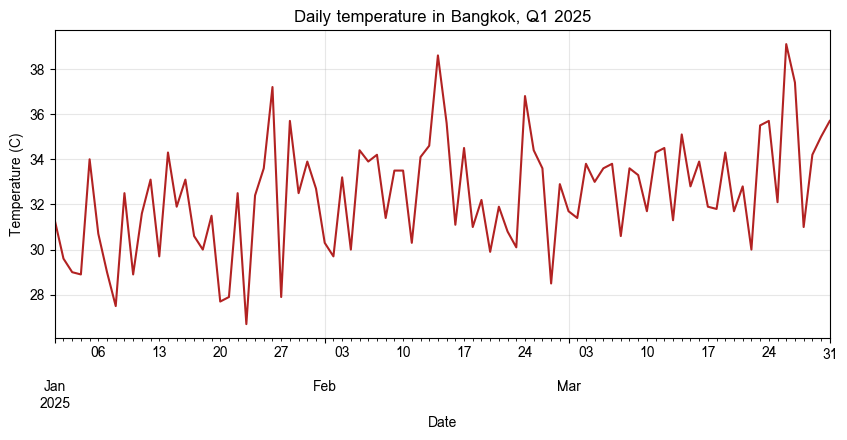

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# แนวปฏิบัติที่แนะนำคือสร้าง figure และ axes ขึ้นก่อน แล้วส่ง ax เข้าไปในคำสั่ง plot
bangkok = df[df["city"] == "Bangkok"].sort_values("date")

fig, ax = plt.subplots(figsize=(10, 4))
bangkok.plot(x="date", y="temperature_c", ax=ax, color="firebrick", legend=False)
ax.set_title("Daily temperature in Bangkok, Q1 2025")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (C)")
ax.grid(alpha=0.3)
plt.show()

### ตัวอย่างที่ 2 กราฟแท่งแนวตั้งและแนวนอน

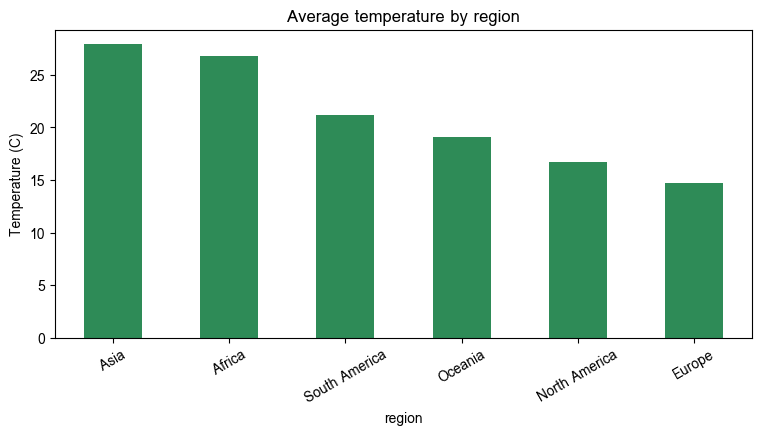

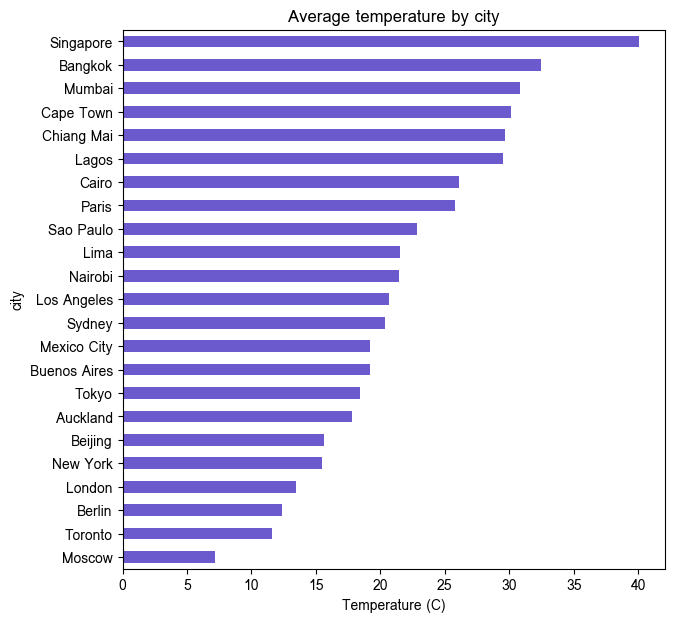

In [ ]:
avg_by_region = df.groupby("region")["temperature_c"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
avg_by_region.plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Average temperature by region")
ax.set_ylabel("Temperature (C)")
ax.tick_params(axis="x", rotation=30)
plt.show()

avg_by_city = df.groupby("city")["temperature_c"].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 7))
avg_by_city.plot(kind="barh", ax=ax, color="slateblue")
ax.set_title("Average temperature by city")
ax.set_xlabel("Temperature (C)")
plt.show()

### ตัวอย่างที่ 3 ฮิสโตแกรม กราฟจุด และ boxplot

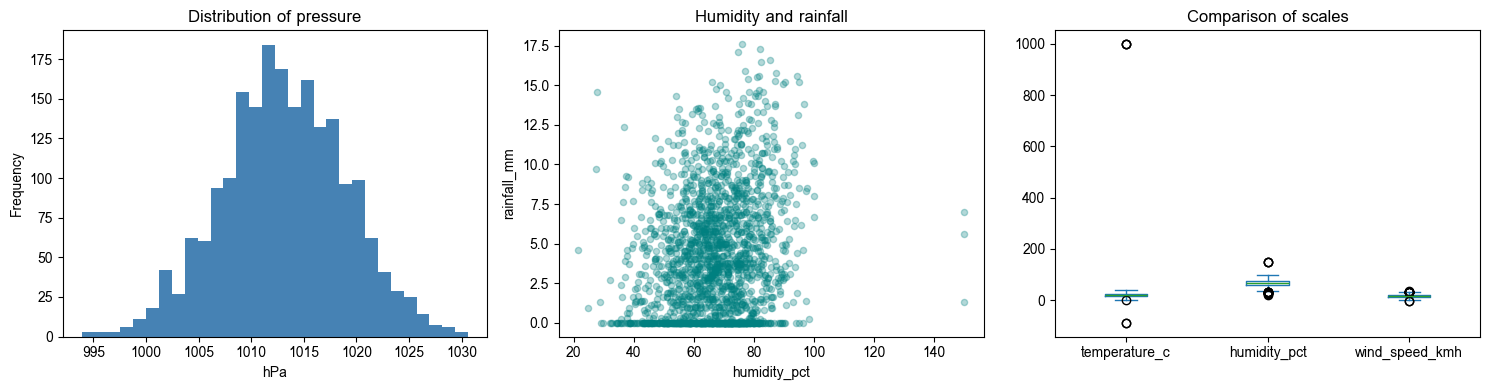

In [ ]:
# การวางกราฟหลายรูปในภาพเดียว ให้สร้าง axes เป็นกริดแล้วส่งแต่ละช่องเข้าไปด้วยพารามิเตอร์ ax
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["pressure_hpa"].plot(kind="hist", bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of pressure")
axes[0].set_xlabel("hPa")

df.plot(kind="scatter", x="humidity_pct", y="rainfall_mm", alpha=0.3, ax=axes[1], color="teal")
axes[1].set_title("Humidity and rainfall")

df[["temperature_c", "humidity_pct", "wind_speed_kmh"]].plot(kind="box", ax=axes[2])
axes[2].set_title("Comparison of scales")

plt.tight_layout()
plt.show()

### ตัวอย่างที่ 4 กราฟวงกลมและการนับสัดส่วน

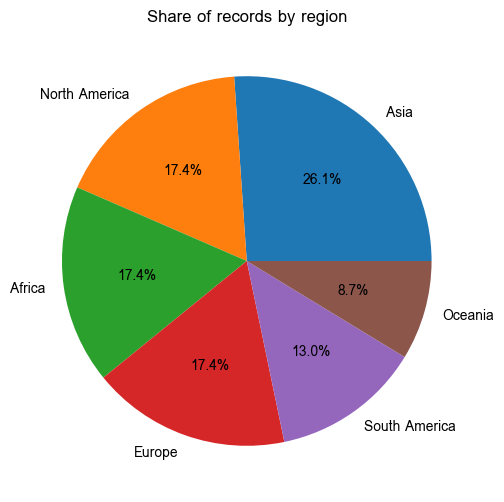

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
df["region"].value_counts().plot(kind="pie", ax=ax, autopct="%1.1f%%", ylabel="")
ax.set_title("Share of records by region")
plt.show()

### ตัวอย่างที่ 5 การวาดหลายคอลัมน์พร้อมกัน ด้วย `subplots` และ `secondary_y`

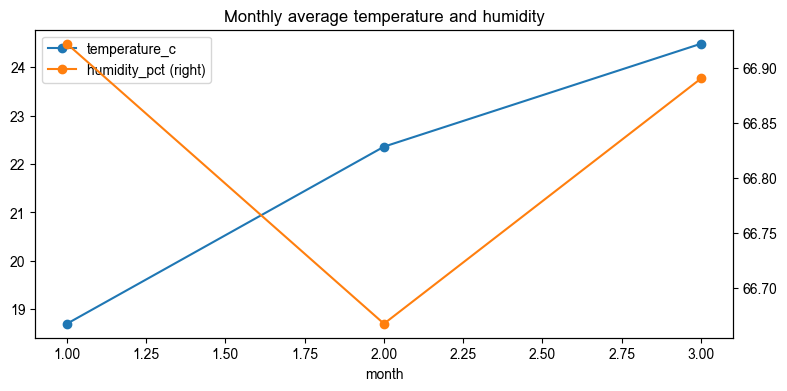

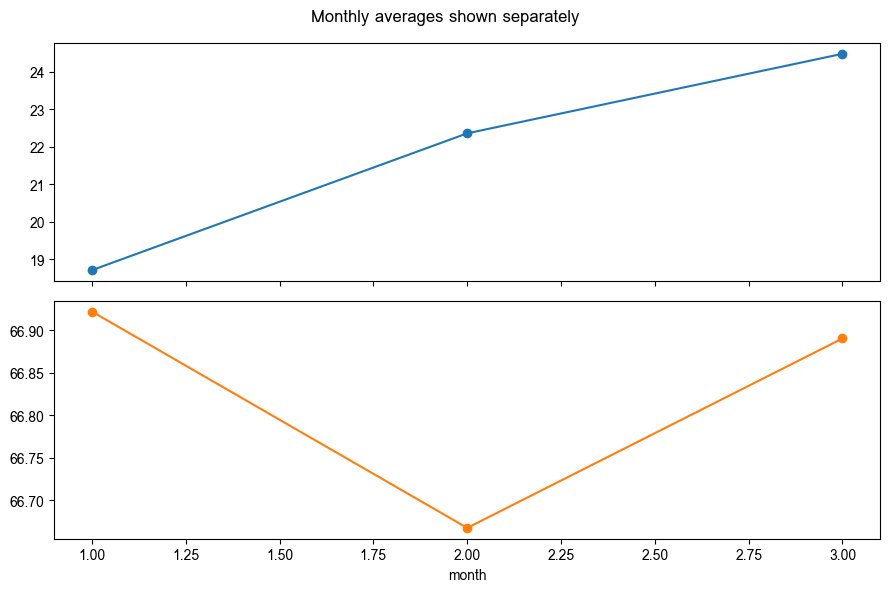

In [ ]:
monthly = df.groupby("month")[["temperature_c", "humidity_pct"]].mean()

# secondary_y ใช้แกน y ด้านขวาสำหรับคอลัมน์ที่มีสเกลต่างกันมาก
fig, ax = plt.subplots(figsize=(9, 4))
monthly.plot(ax=ax, marker="o", secondary_y="humidity_pct")
ax.set_title("Monthly average temperature and humidity")
plt.show()

# subplots=True แยกแต่ละคอลัมน์ออกเป็นกราฟย่อย
axes = monthly.plot(subplots=True, layout=(2, 1), figsize=(9, 6), marker="o", legend=False)
plt.suptitle("Monthly averages shown separately")
plt.tight_layout()
plt.show()

### ตัวอย่างที่ 6 กราฟแท่งซ้อนจากตารางไขว้

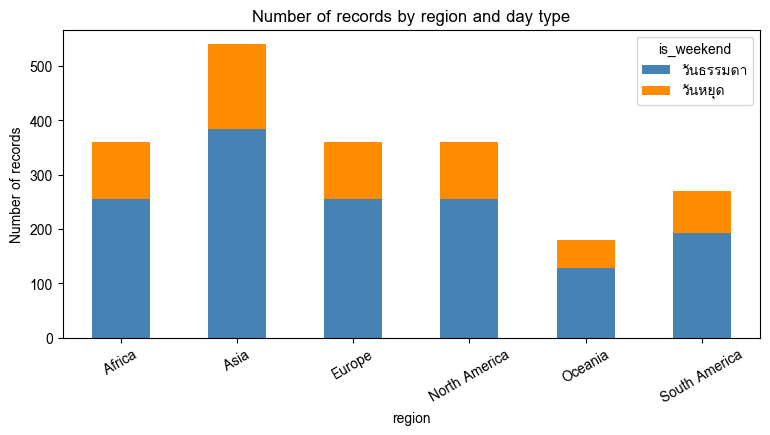

In [ ]:
df["is_weekend"] = df["date"].dt.dayofweek >= 5
weekend_by_region = (df.groupby(["region", "is_weekend"]).size()
                       .unstack(fill_value=0)
                       .rename(columns={False: "วันธรรมดา", True: "วันหยุด"}))

fig, ax = plt.subplots(figsize=(9, 4))
weekend_by_region.plot(kind="bar", stacked=True, ax=ax, color=["steelblue", "darkorange"])
ax.set_title("Number of records by region and day type")
ax.set_ylabel("Number of records")
ax.tick_params(axis="x", rotation=30)
plt.show()

### ตัวอย่างที่ 7 กราฟเชิงสถิติด้วย seaborn

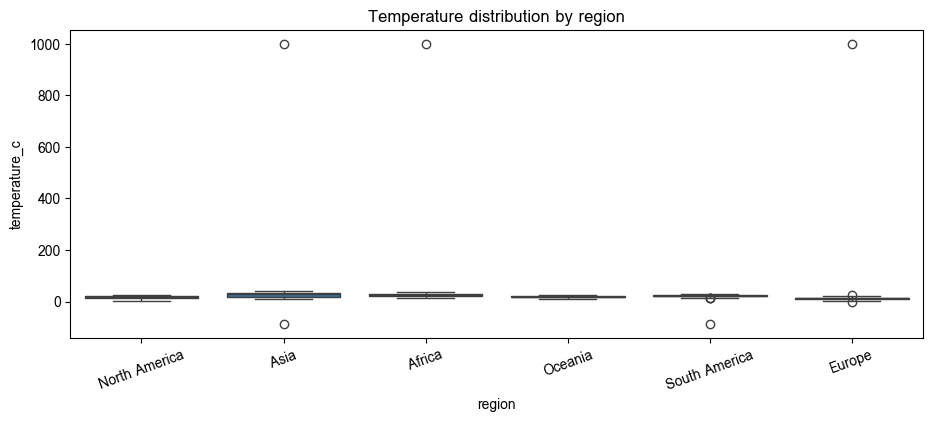

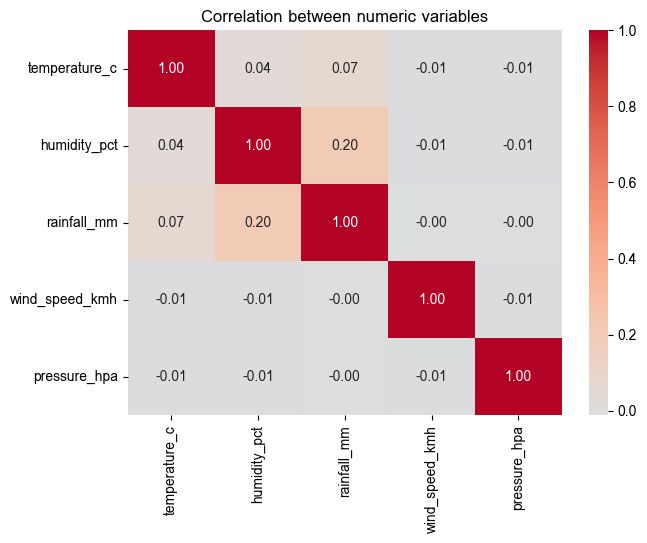

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.boxplot(data=df, x="region", y="temperature_c", ax=ax)
ax.set_title("Temperature distribution by region")
ax.tick_params(axis="x", rotation=20)
plt.show()

numeric_cols = ["temperature_c", "humidity_pct", "rainfall_mm", "wind_speed_kmh", "pressure_hpa"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation between numeric variables")
plt.show()

### โจทย์ 17.1
สร้างกราฟสี่รูปจาก DataFrame โดยใช้ `.plot()` พร้อมกำหนดชื่อกราฟและชื่อแกนให้ครบทุกรูป

1. กราฟเส้นแสดงแนวโน้มอุณหภูมิรายวันของสามเมืองในรูปเดียวกัน พร้อมคำอธิบายสัญลักษณ์
2. กราฟแท่งแนวนอนแสดงปริมาณฝนรวมรายเมือง เรียงจากมากไปน้อย
3. ฮิสโตแกรมของ `wind_speed_kmh` โดยทดลองกำหนด `bins` สามค่าที่ต่างกันและอธิบายผลของการเลือก `bins`
4. กราฟจุดระหว่าง `population_millions` กับอุณหภูมิเฉลี่ยรายเมือง

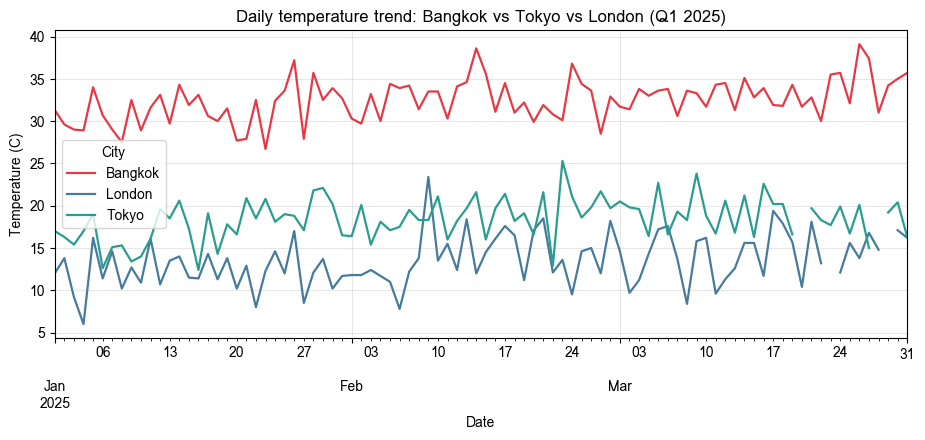

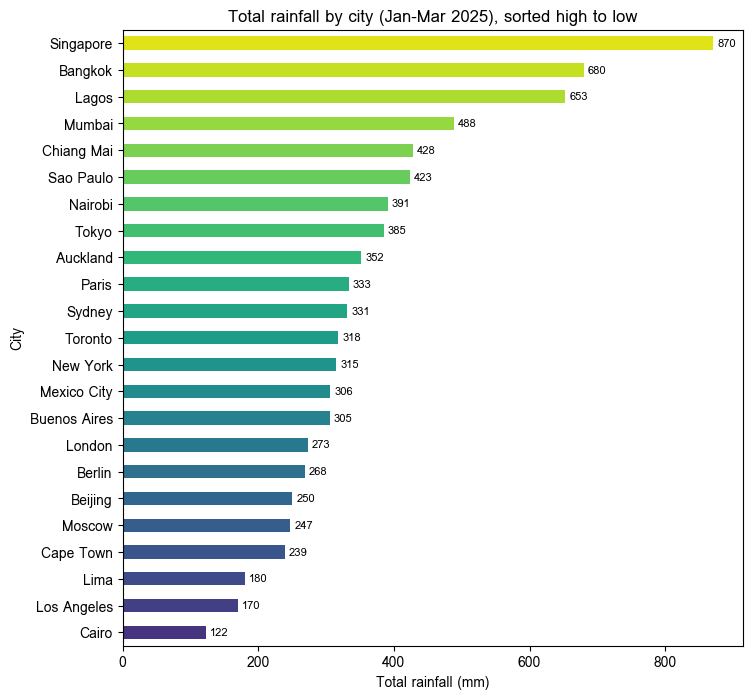

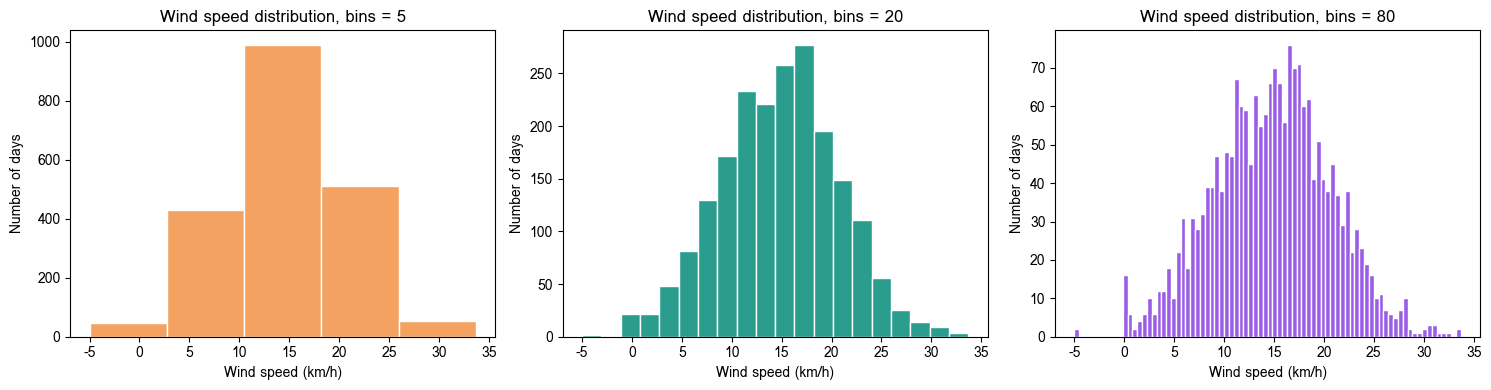

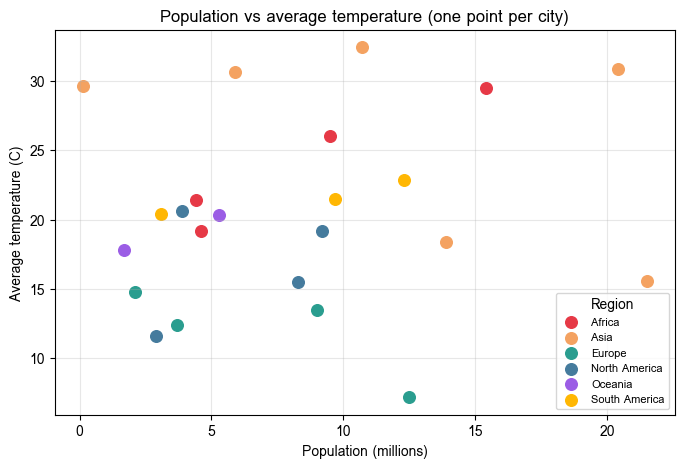

In [ ]:
# คำตอบข้อ 17.1
# Clean merged table from 14.1: abnormal values -> NaN (999 / -88 would ruin the plots)
clean_full = full.assign(
    temperature_c=full["temperature_c"].where(full["temperature_c"].between(-60, 60)),
    humidity_pct=full["humidity_pct"].where(full["humidity_pct"].between(0, 100)),
)

# (1) Line chart: daily temperature of 3 cities in one figure
cities_3 = ["Bangkok", "Tokyo", "London"]
daily_3 = (clean_full[clean_full["city"].isin(cities_3)]
             .pivot_table(index="date", columns="city", values="temperature_c"))
ax = daily_3.plot(figsize=(11, 4), color=["#e63946", "#457b9d", "#2a9d8f"], linewidth=1.6)
ax.set_title("Daily temperature trend: Bangkok vs Tokyo vs London (Q1 2025)")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (C)")
ax.legend(title="City")
ax.grid(alpha=0.3)
plt.show()

# (2) Horizontal bar: total rainfall per city, largest on top
rain_city = clean_full.groupby("city")["rainfall_mm"].sum().sort_values()
ax = rain_city.plot(kind="barh", figsize=(8, 8),
                    color=plt.cm.viridis(np.linspace(0.15, 0.95, len(rain_city))))
ax.bar_label(ax.containers[0], fmt="%.0f", padding=3, fontsize=8)
ax.set_title("Total rainfall by city (Jan-Mar 2025), sorted high to low")
ax.set_xlabel("Total rainfall (mm)")
ax.set_ylabel("City")
plt.show()

# (3) Histogram of wind speed with three different bin settings
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, n_bins, color in zip(axes, [5, 20, 80], ["#f4a261", "#2a9d8f", "#9b5de5"]):
    clean_full["wind_speed_kmh"].plot(kind="hist", bins=n_bins, ax=ax, color=color, edgecolor="white")
    ax.set_title(f"Wind speed distribution, bins = {n_bins}")
    ax.set_xlabel("Wind speed (km/h)")
    ax.set_ylabel("Number of days")
plt.tight_layout()
plt.show()

# (4) Scatter: population vs average temperature per city
city_pop_temp = (clean_full.groupby("city")
                           .agg(population_millions=("population_millions", "first"),
                                avg_temp=("temperature_c", "mean"),
                                region=("region", "first")))
fig, ax = plt.subplots(figsize=(8, 5))
region_colors = dict(zip(sorted(city_pop_temp["region"].unique()),
                         ["#e63946", "#f4a261", "#2a9d8f", "#457b9d", "#9b5de5", "#ffb703"]))
for reg, grp in city_pop_temp.groupby("region"):        # loop over 6 regions only (for legend)
    grp.plot(kind="scatter", x="population_millions", y="avg_temp", s=70, ax=ax,
             color=region_colors[reg], label=reg)
ax.set_title("Population vs average temperature (one point per city)")
ax.set_xlabel("Population (millions)")
ax.set_ylabel("Average temperature (C)")
ax.legend(title="Region", fontsize=8)
ax.grid(alpha=0.3)
plt.show()


**คำอธิบายข้อ 17.1 (การเลือก bins)**

- **bins = 5** กว้างเกินไป เห็นแค่ภาพรวมคร่าว ๆ และรายละเอียดของรูปร่างการกระจายหายไป
- **bins = 20** สมดุลที่สุด เห็นรูปร่างใกล้เคียงการแจกแจงปกติ มีจุดศูนย์กลางประมาณ 15 กม./ชม. ชัดเจน
- **bins = 80** แคบเกินไป แต่ละช่องมีข้อมูลน้อย กราฟขึ้นลงเป็นฟันเลื่อยจากความผันผวนของการสุ่ม (noise) ซึ่งอาจทำให้ตีความผิดว่ามีหลายยอด

จำนวน bins ที่เหมาะสมจึงขึ้นกับขนาดข้อมูล สำหรับข้อมูลประมาณ 2,000 แถว 15–30 bins มักเหมาะสม (สอดคล้องกับกฎของ Sturges หรือ Freedman–Diaconis)

### โจทย์ 17.2
นำผลลัพธ์ของโจทย์ 17.1 มาจัดวางในภาพเดียวกันด้วย `plt.subplots(2, 2)` พร้อมกำหนดชื่อรวมของภาพด้วย `plt.suptitle()`

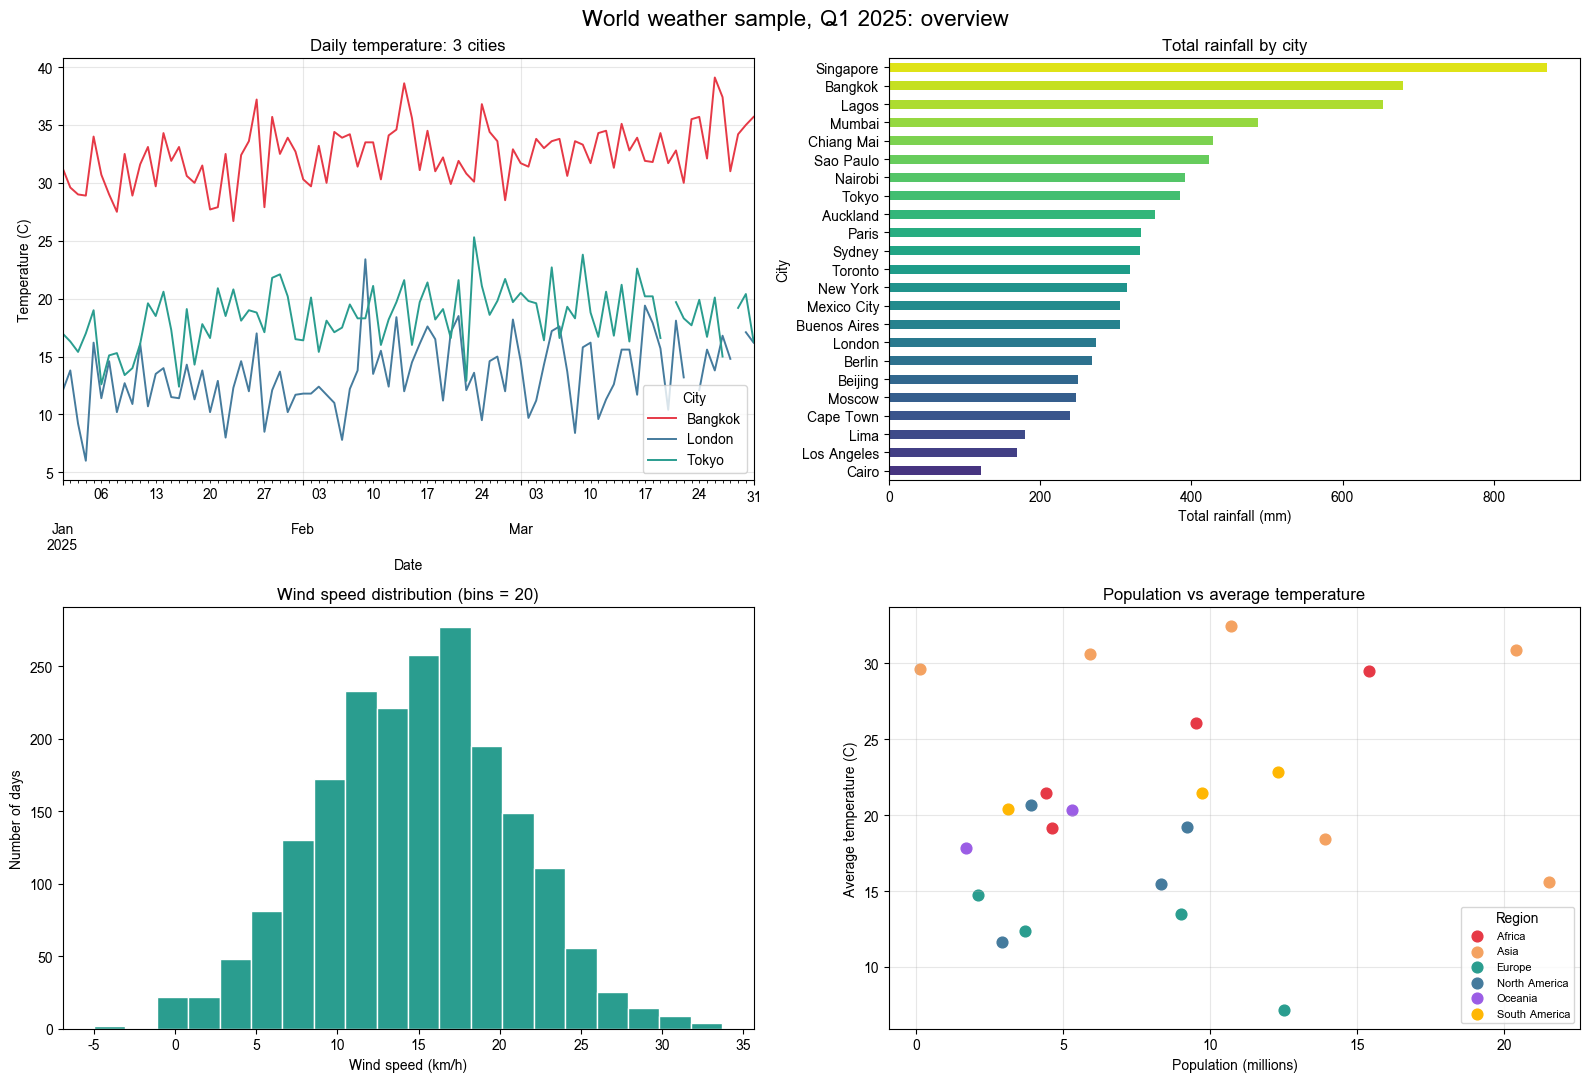

In [ ]:
# คำตอบข้อ 17.2
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

daily_3.plot(ax=axes[0, 0], color=["#e63946", "#457b9d", "#2a9d8f"], linewidth=1.4)
axes[0, 0].set_title("Daily temperature: 3 cities")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Temperature (C)")
axes[0, 0].legend(title="City")
axes[0, 0].grid(alpha=0.3)

rain_city.plot(kind="barh", ax=axes[0, 1],
               color=plt.cm.viridis(np.linspace(0.15, 0.95, len(rain_city))))
axes[0, 1].set_title("Total rainfall by city")
axes[0, 1].set_xlabel("Total rainfall (mm)")
axes[0, 1].set_ylabel("City")

clean_full["wind_speed_kmh"].plot(kind="hist", bins=20, ax=axes[1, 0], color="#2a9d8f", edgecolor="white")
axes[1, 0].set_title("Wind speed distribution (bins = 20)")
axes[1, 0].set_xlabel("Wind speed (km/h)")
axes[1, 0].set_ylabel("Number of days")

for reg, grp in city_pop_temp.groupby("region"):
    grp.plot(kind="scatter", x="population_millions", y="avg_temp", s=60, ax=axes[1, 1],
             color=region_colors[reg], label=reg)
axes[1, 1].legend(title="Region", fontsize=8)
axes[1, 1].set_title("Population vs average temperature")
axes[1, 1].set_xlabel("Population (millions)")
axes[1, 1].set_ylabel("Average temperature (C)")
axes[1, 1].grid(alpha=0.3)

plt.suptitle("World weather sample, Q1 2025: overview", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


### โจทย์ 17.3
สร้างกราฟแท่งซ้อนแสดงจำนวนวันในแต่ละช่วงปริมาณฝน โดยแบ่งช่วงด้วย `pd.cut()` และจำแนกตามภูมิภาค
จากนั้นสร้างกราฟแบบ `stacked=False` เปรียบเทียบ
**อธิบาย:** กราฟแท่งซ้อนเหมาะสมกว่าในกรณีใด และกราฟแท่งเรียงข้างกันเหมาะสมกว่าในกรณีใด

rainfall_mm    no rain (0)  light (0-5]  moderate (5-10]  heavy (>10)
region                                                               
Africa                 101          129               88           31
Asia                    59          174              203           90
Europe                 106          156               73           15
North America           92          161               84           11
Oceania                 35           68               60            9
South America           76          114               52           21


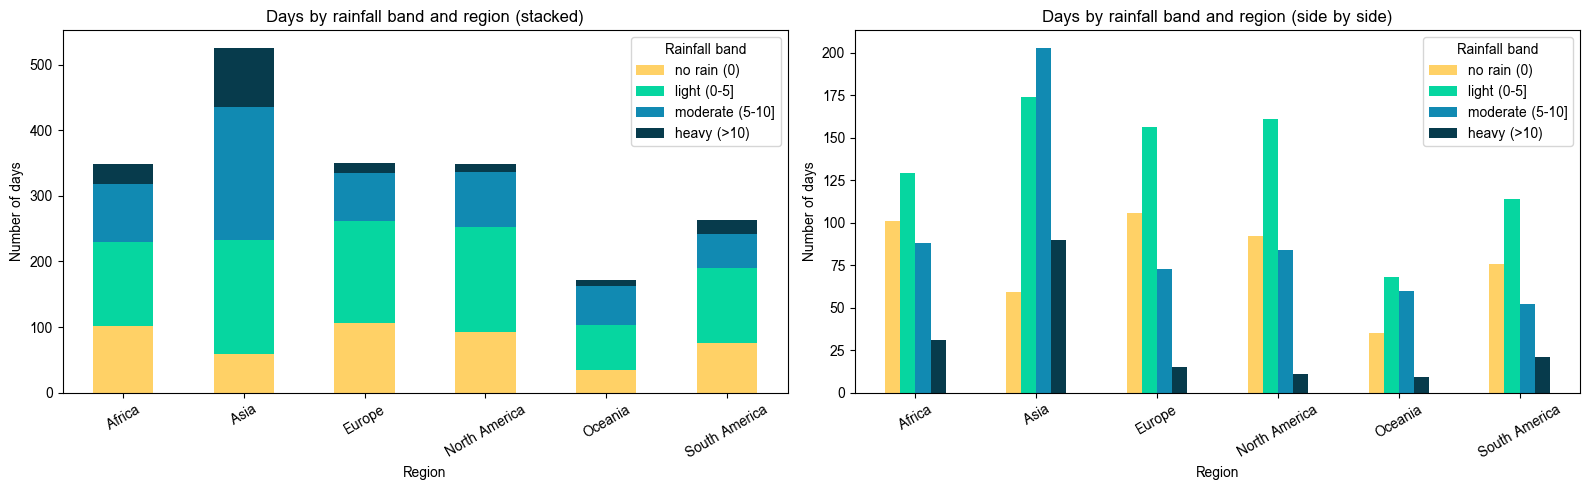

In [ ]:
# คำตอบข้อ 17.3
rain_band = pd.cut(df["rainfall_mm"], bins=[-0.01, 0, 5, 10, np.inf],
                   labels=["no rain (0)", "light (0-5]", "moderate (5-10]", "heavy (>10)"])
rain_region = pd.crosstab(df["region"], rain_band)
print(rain_region)

colors_173 = ["#ffd166", "#06d6a0", "#118ab2", "#073b4c"]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
rain_region.plot(kind="bar", stacked=True, ax=axes[0], color=colors_173)
axes[0].set_title("Days by rainfall band and region (stacked)")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Number of days")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(title="Rainfall band")

rain_region.plot(kind="bar", stacked=False, ax=axes[1], color=colors_173)
axes[1].set_title("Days by rainfall band and region (side by side)")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Number of days")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="Rainfall band")
plt.tight_layout()
plt.show()


**คำอธิบายข้อ 17.3**

- **กราฟแท่งซ้อน** เหมาะเมื่อต้องการเห็น **ยอดรวม** ของแต่ละกลุ่มพร้อมองค์ประกอบภายใน เช่น จำนวนวันทั้งหมดของแต่ละภูมิภาคและสัดส่วนของแต่ละช่วงฝน เปรียบเทียบส่วนล่างสุดได้ง่าย แต่ส่วนที่อยู่ตรงกลางเปรียบเทียบข้ามกลุ่มได้ยาก เพราะฐานไม่เท่ากัน
- **กราฟแท่งเรียงข้างกัน** เหมาะเมื่อต้องการ **เปรียบเทียบแต่ละหมวดย่อยข้ามกลุ่มโดยตรง** เช่น จำนวนวันฝนตกหนักของ Asia กับ Europe เพราะทุกแท่งเริ่มจากศูนย์ แต่มองยอดรวมได้ยากกว่า

จากกราฟ Asia มีวันฝนปานกลางและฝนตกหนักมากที่สุดอย่างชัดเจน ส่วน Europe และ Africa มีวันไม่มีฝนมาก

### โจทย์ 17.4
สร้างกราฟด้วย seaborn สองรูป ได้แก่ boxplot ของ `rainfall_mm` จำแนกตามภูมิภาคและแยกสีตาม `is_weekend`
และ heatmap ของสหสัมพันธ์ระหว่าง `temperature_c`, `humidity_pct`, `rainfall_mm` และ `population_millions`
พร้อมตีความผลที่ได้เป็นข้อความ

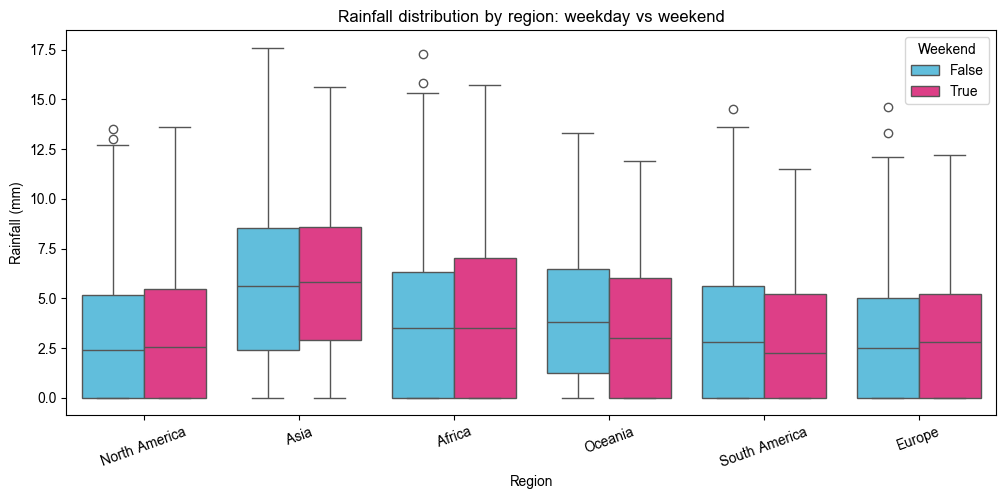

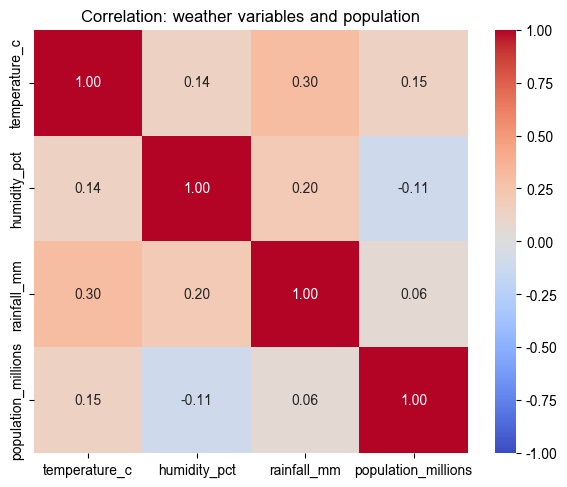

                     temperature_c  humidity_pct  rainfall_mm  \
temperature_c                1.000         0.136        0.297   
humidity_pct                 0.136         1.000        0.204   
rainfall_mm                  0.297         0.204        1.000   
population_millions          0.146        -0.107        0.061   

                     population_millions  
temperature_c                      0.146  
humidity_pct                      -0.107  
rainfall_mm                        0.061  
population_millions                1.000  

Median rainfall by region and day type:
is_weekend     False  True 
region                     
Africa           3.5   3.50
Asia             5.6   5.80
Europe           2.5   2.80
North America    2.4   2.55
Oceania          3.8   3.00
South America    2.8   2.25


In [ ]:
# คำตอบข้อ 17.4
# (1) Boxplot of rainfall by region, colored by weekend/weekday
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x="region", y="rainfall_mm", hue="is_weekend",
            palette={False: "#4cc9f0", True: "#f72585"}, ax=ax)
ax.set_title("Rainfall distribution by region: weekday vs weekend")
ax.set_xlabel("Region")
ax.set_ylabel("Rainfall (mm)")
ax.legend(title="Weekend")
ax.tick_params(axis="x", rotation=20)
plt.show()

# (2) Correlation heatmap (cleaned values, merged table with population)
corr_cols = ["temperature_c", "humidity_pct", "rainfall_mm", "population_millions"]
corr_174 = clean_full[corr_cols].corr()
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr_174, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation: weather variables and population")
plt.show()
print(corr_174.round(3))

# Supporting numbers for the interpretation
print("\nMedian rainfall by region and day type:")
print(df.pivot_table(index="region", columns="is_weekend", values="rainfall_mm", aggfunc="median"))


**คำอธิบายข้อ 17.4**

- **Boxplot:** ภูมิภาค Asia มีปริมาณฝนสูงและกระจายกว้างที่สุด ส่วนภูมิภาคอื่นมีมัธยฐานประมาณ 2–4 มม. ในแต่ละภูมิภาค กล่องของวันหยุดกับวันธรรมดาซ้อนทับกันเกือบทั้งหมด และมัธยฐานต่างกันไม่ถึง 1 มม. แสดงว่าไม่มีความแตกต่างระหว่างวันหยุดกับวันธรรมดาที่มีนัย ซึ่งสมเหตุสมผล เพราะสภาพอากาศไม่ขึ้นกับวันในสัปดาห์
- **Heatmap:** ความสัมพันธ์ทุกคู่ต่ำ คู่ที่สูงที่สุดคืออุณหภูมิกับปริมาณฝน (ประมาณ 0.30) เนื่องจากเมืองเขตร้อนชื้นมีทั้งอุณหภูมิและฝนสูง ส่วนจำนวนประชากรมีความสัมพันธ์กับตัวแปรสภาพอากาศใกล้ศูนย์ (|r| ≤ 0.15) จึงไม่มีหลักฐานว่าขนาดเมืองสัมพันธ์กับสภาพอากาศ และประชากรเป็นค่าคงที่ระดับเมือง การคำนวณสหสัมพันธ์ระดับรายวันจึงนับแต่ละเมืองซ้ำ 90 ครั้ง ควรตีความอย่างระมัดระวัง (ดูข้อ 18.3)

---
## ข้อ 18 โจทย์ประยุกต์รวม

ให้ใช้ตารางที่รวมข้อมูลจากทั้ง 3 แหล่งและผ่านการทำความสะอาดแล้ว ตอบคำถามต่อไปนี้
แต่ละข้อต้องประกอบด้วย **ตารางหรือกราฟหนึ่งชิ้น** และ **ข้อสรุปเป็นข้อความสั้น ๆ**

**ข้อกำหนดเพิ่มเติม**

- ให้เขียนโปรแกรมในรูปแบบลำดับต่อเนื่องที่อ่านเข้าใจได้ ไม่ใช้ตัวแปรชั่วคราวจำนวนมากโดยไม่จำเป็น
- ห้ามใช้การวนซ้ำทีละแถว
- หากข้อสรุปขึ้นอยู่กับวิธีจัดการค่าว่างหรือค่าผิดปกติ ให้ระบุวิธีที่เลือกใช้ไว้ด้วย

1. ภูมิภาคใดมีสภาพอากาศแปรปรวนมากที่สุดในไตรมาสแรก เมื่อวัดจากส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายวัน
   และความแปรปรวนดังกล่าวเกิดจากทุกเมืองในภูมิภาคนั้นเท่ากันหรือเกิดจากเมืองใดเมืองหนึ่งเป็นหลัก

In [ ]:
# คำตอบข้อ 18.1
region_var = (clean_full
    .groupby("region")
    .agg(std_daily_temp=("temperature_c", "std"),
         n_cities=("city", "nunique"))
    .join(clean_full.groupby(["region", "city"])["temperature_c"]
                    .agg(["mean", "std"])
                    .groupby("region")
                    .agg(mean_within_city_std=("std", "mean"),
                         std_between_city_means=("mean", "std")))
    .sort_values("std_daily_temp", ascending=False)
    .round(2))
print("Region-level variability (temperature, cleaned: values outside -60..60 set to NaN):")
print(region_var.to_string())

top_region = region_var.index[0]
city_detail = (clean_full[clean_full["region"] == top_region]
                 .groupby("city")["temperature_c"]
                 .agg(mean_temp="mean", std_temp="std", min_temp="min", max_temp="max")
                 .sort_values("mean_temp")
                 .round(2))
print(f"\nCities in {top_region}:")
print(city_detail.to_string())
print(f"\nConclusion: {top_region} has the highest daily-temperature std "
      f"({region_var.loc[top_region, 'std_daily_temp']} C). The average std inside each city is only "
      f"{region_var.loc[top_region, 'mean_within_city_std']} C, while city means differ by "
      f"{region_var.loc[top_region, 'std_between_city_means']} C (std), "
      f"from {city_detail.index[0]} ({city_detail['mean_temp'].iloc[0]} C) "
      f"to {city_detail.index[-1]} ({city_detail['mean_temp'].iloc[-1]} C).")


Region-level variability (temperature, cleaned: values outside -60..60 set to NaN):
               std_daily_temp  n_cities  mean_within_city_std  std_between_city_means
region                                                                               
Asia                     7.16         6                  2.67                    7.28
Africa                   4.88         4                  2.79                    4.64
North America            4.52         4                  2.87                    4.05
Europe                   4.07         4                  2.88                    3.32
Oceania                  3.08         2                  2.81                    1.80
South America            3.06         3                  2.89                    1.23

Cities in Asia:
            mean_temp  std_temp  min_temp  max_temp
city                                               
Beijing         15.60      2.87       9.2      22.6
Tokyo           18.41      2.52      12.4      25.3
Chi

**ข้อสรุปข้อ 18.1**

วิธีจัดการข้อมูล: ใช้ตารางที่รวม 3 แหล่งและขจัดข้อมูลซ้ำแล้ว และแปลงอุณหภูมินอกช่วง -60 ถึง 60 เป็นค่าว่าง

**Asia** มีส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายวันสูงที่สุด (ประมาณ 7.2°C) แต่ความแปรปรวนนี้ **ไม่ได้เกิดจากทุกเมืองเท่ากัน และไม่ได้เกิดจากการแกว่งของอากาศรายวัน** เพราะ std ภายในแต่ละเมืองของ Asia เฉลี่ยเพียงประมาณ 2.7°C ซึ่งใกล้เคียงหรือต่ำกว่าภูมิภาคอื่น ความแปรปรวนเกิดจาก **ความต่างระหว่างเมือง** เป็นหลัก กล่าวคือ Beijing (~15.6°C) และ Tokyo (~18.4°C) ซึ่งอยู่ในเขตอบอุ่น มีอุณหภูมิต่างจากเมืองเขตร้อนอย่าง Bangkok, Mumbai และ Singapore (~30–32°C) มาก

2. เมืองที่มีฝนตกหนักบ่อยที่สุด 5 อันดับแรกเมื่อวัดด้วยสัดส่วน ให้เปรียบเทียบกับผลที่ได้เมื่อวัดด้วยจำนวนวัน
   และอธิบายว่าเหตุใดจึงให้ผลต่างกัน

Missing rainfall values are excluded from the denominator (ratio = heavy days / valid days).
              heavy_days  n_valid_days  heavy_ratio  rank_by_ratio  rank_by_days
city                                                                            
Singapore             44            90       0.4889              1             1
Bangkok               23            87       0.2644              2             2
Lagos                 22            88       0.2500              3             3
Sao Paulo             11            88       0.1250              4             4
Chiang Mai             9            85       0.1059              5             5
Buenos Aires           9            88       0.1023              6             5


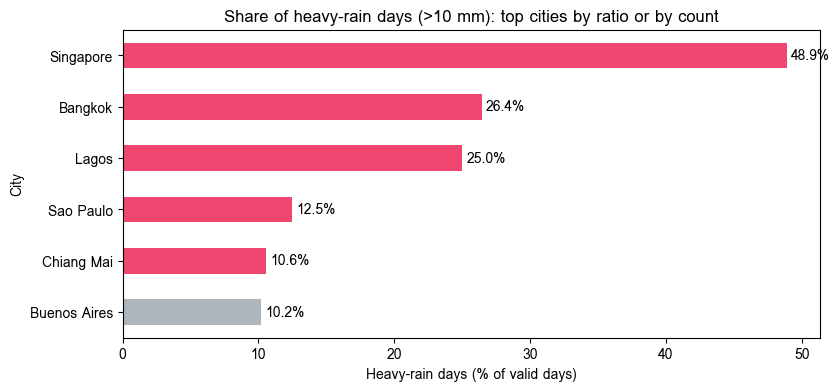

In top 5 only by ratio: [] | only by count: ['Buenos Aires']


In [ ]:
# คำตอบข้อ 18.2
heavy_cmp = (clean_full
    .groupby("city")
    .agg(heavy_days=("rainfall_mm", lambda s: (s > 10).sum()),
         n_valid_days=("rainfall_mm", "count"))
    .assign(heavy_ratio=lambda d: d["heavy_days"] / d["n_valid_days"],
            rank_by_ratio=lambda d: d["heavy_ratio"].rank(method="min", ascending=False).astype(int),
            rank_by_days=lambda d: d["heavy_days"].rank(method="min", ascending=False).astype(int))
    .sort_values("heavy_ratio", ascending=False))

top_union = heavy_cmp[(heavy_cmp["rank_by_ratio"] <= 5) | (heavy_cmp["rank_by_days"] <= 5)]
print("Missing rainfall values are excluded from the denominator (ratio = heavy days / valid days).")
print(top_union.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
bars = (top_union["heavy_ratio"] * 100).sort_values().plot(
    kind="barh", ax=ax, color=["#ef476f" if r <= 5 else "#adb5bd" for r in
                               top_union.sort_values("heavy_ratio")["rank_by_ratio"]])
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
ax.set_title("Share of heavy-rain days (>10 mm): top cities by ratio or by count")
ax.set_xlabel("Heavy-rain days (% of valid days)")
ax.set_ylabel("City")
plt.show()

only_ratio = sorted(set(top_union.index[top_union["rank_by_ratio"] <= 5]) -
                    set(top_union.index[top_union["rank_by_days"] <= 5]))
only_days = sorted(set(top_union.index[top_union["rank_by_days"] <= 5]) -
                   set(top_union.index[top_union["rank_by_ratio"] <= 5]))
print("In top 5 only by ratio:", only_ratio, "| only by count:", only_days)


**ข้อสรุปข้อ 18.2**

วิธีจัดการข้อมูล: ไม่นับค่าว่างของฝนในตัวหาร (สัดส่วน = วันฝน > 10 มม. / วันที่มีข้อมูลฝน)

เมื่อวัดด้วยสัดส่วน 5 อันดับแรกคือ Singapore, Bangkok, Lagos, Sao Paulo และ Chiang Mai ผลเกือบเหมือนการวัดด้วยจำนวนวัน เพราะทุกเมืองมีข้อมูลเกือบครบ 90 วัน ความต่างเกิดที่อันดับ 5 Chiang Mai และ Buenos Aires มีวันฝนตกหนัก 9 วันเท่ากัน แต่ Chiang Mai มีข้อมูลฝนที่ไม่ว่างน้อยกว่า (85 วัน เทียบกับ 88 วัน) สัดส่วนจึงสูงกว่า การวัดด้วยจำนวนวันจะได้เปรียบสำหรับเมืองที่มีข้อมูลครบ ส่วนสัดส่วนปรับให้เปรียบเทียบได้อย่างยุติธรรม ความต่างนี้จะยิ่งมากขึ้นถ้าแต่ละเมืองมีค่าว่างไม่เท่ากันมาก

3. จำนวนประชากรของเมืองมีความสัมพันธ์กับอุณหภูมิหรือปริมาณฝนหรือไม่
   ให้คำนวณค่าสหสัมพันธ์ประกอบ พร้อมระบุข้อควรระวังในการตีความอย่างน้อยหนึ่งประการ

In [ ]:
# คำตอบข้อ 18.3
city_level = (clean_full
    .groupby("city")
    .agg(population_millions=("population_millions", "first"),
         avg_temp=("temperature_c", "mean"),
         total_rain=("rainfall_mm", "sum")))

corr_183 = pd.DataFrame({
    "pearson": city_level.corr(method="pearson")["population_millions"],
    "spearman": city_level.corr(method="spearman")["population_millions"],
}).drop(index="population_millions").round(3)
print(f"City-level correlation with population (n = {len(city_level)} cities):")
print(corr_183)

# Sensitivity: drop the smallest city (Chiang Mai, 0.13 M)
smallest = city_level["population_millions"].idxmin()
print(f"\nPearson without {smallest}:")
print(city_level.drop(index=smallest).corr()["population_millions"].drop("population_millions").round(3))


City-level correlation with population (n = 23 cities):
            pearson  spearman
avg_temp      0.159     0.230
total_rain    0.128     0.053

Pearson without Chiang Mai:
avg_temp      0.274
total_rain    0.162
Name: population_millions, dtype: float64


**ข้อสรุปข้อ 18.3**

ระดับเมือง (n = 23) สหสัมพันธ์ระหว่างประชากรกับอุณหภูมิเฉลี่ยประมาณ 0.16 (Pearson) และ 0.23 (Spearman) ส่วนกับปริมาณฝนรวมประมาณ 0.13 และ 0.05 **ถือว่าอ่อนมาก จึงไม่มีหลักฐานว่าประชากรสัมพันธ์กับอุณหภูมิหรือฝน**

**ข้อควรระวังในการตีความ**

1. ตัวอย่างมีเพียง 23 เมือง ค่า r ระดับนี้ไม่มีนัยสำคัญทางสถิติ และเปลี่ยนได้มากเมื่อตัดเมืองเดียวออก (ตัด Chiang Mai แล้ว r ของอุณหภูมิเพิ่มเป็นประมาณ 0.27)
2. สหสัมพันธ์ไม่ใช่ความเป็นเหตุเป็นผล สภาพอากาศถูกกำหนดโดยละติจูดและภูมิศาสตร์ ซึ่งเป็นตัวแปรกวน (confounder) ไม่ใช่ขนาดเมือง
3. ไม่ควรคำนวณระดับรายวัน เพราะประชากรเป็นค่าคงที่ของเมือง จะทำให้ดูเหมือนมีข้อมูลมากเกินจริง (pseudo-replication)

4. เดือนใดของแต่ละภูมิภาคที่ควรหลีกเลี่ยงการเดินทางมากที่สุด
   ให้กำหนดเกณฑ์การตัดสินใจจากข้อมูลที่มีอยู่ และอธิบายเหตุผลของการเลือกเกณฑ์ดังกล่าว

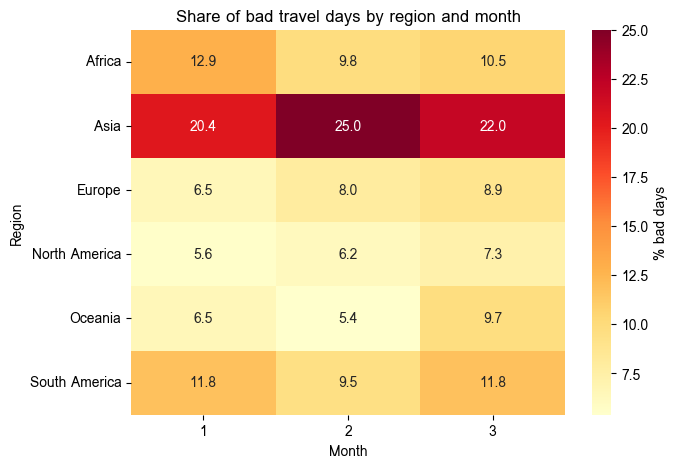

Month to avoid in each region:
       region  month  pct_bad_days  avg_temp  total_rain
       Africa      1          12.9     22.64       506.8
         Asia      2          25.0     26.76      1043.2
       Europe      3           8.9     13.29       372.5
North America      3           7.3     18.04       331.1
      Oceania      3           9.7     20.20       240.7
South America      1          11.8     20.37       303.5


In [ ]:
# คำตอบข้อ 18.4
# Decision rule: a "bad travel day" has heavy rain (>10 mm), strong wind (>25 km/h),
# extreme heat (>35 C) or freezing temperature (<0 C). Missing values do not count as bad.
avoid = (clean_full
    .assign(bad_day=lambda d: (d["rainfall_mm"] > 10) | (d["wind_speed_kmh"] > 25) |
                              (d["temperature_c"] > 35) | (d["temperature_c"] < 0))
    .groupby(["region", "month"])
    .agg(pct_bad_days=("bad_day", "mean"),
         avg_temp=("temperature_c", "mean"),
         total_rain=("rainfall_mm", "sum"))
    .assign(pct_bad_days=lambda d: (d["pct_bad_days"] * 100).round(1))
    .round(2))

heat = avoid["pct_bad_days"].unstack("month")
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(heat, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax, cbar_kws={"label": "% bad days"})
ax.set_title("Share of bad travel days by region and month")
ax.set_xlabel("Month")
ax.set_ylabel("Region")
plt.show()

worst_month = (avoid.reset_index()
                    .sort_values("pct_bad_days", ascending=False)
                    .groupby("region")
                    .head(1)
                    .sort_values("region")
                    .reset_index(drop=True))
print("Month to avoid in each region:")
print(worst_month.to_string(index=False))


**ข้อสรุปข้อ 18.4**

**เกณฑ์ที่ใช้:** กำหนด "วันไม่เหมาะเดินทาง" คือวันที่มีอย่างน้อยหนึ่งเงื่อนไข ได้แก่ ฝนตกหนัก (> 10 มม.) ลมแรง (> 25 กม./ชม.) ร้อนจัด (> 35°C) หรืออุณหภูมิต่ำกว่าจุดเยือกแข็ง (< 0°C) แล้ววัดเป็น **ร้อยละของวัน** ในแต่ละภูมิภาคและเดือน เดือนที่มีร้อยละสูงสุดคือเดือนที่ควรหลีกเลี่ยง ค่าว่างไม่นับเป็นวันแย่ และอุณหภูมิผิดปกติถูกตัดออกก่อน

**เหตุผล:** ทั้งสี่เงื่อนไขกระทบการเดินทางโดยตรง (น้ำท่วม เที่ยวบินล่าช้า ความเสี่ยงต่อสุขภาพ) และการใช้ร้อยละแทนจำนวนวันทำให้เปรียบเทียบเดือนที่มีจำนวนวันไม่เท่ากันได้ (ก.พ. มี 28 วัน)

**ผล:** เดือนที่ควรหลีกเลี่ยงคือ Asia เดือน 2 (25%) Africa เดือน 1 Europe, North America และ Oceania เดือน 3 ส่วน South America เดือน 1 และเดือน 3 มีร้อยละเท่ากัน (ประมาณ 11.8%) Asia มีสัดส่วนวันแย่สูงกว่าภูมิภาคอื่นชัดเจนทุกเดือน เพราะมีวันฝนตกหนักและวันร้อนจัดมาก

---

<center>จบแล้ว ขอแสดงความยินดีกับทุกคน

<center>> เขียนเองหนึ่งบรรทัด ได้ความเข้าใจมากกว่าอ่านผ่านตาสิบบรรทัด
> One line you write yourself teaches more than ten you only read.

> คนที่จัดการข้อมูลสองพันแถวได้อย่างสะอาดหมดจด คือคนเดียวกับที่จะจัดการข้อมูลสองล้านแถวได้อย่างมั่นใจ
> Whoever handles two thousand rows with care will handle two million with confidence.

<center>❤️❤️❤️❤️❤️ Keep Learning ❤️❤️❤️❤️❤️